# ATAM-FET — Federated Edge-Based Early Toxicity Detection (clean all-inline run)
Jigsaw multi-label toxic-comment pipeline in a **single self-contained notebook**.
All code is defined **inline in cells** (no `%%writefile`, no `.py` files) and each
module is checkpoint/resume-aware so you can hit Kaggle's session limit and **continue
where you left off**.

## Run order (top to bottom)

| Step | Cell | Purpose | Heavy? | Resume marker |
|------|------|---------|--------|---------------|
| 0 | RUN ORDER | this table | - | - |
| 1 | Setup | env, paths, config, state engine | light | - |
| 2 | Shared runtime | `run_module()` skip/resume | light | - |
| 3 | Module 1 | data cleaning | light | `data/processed/train_cleaned.csv` |
| 4 | Module 2 | tokenization (80/10/10) | light | `data/processed/tokenized/` |
| 5 | Module 3 | centralized DistilBERT | GPU heavy | epoch checkpoints |
| 6 | Module 4 | LoRA personalization counts | light | always runs |
| 7 | Module 5 | federated FedAvg+LoRA (4 px) | heavy | round checkpoints |
| 8 | Module 6 | ATAM training | GPU heavy | epoch checkpoints |
| 9 | Module 7 | INT8 quantize + prune + bench | light | `results/optimization/` |
| 10 | Module 8 | while-typing demo | light | - |
| 11 | Module 9 | ablation study | medium | `results/ablation/` |
| 12 | Module 10 | reports & plots | light | `results/reports/` |

**Resume workflow:** after a session limit / interrupt, re-run cells 1-2 (fast) and then
re-run the interrupted module cell — it prints `[RESUME]` and continues from the last
checkpoint instead of restarting. Completed modules print `[SKIP]`. The config hash in
`results/.atam_state.json` invalidates stale artifacts when hyper-parameters change.

In [22]:
%pip install -q emoji "flwr>=1.0" "cryptography>=42.0.0"
%matplotlib inline

import os, sys, json, time, shutil, glob, hashlib, warnings
from pathlib import Path

import torch
import numpy as np

warnings.filterwarnings("ignore")
torch.set_num_threads(min(8, os.cpu_count() or 4))

ON_KAGGLE = Path("/kaggle/working").exists()
if ON_KAGGLE:
    os.chdir("/kaggle/working")
    RAW_DATA_DIR = Path("/kaggle/input/datasets/najmus07/jigasaw-train")
    if not (RAW_DATA_DIR / "train.csv").exists():
        candidates = sorted(Path("/kaggle/input").glob("*/train.csv"))
        if candidates:
            RAW_DATA_DIR = candidates[0].parent
        else:
            raise FileNotFoundError(
                "No train.csv found under /kaggle/input - attach the "
                "'jigsaw-toxic-comment-classification' (or a compatible) dataset.")
else:
    RAW_DATA_DIR = Path("jigsaw-toxic-comment-classification")
    if not RAW_DATA_DIR.exists():
        RAW_DATA_DIR = Path("data/raw")

for d in ["data/processed/tokenized", "data/raw", "data/partitions",
          "models/cache", "results"]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("workdir:", Path.cwd())
print("raw data:", RAW_DATA_DIR)
print("device :", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

Note: you may need to restart the kernel to use updated packages.
workdir: /kaggle/working
raw data: /kaggle/input/datasets/najmus07/jigasaw-train
device : cuda


In [23]:
# --- CONFIG (single source of truth, previously config.yaml) ---

CONFIG = {
  "project": {
    "name": "Federated Edge-Based Early Toxicity Detection",
    "description": "Privacy-preserving early toxicity detection using lightweight transformer models and federated learning, simulated for mobile keyboard applications.\n",
    "version": "1.0.0",
    "seed": 42,
    "output_dir": "results"
  },
  "results": {
    "plots": "results/plots",
    "logs": "results/logs",
    "checkpoints": "results/checkpoints",
    "reports": "results/reports"
  },
  "data": {
    "raw": {
      "path": "data/raw",
      "train_file": "train.csv",
      "test_file": "test.csv"
    },
    "processed": {
      "path": "data/processed",
      "train_file": "train_cleaned.csv",
      "test_file": "test_cleaned.csv"
    },
    "partitions": {
      "path": "data/partitions"
    },
    "labels": [
      "toxic",
      "severe_toxic",
      "obscene",
      "threat",
      "insult",
      "identity_hate"
    ],
    "num_labels": 6,
    "max_seq_length": 256
  },
  "preprocessing": {
    "remove_urls": True,
    "remove_mentions": True,
    "lowercase": True,
    "normalize_whitespace": True,
    "normalize_emoji": True,
    "remove_duplicates": True
  },
  "model": {
    "name": "distilbert-base-uncased",
    "num_labels": 6,
    "dropout": 0.1,
    "cache_dir": "models/cache",
    "use_atam": False
  },
  "training": {
    "batch_size": 32,
    "learning_rate": 2e-05,
    "epochs": 6,
    "weight_decay": 0.01,
    "warmup_steps": 500,
    "gradient_clip": 1.0,
    "evaluation_strategy": "epoch",
    "save_strategy": "epoch",
    "logging_steps": 100,
    "early_stopping_patience": 2
  },
  "personalization": {
    "method": "none",
    "lora_r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.1,
    "lora_modules": [
      "q_lin",
      "v_lin"
    ]
  },
  "federated": {
    "num_clients": 10,
    "num_rounds": 25,
    "fraction_fit": 1.0,
    "min_fit_clients": 10,
    "min_available_clients": 10,
    "local_epochs": 1,
    "iid": True,
    "alpha": 0.5,
    "server_address": "0.0.0.0:8080",
    "strategy": "fedavg"
  },
  "evaluation": {
    "warning_threshold": 0.7,
    "early_detection": True,
    "prefix_increment": 1,
    "metrics": [
      "accuracy",
      "precision",
      "recall",
      "f1_macro",
      "f1_micro",
      "roc_auc",
      "hamming_loss",
      "subset_accuracy"
    ]
  },
  "optimization": {
    "quantize": False,
    "quantization_type": "dynamic"
  },
  "logging": {
    "level": "INFO",
    "format": "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
  }
}

print('Config:', CONFIG['project']['name'], '| seed', CONFIG['project']['seed'])

Config: Federated Edge-Based Early Toxicity Detection | seed 42


In [24]:
# --- shared runtime: config hash + skip/resume state + run_module() ---
import json, time, hashlib, os, re, sys
from pathlib import Path
VERSION = "clean-v1"
STATE_FILE = Path("results/.atam_state.json")

def cfg_hash() -> str:
    return hashlib.md5((VERSION + json.dumps(CONFIG, sort_keys=True, default=str)).encode()).hexdigest()[:12]

def load_state() -> dict:
    if STATE_FILE.exists():
        try:
            return json.load(open(STATE_FILE))
        except Exception:
            pass
    return {"modules": {}}

def save_state(state: dict) -> None:
    STATE_FILE.parent.mkdir(parents=True, exist_ok=True)
    json.dump(state, open(STATE_FILE, "w"), indent=2)

def load_config(path=None):
    # Backward-compat: every original load_config() call returns the inline CONFIG.
    return CONFIG

MODULES = {}

def run_module(name: str, force: bool = False):
    state = load_state()
    h = cfg_hash()
    rec = state["modules"].get(name, {})
    if not force and rec.get("status") == "done" and rec.get("hash") == h:
        print(f"[SKIP] {name} already complete & config unchanged"
              f"  (run_module('{name}', force=True) to force a re-run)")
        return
    fn = MODULES.get(name)
    if fn is None:
        print(f"[MISSING] no runner for {name} -- did the definition cells run?")
        return
    t0 = time.time()
    print(f"\n########## {name} ########## config-hash={h}")
    try:
        fn()
        state["modules"][name] = {
            "status": "done", "hash": h, "ts": time.strftime("%Y-%m-%d %H:%M:%S"),
            "time_s": round(time.time() - t0, 1),
        }
        save_state(state)
        print(f"########## {name} DONE in {time.time()-t0:.1f}s ##########")
    except KeyboardInterrupt:
        save_state(state)  # keep prior state; checkpoints already on disk
        print(f"[INTERRUPTED {name} after {time.time()-t0:.0f}s - re-run this cell to resume]")
        raise

# --- environment fingerprint (reproducibility artifact) ---
def write_environment_json() -> Path:
    import platform
    env = {
        "hostname": platform.node(),
        "platform": platform.platform(),
        "python": platform.python_version(),
        "torch": getattr(torch, "__version__", "n/a"),
        "cuda_available": bool(torch.cuda.is_available()) if hasattr(torch, "cuda") else False,
        "device_name": (torch.cuda.get_device_name(0)
                        if hasattr(torch, "cuda") and torch.cuda.is_available()
                        else platform.machine()),
        "numpy": getattr(np, "__version__", "n/a"),
        "seed": CONFIG["project"]["seed"],
        "config_hash": cfg_hash(),
    }
    for mod in ["transformers", "datasets", "flwr", "sklearn", "pandas"]:
        try:
            m = __import__(mod)
            env[mod] = getattr(m, "__version__", "n/a")
        except Exception:
            env[mod] = "n/a"
    out = Path("results/environment.json")
    out.parent.mkdir(parents=True, exist_ok=True)
    json.dump(env, open(out, "w"), indent=2)
    print(f"Environment fingerprint saved: {out}")
    return out

write_environment_json()


Environment fingerprint saved: results/environment.json


PosixPath('results/environment.json')

In [25]:
# --- helpers (seeds, dirs, timestamps) ---

"""
Helper Utilities
=================

Purpose:
    Shared utility functions used across multiple modules.

    Keeping these in one place prevents code duplication and makes
    the project more maintainable.

Current functions:
    - ensure_dir(path): Creates a directory if it doesn't exist
    - set_random_seed(seed): Sets seeds for reproducibility
    - get_timestamp(): Returns a timestamp string for file naming
"""

import os
import random
import numpy as np
from pathlib import Path
from datetime import datetime


def ensure_dir(path: str) -> Path:
    """
    Create a directory if it does not already exist.

    This is used extensively throughout the project to ensure
    output directories exist before saving files.

    Parameters
    ----------
    path : str
        Path to the directory to create.

    Returns
    -------
    Path
        The path object for the created/existing directory.

    Example
    -------
    >>> save_dir = ensure_dir("results/plots")
    """
    path_obj = Path(path)
    path_obj.mkdir(parents=True, exist_ok=True)
    return path_obj


def set_random_seed(seed: int) -> None:
    """
    Set random seeds for reproducibility across Python, NumPy, and PyTorch.

    Why is this necessary?
        Random number generators produce different numbers each run
        unless we fix the seed. Without this, you cannot reproduce
        results exactly.

    Parameters
    ----------
    seed : int
        The random seed value (e.g., 42).
    """
    random.seed(seed)
    np.random.seed(seed)

    # We'll add torch seed later when we import torch in Module 3
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
            # Ensures deterministic behavior on GPU (slower but reproducible)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
    except ImportError:
        pass  # PyTorch not installed yet


def get_timestamp() -> str:
    """
    Return a timestamp string for use in filenames.

    This ensures that logs, checkpoints, and reports have
    unique, sortable names.

    Returns
    -------
    str
        Timestamp in format: YYYYMMDD_HHMMSS
    """
    return datetime.now().strftime("%Y%m%d_%H%M%S")


def get_label_columns(config) -> list:
    """
    Extract the list of label column names from the config.

    This helper exists so we don't have to hardcode label names
    in every module.

    Parameters
    ----------
    config : dict
        The project configuration dictionary.

    Returns
    -------
    list
        List of label column names, e.g.,
        ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
    """
    return config["data"]["labels"]


In [26]:
# --- Module 1: data cleaning ---

"""
Data Cleaning Module
=====================

Module 1: Raw Data → Cleaned Data

What this module does:
    1. Loads the raw Jigsaw CSV files
    2. Removes duplicate comments
    3. Removes URLs (they carry no toxicity signal) [case-insensitive]
    4. Removes @mentions (usernames are not content) [case-insensitive]
    5. Converts emojis to text descriptions (preserves emotional meaning)
    6. Converts text to lowercase (standard for DistilBERT, also catches
       capitalized text from emoji demojization like :Statue_of_Liberty:)
    7. Normalizes whitespace (consistent tokenization)
    8. Saves the cleaned dataset

Why these cleaning steps?
    Transformer models like DistilBERT learn patterns from text.
    Noise like URLs, mentions, and inconsistent casing forces the
    model to waste capacity on irrelevant patterns. Cleaning
    removes this noise so the model focuses on actual toxic language.

Multi-label classification note:
    The Jigsaw dataset has 6 binary labels per comment. A comment
    can be both "toxic" AND "obscene" simultaneously. This is
    different from multi-class where each sample has ONE label.
"""

import re
import pandas as pd
import emoji
from pathlib import Path
from typing import Tuple


# ---------------------------------------------------------------------------
# Individual cleaning functions
# ---------------------------------------------------------------------------
# Each function does ONE thing. This makes the code easy to understand,
# test, and modify. You can add/remove cleaning steps without
# affecting the rest of the pipeline.

def remove_urls(text: str) -> str:
    """
    Remove URLs (http://..., https://..., www.xxx...) from text.

    Why remove URLs?
        URLs are references to web pages, not natural language.
        They don't help the model detect toxicity. A URL like
        "http://example.com" could appear in both toxic and
        non-toxic comments equally.

    The regex pattern matches:
        - http:// or https:// followed by non-whitespace characters
        - www. followed by non-whitespace characters
    """
    if not isinstance(text, str):
        return ""

    # Pattern explanation:
    #   r'https?://\S+'  - matches http:// or https:// followed by non-spaces
    #   |                - OR
    #   r'www\.\S+'      - matches www. followed by non-spaces
    #
    # We use re.IGNORECASE because URLs can have mixed case:
    #   "Www.Example.Com" should be treated the same as "www.example.com"
    url_pattern = r'https?://\S+|www\.\S+'
    return re.sub(url_pattern, '', text, flags=re.IGNORECASE)


def remove_mentions(text: str) -> str:
    """
    Remove @username mentions from text.

    Why remove mentions?
        @mentions are user identifiers (e.g., @john_doe).
        They don't contribute to the toxicity of the message.
        "I hate @user123" has the same toxicity as "I hate you".
    """
    if not isinstance(text, str):
        return ""

    # Pattern: @ symbol followed by non-whitespace characters
    # Case-insensitive to catch @User and @user uniformly
    mention_pattern = r'@\S+'
    return re.sub(mention_pattern, '', text, flags=re.IGNORECASE)


def normalize_whitespace(text: str) -> str:
    """
    Collapse multiple whitespace characters into a single space
    and strip leading/trailing whitespace.

    Why normalize whitespace?
        After removing URLs and mentions, we may have leftover
        spaces. "hello   world  " should become "hello world".
        Consistent whitespace ensures the tokenizer works correctly.
    """
    if not isinstance(text, str):
        return ""

    # Replace one or more whitespace chars (\s+) with a single space
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def normalize_emoji(text: str) -> str:
    """
    Convert emojis to their text descriptions using the `emoji` library.

    Example:
        "I am so happy 😊" → "I am so happy :smiling_face_with_smiling_eyes:"

    Why normalize emojis?
        Emojis carry emotional meaning that is relevant for toxicity
        detection. However, Transformer tokenizers don't handle
        emojis well (they get split into strange subwords).
        Converting to text like ":smiling_face:" preserves the
        emotional signal in a format the model understands.
    """
    if not isinstance(text, str):
        return ""

    # demojize converts emoji characters to :text: format
    return emoji.demojize(text)


def clean_text(
    text: str,
    remove_urls_flag: bool = True,
    remove_mentions_flag: bool = True,
    lowercase_flag: bool = True,
    normalize_emoji_flag: bool = True,
    normalize_whitespace_flag: bool = True,
) -> str:
    """
    Apply all cleaning operations to a single text string.

    ORDER MATTERS:
    1. Remove URLs first (they may contain @ symbols)
    2. Remove mentions second
    3. Normalize emojis third (convert emojis to text BEFORE lowercasing,
       because emoji text like ":Statue_of_Liberty:" may contain capitals)
    4. Lowercase fourth (catches any capitals from emoji demojization)
    5. Normalize whitespace last (cleans up artifacts from previous steps)

    Parameters
    ----------
    text : str
        The raw comment text to clean.
    remove_urls_flag : bool
        Whether to remove URLs.
    remove_mentions_flag : bool
        Whether to remove @mentions.
    lowercase_flag : bool
        Whether to convert to lowercase.
    normalize_emoji_flag : bool
        Whether to convert emojis to text.
    normalize_whitespace_flag : bool
        Whether to normalize whitespace.

    Returns
    -------
    str
        The cleaned text. Returns original text as fallback if
        result would otherwise be empty (e.g., URL-only comments).
    """
    if not isinstance(text, str):
        return ""

    if remove_urls_flag:
        text = remove_urls(text)

    if remove_mentions_flag:
        text = remove_mentions(text)

    # Emoji normalization BEFORE lowercasing:
    # The emoji library's demojize() preserves original capitalization
    # (e.g., 🗽 becomes ":Statue_of_Liberty:" not ":statue_of_liberty:")
    # If we lowercase first, the capitalized emoji text survives.
    # By demojizing first, then lowercasing, we catch everything.
    if normalize_emoji_flag:
        text = normalize_emoji(text)

    if lowercase_flag:
        text = text.lower()

    if normalize_whitespace_flag:
        text = normalize_whitespace(text)

    return text


# ---------------------------------------------------------------------------
# DataFrame-level operations
# ---------------------------------------------------------------------------

def remove_duplicates(df: pd.DataFrame, subset: str = "comment_text") -> pd.DataFrame:
    """
    Remove duplicate comments from the DataFrame.

    Why remove duplicates?
        The Jigsaw dataset contains duplicate comments. If we keep
        them, the model will see the exact same comment multiple times,
        which:
        - Wastes training time
        - Biases the model toward repeated patterns
        - Inflates accuracy metrics artificially

    Parameters
    ----------
    df : pd.DataFrame
        The dataset.
    subset : str
        Column name to check for duplicates.

    Returns
    -------
    pd.DataFrame
        DataFrame with duplicates removed.
    """
    before = len(df)
    df = df.drop_duplicates(subset=[subset], keep="first")
    after = len(df)
    print(f"  Removed {before - after:,} duplicate comments ({after:,} remaining)")
    return df


# ---------------------------------------------------------------------------
# Main data loading and processing pipeline
# ---------------------------------------------------------------------------

def load_raw_data(config: dict) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load the raw training and test CSV files from disk.

    The training set has columns:
        id, comment_text, toxic, severe_toxic, obscene, threat, insult, identity_hate

    The test set has columns:
        id, comment_text
    (No labels - the test set is for Kaggle submission)

    Since the test set has no labels, we will later split the
    training set into train/validation for our experiments.

    Parameters
    ----------
    config : dict
        The project configuration dictionary.

    Returns
    -------
    Tuple[pd.DataFrame, pd.DataFrame]
        (training_dataframe, test_dataframe)
    """
    raw_config = config["data"]["raw"]
    raw_path = Path(raw_config["path"])
    train_file = raw_config["train_file"]
    test_file = raw_config["test_file"]

    train_path = raw_path / train_file
    test_path = raw_path / test_file

    print("=" * 60)
    print("MODULE 1: DATA PREPARATION")
    print("=" * 60)
    print(f"\nLoading training data from: {train_path}")
    df_train = pd.read_csv(train_path)

    if test_path.exists():
        print(f"Loading test data from: {test_path}")
        df_test = pd.read_csv(test_path)
    else:
        # test.csv is optional: the raw Jigsaw test set has no labels, and the
        # pipeline derives its labeled train/validation/test splits from the
        # training file, so a missing test.csv does not affect any later module.
        print(f"Note: {test_path} not found - running in train-only mode.")
        print("  (val/test splits are derived from the training data; raw "
              "test.csv has no labels and is not used for evaluation)")
        df_test = pd.DataFrame(columns=["id", "comment_text"])

    print(f"\nDataset sizes:")
    print(f"  Training samples: {len(df_train):,}")
    print(f"  Test samples:     {len(df_test):,}")

    # Display label distribution to understand class balance
    label_cols = config["data"]["labels"]
    print(f"\nLabel columns: {label_cols}")
    print(f"\nTraining label distribution (positive samples):")
    for col in label_cols:
        positive = df_train[col].sum()
        percentage = (positive / len(df_train)) * 100
        print(f"  {col:20s}: {int(positive):6,} ({percentage:.2f}%)")

    return df_train, df_test


def clean_dataframe(
    df: pd.DataFrame,
    config: dict,
    is_test: bool = False,
) -> pd.DataFrame:
    """
    Clean all comments in a DataFrame using the cleaning pipeline.

    This function applies `clean_text()` to every row in the
    `comment_text` column. For the training set, we also
    remove duplicates.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to clean.
    config : dict
        Configuration containing preprocessing flags.
    is_test : bool
        Whether this is the test set (don't remove duplicates).

    Returns
    -------
    pd.DataFrame
        The cleaned DataFrame.
    """
    preproc_config = config["preprocessing"]
    label_cols = config["data"]["labels"]

    print(f"\nCleaning text data...")

    # Apply the cleaning pipeline to every comment
    # We use .apply() with axis=1 to process each row
    # lambda x: clean_text(x["comment_text"], ...) applies the
    # cleaning function to the comment_text column of each row
    df["clean_text"] = df.apply(
        lambda row: clean_text(
            text=row["comment_text"],
            remove_urls_flag=preproc_config["remove_urls"],
            remove_mentions_flag=preproc_config["remove_mentions"],
            lowercase_flag=preproc_config["lowercase"],
            normalize_emoji_flag=preproc_config["normalize_emoji"],
            normalize_whitespace_flag=preproc_config["normalize_whitespace"],
        ),
        axis=1,  # apply the function to each row (axis=1 = rows)
    )

    # Handle edge case: comments that become empty after cleaning
    # (e.g., comments that were ONLY a URL). We fill with a
    # placeholder so pandas doesn't treat them as NaN in CSV.
    # astype(str) keeps an empty DataFrame (train-only mode) usable too.
    df["clean_text"] = df["clean_text"].astype(str)
    empty_count = (df["clean_text"].str.strip() == "").sum()
    if empty_count > 0:
        print(f"  Note: {empty_count} comments became empty after cleaning (filling with '[no_text]')")
        df["clean_text"] = df["clean_text"].replace(
            r"^\s*$", "[no_text]", regex=True
        )

    print(f"  Cleaned {len(df):,} comments")

    # Remove duplicates (only for training set)
    if not is_test and preproc_config["remove_duplicates"]:
        df = remove_duplicates(df, subset="clean_text")

    return df


def compute_label_stats(df: pd.DataFrame, label_cols: list) -> dict:
    """
    Compute basic statistics about label distribution.

    This helps us understand:
    - How many comments have each label
    - How many comments have multiple labels
    - The average number of labels per comment

    Parameters
    ----------
    df : pd.DataFrame
        The dataset with label columns.
    label_cols : list
        Names of the label columns.

    Returns
    -------
    dict
        Dictionary of statistics.
    """
    stats = {}

    # Number of positive samples for each label
    stats["label_counts"] = {col: int(df[col].sum()) for col in label_cols}

    # Number of labels per comment (sum across all 6 binary labels)
    label_sum = df[label_cols].sum(axis=1)
    stats["avg_labels_per_comment"] = float(label_sum.mean())
    stats["max_labels_per_comment"] = int(label_sum.max())

    # How many comments have at least one toxic label?
    stats["toxic_comments"] = int((label_sum > 0).sum())
    stats["clean_comments"] = int((label_sum == 0).sum())

    return stats


def save_processed_data(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    config: dict,
) -> None:
    """
    Save the cleaned datasets to disk.

    We save both the original fields and the new clean_text column.
    This allows later modules (tokenization, training) to load
    the data without re-cleaning.

    Parameters
    ----------
    df_train : pd.DataFrame
        Cleaned training data.
    df_test : pd.DataFrame
        Cleaned test data.
    config : dict
        Configuration containing output paths.
    """
    proc_config = config["data"]["processed"]
    output_path = Path(proc_config["path"])
    train_file = proc_config["train_file"]
    test_file = proc_config["test_file"]

    # Ensure output directory exists
    output_path.mkdir(parents=True, exist_ok=True)

    train_out = output_path / train_file
    test_out = output_path / test_file

    print(f"\nSaving cleaned data:")
    print(f"  Training: {train_out}")
    print(f"  Test:     {test_out}")

    # Safety check: fill any remaining NaN in clean_text before saving
    # (shouldn't happen with our fix above, but just in case)
    df_train["clean_text"] = df_train["clean_text"].fillna("[no_text]")
    df_test["clean_text"] = df_test["clean_text"].fillna("[no_text]")

    # Save without index (pandas adds an index column by default)
    df_train.to_csv(train_out, index=False)
    df_test.to_csv(test_out, index=False)

    print("  [OK] Data saved successfully!")


# ---------------------------------------------------------------------------
# Main Module 1 pipeline
# ---------------------------------------------------------------------------

def run_data_preparation(config: dict) -> None:
    """
    Execute the full data preparation pipeline.

    This is the main entry point for Module 1. It:
    1. Loads raw data
    2. Cleans all text
    3. Removes duplicates
    4. Computes statistics
    5. Saves cleaned data
    6. Shows sample outputs

    Parameters
    ----------
    config : dict
        The project configuration dictionary.
    """
    # Step 1: Load raw data
    df_train, df_test = load_raw_data(config)

    # Step 2: Clean training data
    df_train_clean = clean_dataframe(df_train, config, is_test=False)

    # Step 3: Clean test data (no label columns, no duplicate removal)
    df_test_clean = clean_dataframe(df_test, config, is_test=True)

    # Step 4: Compute and display statistics
    label_cols = config["data"]["labels"]
    stats = compute_label_stats(df_train_clean, label_cols)

    print(f"\n" + "=" * 60)
    print("CLEANING RESULTS")
    print("=" * 60)
    print(f"\nLabel distribution after cleaning:")
    for label, count in stats["label_counts"].items():
        percentage = (count / len(df_train_clean)) * 100
        print(f"  {label:20s}: {count:6,} ({percentage:.2f}%)")
    print(f"\nMulti-label statistics:")
    print(f"  Avg labels per comment:    {stats['avg_labels_per_comment']:.2f}")
    print(f"  Max labels per comment:    {stats['max_labels_per_comment']}")
    print(f"  Toxic comments (any label): {stats['toxic_comments']:,}")
    print(f"  Clean comments (no label):  {stats['clean_comments']:,}")

    # Step 5: Show before/after examples
    print(f"\n" + "=" * 60)
    print("BEFORE vs AFTER CLEANING (Sample 3 comments)")
    print("=" * 60)
    sample_indices = [0, 100, 500]  # Pick some interesting examples
    for idx in sample_indices:
        if idx < len(df_train):
            print(f"\nSample #{idx}:")
            print(f"  BEFORE: {df_train.iloc[idx]['comment_text'][:100]}...")
            print(f"  AFTER:  {df_train_clean.iloc[idx]['clean_text'][:100]}...")

    # Step 6: Save processed data
    save_processed_data(df_train_clean, df_test_clean, config)

    print(f"\n" + "=" * 60)
    print("MODULE 1 COMPLETE")
    print("=" * 60)
    print(f"\nCleaned data is ready for Module 2 (Tokenization).")


In [27]:
# --- Module 2: tokenization ---

"""
Tokenization Module
====================

Module 2: Cleaned Text → Tokenized Dataset

What this module does:
    1. Loads the cleaned dataset from Module 1
    2. Splits training data into train (80%), validation (10%), and test (10%)
    3. Loads a HuggingFace tokenizer (DistilBERT WordPiece)
    4. Tokenizes all comments (text → input_ids + attention_mask)
    5. Saves the tokenized dataset to disk

Why tokenization?
    Transformer models don't read text characters directly.
    They read integers called "token IDs." Tokenization converts
    words and subwords into these IDs.

    Example:
        "you are stupid" → [2017, 2024, 13193]

    The model looks up each ID in its embedding matrix to get
    a vector representation, then processes all vectors through
    its transformer layers.

Why split train/validation here?
    We split BEFORE training so that:
    - The validation set is never seen during training
    - Both train and val go through identical tokenization
    - Metrics on val set reflect true generalization

Vocabulary: WordPiece (DistilBERT)
    DistilBERT uses WordPiece tokenization with ~30,000 tokens.
    Common words are single tokens: "the" → [1996]
    Rare words are split into subwords: "toxicity" → ["tox", "##icity"]
    Unknown characters become [UNK] = [100]
"""

import pickle
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Dict, Tuple

from transformers import AutoTokenizer
from datasets import Dataset as HFDataset, DatasetDict


# ---------------------------------------------------------------------------
# Configuration constants
# ---------------------------------------------------------------------------
# These match the DistilBERT tokenizer defaults.
# We define them here so they're easy to find and modify.

PAD_TOKEN_ID = 0      # DistilBERT uses token ID 0 for [PAD]
CLS_TOKEN_ID = 101    # [CLS] token marks the start of a sequence
SEP_TOKEN_ID = 102    # [SEP] token marks the end of a sequence


# ---------------------------------------------------------------------------
# Step 1: Load and split the cleaned data
# ---------------------------------------------------------------------------

def load_cleaned_data(config: dict) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Load the cleaned dataset and split into train, validation, and test.

    We use a stratified split to preserve the label distribution
    across all splits. This is important because the dataset is
    highly imbalanced (~10% toxic).

    Split ratio: 80% train, 10% validation, 10% test.

    Parameters
    ----------
    config : dict
        Project configuration with data paths.

    Returns
    -------
    Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]
        (train_dataframe, validation_dataframe, test_dataframe)
    """
    from sklearn.model_selection import train_test_split

    proc_config = config["data"]["processed"]
    data_path = Path(proc_config["path"]) / proc_config["train_file"]
    label_cols = config["data"]["labels"]

    print(f"Loading cleaned data from: {data_path}")
    df = pd.read_csv(data_path)

    print(f"Total samples: {len(df):,}")

    # Stratify on binary toxic/non-toxic to preserve class balance
    stratify_col = (df[label_cols].sum(axis=1) > 0).astype(int)

    # First split: 80% train, 20% temp (val + test)
    df_train, df_temp = train_test_split(
        df,
        test_size=0.2,
        random_state=config["project"]["seed"],
        stratify=stratify_col,
    )

    # Second split: split the 20% into 10% val + 10% test
    stratify_temp = (df_temp[label_cols].sum(axis=1) > 0).astype(int)
    df_val, df_test = train_test_split(
        df_temp,
        test_size=0.5,
        random_state=config["project"]["seed"],
        stratify=stratify_temp,
    )

    print(f"\nSplit sizes:")
    print(f"  Training:     {len(df_train):,} ({100*len(df_train)/len(df):.1f}%)")
    print(f"  Validation:   {len(df_val):,} ({100*len(df_val)/len(df):.1f}%)")
    print(f"  Test:         {len(df_test):,} ({100*len(df_test)/len(df):.1f}%)")

    # Show that stratification preserved label balance
    print(f"\nStratification check (% toxic in each split):")
    for col in label_cols:
        train_pct = df_train[col].mean() * 100
        val_pct = df_val[col].mean() * 100
        test_pct = df_test[col].mean() * 100
        print(f"  {col:20s}: train={train_pct:.2f}%  val={val_pct:.2f}%  test={test_pct:.2f}%")

    return df_train, df_val, df_test


# ---------------------------------------------------------------------------
# Step 2: Load tokenizer
# ---------------------------------------------------------------------------

def load_tokenizer(config: dict) -> AutoTokenizer:
    """
    Load the HuggingFace tokenizer specified in the config.

    For DistilBERT, this loads the WordPiece tokenizer with
    ~30,000 tokens. The tokenizer handles:
    - Splitting text into tokens (words + subwords)
    - Mapping tokens to IDs
    - Adding special tokens ([CLS], [SEP], [PAD])
    - Padding and truncation

    Parameters
    ----------
    config : dict
        Project configuration with model name.

    Returns
    -------
    AutoTokenizer
        The loaded tokenizer.
    """
    model_name = config["model"]["name"]
    cache_dir = config["model"].get("cache_dir", "models/cache")

    print(f"\nLoading tokenizer: {model_name}")
    print("  (This downloads from HuggingFace on first run)")

    tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=cache_dir)

    print(f"  Vocabulary size: {tokenizer.vocab_size:,}")
    print(f"  Max length supported: {tokenizer.model_max_length}")

    return tokenizer


# ---------------------------------------------------------------------------
# Step 3: Tokenize function
# ---------------------------------------------------------------------------

def tokenize_texts(
    texts: list,
    tokenizer: AutoTokenizer,
    max_length: int,
) -> Dict[str, np.ndarray]:
    """
    Tokenize a list of text strings.

    The tokenizer returns a dictionary with:
    - input_ids:      list of token IDs (integers)
    - attention_mask: list of 1/0 (1 = real token, 0 = padding)

    We use padding="max_length" so all sequences have the same
    length. This is required for batch processing on GPU.

    Parameters
    ----------
    texts : list
        List of text strings to tokenize.
    tokenizer : AutoTokenizer
        The HuggingFace tokenizer.
    max_length : int
        Maximum number of tokens per sequence.

    Returns
    -------
    Dict[str, np.ndarray]
        Dictionary with "input_ids" and "attention_mask" arrays.
    """
    print(f"  Tokenizing {len(texts):,} texts (max_length={max_length})...")

    # The tokenizer does everything in one call:
    # - Tokenizes each text into words/subwords
    # - Maps each token to its integer ID
    # - Adds [CLS] at the start and [SEP] at the end
    # - Pads shorter sequences to max_length
    # - Truncates longer sequences to max_length
    # - Creates attention_mask (1 for real tokens, 0 for padding)
    encoded = tokenizer(
        texts,
        padding="max_length",   # pad to max_length for batch processing
        truncation=True,        # cut sequences longer than max_length
        max_length=max_length,
        return_tensors="np",    # return numpy arrays (not PyTorch yet)
    )

    print(f"  input_ids shape:      {encoded['input_ids'].shape}")
    print(f"  attention_mask shape: {encoded['attention_mask'].shape}")

    return {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
    }


# ---------------------------------------------------------------------------
# Step 4: Create HuggingFace Dataset
# ---------------------------------------------------------------------------

def create_dataset(
    df: pd.DataFrame,
    encoded: Dict[str, np.ndarray],
    label_cols: list,
    is_test: bool = False,
) -> HFDataset:
    """
    Create a HuggingFace Dataset from tokenized data and labels.

    HuggingFace Datasets provide:
    - Memory-mapped storage (handles large datasets)
    - Easy integration with Trainer API
    - Lazy loading (doesn't load all data into RAM at once)

    Parameters
    ----------
    df : pd.DataFrame
        The original DataFrame (for labels and IDs).
    encoded : Dict[str, np.ndarray]
        Tokenized input_ids and attention_mask.
    label_cols : list
        Names of the label columns.
    is_test : bool
        Whether this is test data (no labels).

    Returns
    -------
    HFDataset
        A HuggingFace Dataset ready for training.
    """
    data_dict = {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "id": df["id"].values,
    }

    # Add labels if available (not for test set)
    if not is_test:
        labels = df[label_cols].values.astype(np.float32)
        data_dict["labels"] = labels
        print(f"  Labels shape: {labels.shape}")

    dataset = HFDataset.from_dict(data_dict)
    return dataset


# ---------------------------------------------------------------------------
# Step 5: Save tokenized dataset
# ---------------------------------------------------------------------------

def save_tokenized_dataset(
    dataset_dict: DatasetDict,
    config: dict,
) -> None:
    """
    Save the tokenized dataset to disk.

    We use HuggingFace Datasets' save_to_disk which saves:
    - The tokenized data (input_ids, attention_mask, labels)
    - Metadata (column names, dtypes)
    - Format (arrow format for fast loading)

    Later modules load with: datasets.load_from_disk(path)

    Parameters
    ----------
    dataset_dict : DatasetDict
        The tokenized dataset (train + validation + test).
    config : dict
        Project configuration with output paths.
    """
    proc_config = config["data"]["processed"]
    output_dir = Path(proc_config["path"]) / "tokenized"

    print(f"\nSaving tokenized dataset to: {output_dir}")
    output_dir.mkdir(parents=True, exist_ok=True)

    # HuggingFace's save_to_disk saves all data + metadata
    dataset_dict.save_to_disk(str(output_dir))

    print("  [OK] Tokenized dataset saved!")

    # Also save a small stats file for reference
    stats = {
        "train_size": len(dataset_dict["train"]),
        "validation_size": len(dataset_dict["validation"]),
        "test_size": len(dataset_dict["test"]),
        "num_labels": len(config["data"]["labels"]),
        "max_seq_length": config["data"]["max_seq_length"],
        "model_name": config["model"]["name"],
        "label_columns": config["data"]["labels"],
    }

    stats_path = output_dir / "stats.pkl"
    with open(stats_path, "wb") as f:
        pickle.dump(stats, f)

    print(f"  Stats saved to: {stats_path}")


# ---------------------------------------------------------------------------
# Step 6: Show sample tokenization
# ---------------------------------------------------------------------------

def show_sample(
    dataset: HFDataset,
    tokenizer: AutoTokenizer,
    idx: int = 0,
) -> None:
    """
    Decode and display a single tokenized sample.

    This helps verify that tokenization worked correctly by
    converting token IDs back to text and showing the labels.

    Parameters
    ----------
    dataset : HFDataset
        The tokenized dataset.
    tokenizer : AutoTokenizer
        The tokenizer (for decoding).
    idx : int
        Index of the sample to display.
    """
    sample = dataset[idx]

    # Decode token IDs back to readable text
    decoded = tokenizer.decode(
        sample["input_ids"],
        skip_special_tokens=True,  # don't show [CLS], [SEP], [PAD]
    )

    print(f"\nSample #{idx}:")
    print(f"  Decoded text: {decoded[:150]}...")
    print(f"  input_ids (first 20): {sample['input_ids'][:20]}")
    print(f"  attention_mask (first 20): {sample['attention_mask'][:20]}")

    if "labels" in sample:
        # Get label column names from the dataset
        print(f"  Labels: {sample['labels']}")


# ---------------------------------------------------------------------------
# Main Module 2 pipeline
# ---------------------------------------------------------------------------

def run_tokenization(config: dict) -> None:
    """
    Execute the full tokenization pipeline.

    Steps:
     1. Load cleaned data and split into train/validation/test
     2. Load the HuggingFace tokenizer
     3. Tokenize training texts
     4. Tokenize validation texts
     5. Tokenize test texts
     6. Create HuggingFace Datasets
     7. Show sample verification
     8. Save tokenized dataset to disk

    Parameters
    ----------
    config : dict
        The project configuration dictionary.
    """
    print("=" * 60)
    print("MODULE 2: TOKENIZATION")
    print("=" * 60)

    label_cols = config["data"]["labels"]
    max_length = config["data"]["max_seq_length"]

    # Step 1: Load and split data
    print("\n[1/7] Loading and splitting data...")
    df_train, df_val, df_test = load_cleaned_data(config)

    # Step 2: Load tokenizer
    print("\n[2/7] Loading tokenizer...")
    tokenizer = load_tokenizer(config)

    # Save tokenizer to tokenized folder for later use
    proc_path = Path(config["data"]["processed"]["path"])
    tokenizer_path = proc_path / "tokenized" / "tokenizer"
    tokenizer.save_pretrained(str(tokenizer_path))
    print(f"  Tokenizer saved to: {tokenizer_path}")

    # Step 3: Tokenize training data
    print("\n[3/7] Tokenizing training data...")
    train_texts = df_train["clean_text"].tolist()
    train_encoded = tokenize_texts(train_texts, tokenizer, max_length)

    # Step 4: Tokenize validation data
    print("\n[4/7] Tokenizing validation data...")
    val_texts = df_val["clean_text"].tolist()
    val_encoded = tokenize_texts(val_texts, tokenizer, max_length)

    # Step 5: Tokenize test data
    print("\n[5/7] Tokenizing test data...")
    test_texts = df_test["clean_text"].tolist()
    test_encoded = tokenize_texts(test_texts, tokenizer, max_length)

    # Step 6: Create datasets
    print("\n[6/7] Creating datasets...")
    train_dataset = create_dataset(df_train, train_encoded, label_cols, is_test=False)
    val_dataset = create_dataset(df_val, val_encoded, label_cols, is_test=False)
    test_dataset = create_dataset(df_test, test_encoded, label_cols, is_test=False)

    # Combine into a DatasetDict for easy access
    dataset_dict = DatasetDict({
        "train": train_dataset,
        "validation": val_dataset,
        "test": test_dataset,
    })

    # Step 7: Show sample verification
    print("\n[7/7] Verification and saving...")
    print("\n" + "-" * 40)
    print("VERIFICATION: Sample tokenized outputs")
    print("-" * 40)
    show_sample(train_dataset, tokenizer, idx=0)
    show_sample(train_dataset, tokenizer, idx=100)

    # Check for any sequences that were truncated.
    # If the last token position (index -1) has a non-pad token,
    # the sequence was longer than max_length and got truncated.
    input_ids_array = np.array(train_dataset["input_ids"])
    truncated = (input_ids_array[:, -1] != PAD_TOKEN_ID).sum()
    if truncated > 0:
        print(f"\n  [WARN] {truncated:,} training sequences ({100*truncated/len(train_dataset):.1f}%) "
              f"were TRUNCATED (exceeded {max_length} tokens)")
    else:
        print(f"\n  [OK] No sequences exceeded {max_length} tokens")

    # Save
    save_tokenized_dataset(dataset_dict, config)

    print(f"\n" + "=" * 60)
    print("MODULE 2 COMPLETE")
    print("=" * 60)
    print(f"\nTokenized dataset ready for Module 3 (Training).")


In [28]:
# --- Model: DistilBERT multi-label ---

"""
DistilBERT Model for Multi-Label Toxicity Classification
=========================================================

This module defines the model architecture used for toxicity detection.

Architecture:
    Input (batch, 128) → DistilBERT → [CLS] (batch, 768) → Dropout → Linear(768→6) → Logits

Key Design Decisions:
    - We use DistilBERT's [CLS] token as the sentence representation
    - Final layer outputs 6 RAW LOGITS (no sigmoid)
    - BCEWithLogitsLoss applies sigmoid internally
    - Dropout prevents overfitting on this relatively small dataset

Why 6 outputs?
    Jigsaw has 6 toxicity labels: toxic, severe_toxic, obscene, threat, insult, identity_hate
    Each is an independent binary classification.
"""

import torch
import torch.nn as nn
from transformers import AutoModel, AutoConfig
from typing import Optional


class DistilBERTForMultiLabelClassification(nn.Module):
    """
    DistilBERT with a multi-label classification head.

    This wraps HuggingFace's DistilBERT model and adds a custom
    classification head for our 6 toxicity labels.
    """

    def __init__(
        self,
        model_name: str = "distilbert-base-uncased",
        num_labels: int = 6,
        dropout: float = 0.1,
        cache_dir: Optional[str] = None,
    ):
        """
        Initialize the model.

        Parameters
        ----------
        model_name : str
            HuggingFace model identifier (e.g., "distilbert-base-uncased")
        num_labels : int
            Number of output labels (6 for Jigsaw toxicity)
        dropout : float
            Dropout probability for the classification head
        cache_dir : str, optional
            Directory to cache the pretrained model
        """
        super().__init__()

        self.model_name = model_name
        self.num_labels = num_labels

        # Load pretrained DistilBERT
        # We use AutoModel to get the base model without any classification head
        self.distilbert = AutoModel.from_pretrained(
            model_name,
            cache_dir=cache_dir,
        )

        # Get the hidden size from the model config
        # DistilBERT-base: 768
        hidden_size = self.distilbert.config.hidden_size

        # Classification head: dropout + linear layer
        # We apply dropout to the [CLS] token representation before the final layer
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)

        # Initialize the classifier weights
        # (DistilBERT weights are already pretrained)
        self._init_classifier()

    def _init_classifier(self):
        """Initialize the classification head weights."""
        # Standard initialization for linear layers
        nn.init.normal_(self.classifier.weight, std=0.02)
        nn.init.zeros_(self.classifier.bias)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        Forward pass.

        Parameters
        ----------
        input_ids : torch.Tensor
            Token IDs, shape (batch_size, seq_len)
        attention_mask : torch.Tensor
            1 for real tokens, 0 for padding, shape (batch_size, seq_len)

        Returns
        -------
        torch.Tensor
            Raw logits, shape (batch_size, num_labels)
            NO sigmoid applied — BCEWithLogitsLoss handles that
        """
        # Pass through DistilBERT
        # outputs.last_hidden_state: (batch_size, seq_len, hidden_size)
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        # Extract [CLS] token representation (first token)
        # In DistilBERT, [CLS] is at position 0
        cls_output = outputs.last_hidden_state[:, 0]  # (batch_size, hidden_size)

        # Apply dropout and classification head
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)  # (batch_size, num_labels)

        return logits

    def get_num_parameters(self) -> int:
        """Return total number of trainable parameters."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def save_pretrained(self, save_path: str):
        """Save model and config to disk."""
        self.distilbert.save_pretrained(save_path)
        # Save classifier separately
        torch.save(
            self.classifier.state_dict(),
            f"{save_path}/classifier.pt"
        )
        # Save dropout config
        torch.save(
            {"dropout": self.dropout.p, "num_labels": self.num_labels},
            f"{save_path}/head_config.pt"
        )

    @classmethod
    def from_pretrained(cls, load_path: str, model_name: str = None):
        """Load model from disk."""
        # Load head config
        head_config = torch.load(f"{load_path}/head_config.pt", map_location="cpu")
        dropout = head_config["dropout"]
        num_labels = head_config["num_labels"]

        # Create model with matching architecture
        model = cls(
            model_name=model_name or "distilbert-base-uncased",
            num_labels=num_labels,
            dropout=dropout,
        )

        # Load base model weights
        model.distilbert = model.distilbert.from_pretrained(load_path)

        # Load classifier weights
        model.classifier.load_state_dict(
            torch.load(f"{load_path}/classifier.pt", map_location="cpu")
        )

        return model


def create_distilbert_model(config: dict) -> DistilBERTForMultiLabelClassification:
    """
    Factory function to create model from config.

    Parameters
    ----------
    config : dict
        Project configuration dictionary

    Returns
    -------
    DistilBERTForMultiLabelClassification
        Initialized model
    """
    model_config = config["model"]
    return DistilBERTForMultiLabelClassification(
        model_name=model_config["name"],
        num_labels=model_config["num_labels"],
        dropout=model_config["dropout"],
        cache_dir=model_config.get("cache_dir"),
    )




In [29]:
# --- Model: LoRA adapters ---

"""
LoRA: Low-Rank Adaptation for Parameter-Efficient Personalization
==================================================================

LoRA injects trainable low-rank matrices into attention projections.
The base model stays frozen — only LoRA weights are updated during
federated learning. This means:
  - ~24K trainable params vs 66M base model (0.036%)
  - 99.96% less communication in FL
  - Each client learns a tiny personalization delta

Architecture:
    Original: y = Wx
    LoRA:     y = Wx + s * BAx    (A: R^{r×d}, B: R^{d×r})
    Only BA is trained; W is frozen.
"""

import torch
import torch.nn as nn
from typing import Dict, List, Optional, Tuple


class LoRALayer(nn.Module):
    """
    Low-rank decomposition: BA where A∈R^{r×d_in}, B∈R^{d_out×r}.

    The forward pass computes the LoRA bypass and scales it:
        output = (x @ A.T) @ B.T * (alpha / r)
    """

    def __init__(self, in_features: int, out_features: int, r: int = 8, alpha: float = 16.0):
        super().__init__()
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r

        self.A = nn.Parameter(torch.randn(r, in_features) * 0.02)
        self.B = nn.Parameter(torch.zeros(out_features, r))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return (x @ self.A.T) @ self.B.T * self.scaling


class LinearWithLoRA(nn.Module):
    """
    Wraps an existing nn.Linear with a LoRA bypass.

    The original linear layer is frozen (requires_grad=False).
    Only the LoRALayer is trainable.
    """

    def __init__(self, linear: nn.Linear, r: int = 8, alpha: float = 16.0):
        super().__init__()
        self.linear = linear
        self.linear.weight.requires_grad_(False)
        if self.linear.bias is not None:
            self.linear.bias.requires_grad_(False)
        self.lora = LoRALayer(linear.in_features, linear.out_features, r, alpha)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x) + self.lora(x)


def _get_parent(model: nn.Module, target_name: str) -> Tuple[nn.Module, str]:
    """
    Navigate the module hierarchy to find the parent of a named module.

    Example:
        model.distilbert.transformer.layer[0].attention.q_lin
        -> parent = model.distilbert.transformer.layer[0].attention
        -> child_name = "q_lin"
    """
    parts = target_name.split(".")
    parent = model
    for part in parts[:-1]:
        if part.isdigit():
            parent = parent[int(part)]
        elif part.startswith("[") and part.endswith("]"):
            parent = parent[int(part[1:-1])]
        else:
            parent = getattr(parent, part)
    return parent, parts[-1]


def inject_lora(
    model: nn.Module,
    modules: List[str] = None,
    r: int = 8,
    alpha: float = 16.0,
    verbose: bool = True,
) -> int:
    """
    Inject LoRA adapters into all matching nn.Linear modules in the model.

    Parameters
    ----------
    model : nn.Module
        The model to inject LoRA into (e.g., DistilBERTForMultiLabelClassification).
    modules : list of str, optional
        Substrings to match against module names (e.g., ["q_lin", "v_lin"]).
        Defaults to ["q_lin", "v_lin"].
    r : int
        LoRA rank.
    alpha : float
        LoRA scaling factor.
    verbose : bool
        Print injection log.

    Returns
    -------
    int
        Number of LoRA adapters injected.
    """
    if modules is None:
        modules = ["q_lin", "v_lin", "query", "value"]

    count = 0
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            for target in modules:
                if target in name:
                    parent, child_name = _get_parent(model, name)
                    setattr(parent, child_name, LinearWithLoRA(module, r, alpha))
                    count += 1
                    if verbose:
                        print(f"  LoRA injected: {name} (r={r}, alpha={alpha})")
                    break
    return count


def get_lora_params(model: nn.Module) -> List[nn.Parameter]:
    """Return all trainable LoRA parameters (A and B matrices)."""
    return [p for n, p in model.named_parameters() if "lora" in n]


def get_lora_names(model: nn.Module) -> List[str]:
    """Return names of all LoRA parameters."""
    return [n for n, p in model.named_parameters() if "lora" in n]


def get_lora_weights(model: nn.Module) -> List[torch.Tensor]:
    """Extract LoRA weights as a flat list of tensors (for FL communication)."""
    return [p.data.clone() for p in get_lora_params(model)]


def set_lora_weights(model: nn.Module, weights: List[torch.Tensor]) -> None:
    """Set LoRA weights from a flat list of tensors (received from server)."""
    params = get_lora_params(model)
    for param, weight in zip(params, weights):
        param.data.copy_(weight)


def count_lora_params(model: nn.Module) -> int:
    """Count total LoRA parameters."""
    return sum(p.numel() for p in get_lora_params(model))


def freeze_base_model(model: nn.Module) -> None:
    """Freeze the base transformer encoder only (not the classification head).

    For DistilBERT, the base encoder is stored in `model.distilbert`.
    The classifier head (`model.classifier`) remains trainable so it can
    be learned during federated training.
    """
    base_attr = "distilbert" if hasattr(model, "distilbert") else None

    if base_attr is None:
        print("  Warning: could not find base encoder attribute to freeze")
        return

    base = getattr(model, base_attr)
    for param in base.parameters():
        param.requires_grad_(False)


In [30]:
# --- Model: ATAM (adaptive toxic attention) ---

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel
from typing import Optional, Tuple


class AdaptiveToxicAttentionModule(nn.Module):
    def __init__(self, hidden_size: int, num_labels: int = 6):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_labels = num_labels

        self.W = nn.Linear(hidden_size, hidden_size, bias=True)
        self.v = nn.Linear(hidden_size, 1, bias=False)

        nn.init.xavier_uniform_(self.W.weight)
        nn.init.zeros_(self.W.bias)
        nn.init.xavier_uniform_(self.v.weight)

    def forward(
        self, hidden_states: torch.Tensor, attention_mask: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """hidden_states projected through W, then tanh, then v to get energy scores.
        Softmax over sequence dimension gives attention weights.
        Weighted sum produces toxicity-aware representation.

        Args:
            hidden_states: (batch_size, seq_len, hidden_size) from encoder
            attention_mask: (batch_size, seq_len) with 1 for real tokens, 0 for padding

        Returns:
            toxicity_aware_repr: (batch_size, hidden_size)
            attention_weights: (batch_size, seq_len) for visualization
        """
        e = self.v(torch.tanh(self.W(hidden_states)))
        e = e.squeeze(-1)

        attention_mask = attention_mask.float()
        e = e.masked_fill(attention_mask == 0, -1e9)

        attention_weights = F.softmax(e, dim=-1)

        toxicity_aware_repr = torch.bmm(
            attention_weights.unsqueeze(1), hidden_states
        ).squeeze(1)

        return toxicity_aware_repr, attention_weights


class DistilBERTWithATAM(nn.Module):
    def __init__(
        self,
        model_name: str = "distilbert-base-uncased",
        num_labels: int = 6,
        dropout: float = 0.1,
        cache_dir: Optional[str] = None,
    ):
        super().__init__()
        self.model_name = model_name
        self.num_labels = num_labels

        self.distilbert = AutoModel.from_pretrained(
            model_name,
            cache_dir=cache_dir,
        )
        hidden_size = self.distilbert.config.hidden_size

        self.atam = AdaptiveToxicAttentionModule(hidden_size, num_labels)

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_labels)

        self._init_classifier()

    def _init_classifier(self):
        nn.init.normal_(self.classifier.weight, std=0.02)
        nn.init.zeros_(self.classifier.bias)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        hidden_states = outputs.last_hidden_state

        cls_output = hidden_states[:, 0]

        toxicity_repr, attention_weights = self.atam(hidden_states, attention_mask)

        combined = torch.cat([cls_output, toxicity_repr], dim=-1)

        combined = self.dropout(combined)
        logits = self.classifier(combined)

        return logits

    def get_attention_weights(
        self, input_ids: torch.Tensor, attention_mask: torch.Tensor
    ) -> torch.Tensor:
        with torch.no_grad():
            outputs = self.distilbert(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            hidden_states = outputs.last_hidden_state
            _, attention_weights = self.atam(hidden_states, attention_mask)
        return attention_weights

    def get_num_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def save_pretrained(self, save_path: str):
        self.distilbert.save_pretrained(save_path)
        torch.save(self.classifier.state_dict(), f"{save_path}/classifier.pt")
        torch.save(self.atam.state_dict(), f"{save_path}/atam.pt")
        torch.save(
            {
                "dropout": self.dropout.p,
                "num_labels": self.num_labels,
                "hidden_size": self.distilbert.config.hidden_size,
            },
            f"{save_path}/head_config.pt",
        )

    @classmethod
    def from_pretrained(cls, load_path: str, model_name: str = None):
        import os
        head_config = torch.load(
            os.path.join(load_path, "head_config.pt"), map_location="cpu"
        )
        model = cls(
            model_name=model_name or "distilbert-base-uncased",
            num_labels=head_config["num_labels"],
            dropout=head_config["dropout"],
        )
        base_path = os.path.join(load_path, "distilbert")
        if os.path.exists(base_path):
            model.distilbert = model.distilbert.from_pretrained(base_path)
        else:
            model.distilbert = model.distilbert.from_pretrained(load_path)
        model.classifier.load_state_dict(
            torch.load(os.path.join(load_path, "classifier.pt"), map_location="cpu")
        )
        atam_path = os.path.join(load_path, "atam.pt")
        if os.path.exists(atam_path):
            model.atam.load_state_dict(
                torch.load(atam_path, map_location="cpu")
            )
        return model


def create_atam_model(
    config: dict,
    model_name: Optional[str] = None,
    num_labels: Optional[int] = None,
    dropout: Optional[float] = None,
) -> DistilBERTWithATAM:
    model_cfg = config["model"]
    return DistilBERTWithATAM(
        model_name=model_name or model_cfg["name"],
        num_labels=num_labels or model_cfg["num_labels"],
        dropout=dropout or model_cfg.get("dropout", 0.1),
        cache_dir=model_cfg.get("cache_dir"),
    )


In [31]:
# --- Model factory (DistilBERT / +ATAM / +LoRA) ---

import torch.nn as nn
from typing import Optional



def create_model(
    config: dict,
    model_name: Optional[str] = None,
    num_labels: Optional[int] = None,
    dropout: Optional[float] = None,
    cache_dir: Optional[str] = None,
    use_atam: Optional[bool] = None,
) -> nn.Module:
    model_cfg = config["model"]
    model_name = model_name or model_cfg["name"]
    num_labels = num_labels or model_cfg["num_labels"]
    dropout = dropout or model_cfg.get("dropout", 0.1)
    cache_dir = cache_dir or model_cfg.get("cache_dir")
    use_atam = use_atam if use_atam is not None else model_cfg.get("use_atam", False)

    if use_atam:
        model = DistilBERTWithATAM(
            model_name=model_name,
            num_labels=num_labels,
            dropout=dropout,
            cache_dir=cache_dir,
        )
    else:
        model = DistilBERTForMultiLabelClassification(
            model_name=model_name,
            num_labels=num_labels,
            dropout=dropout,
            cache_dir=cache_dir,
        )

    personalize = config.get("personalization", {})
    if personalize.get("method") == "lora":
        freeze_base_model(model)
        lora_cfg = personalize
        num_injected = inject_lora(
            model,
            modules=lora_cfg.get("lora_modules", ["q_lin", "v_lin"]),
            r=lora_cfg.get("lora_r", 8),
            alpha=lora_cfg.get("lora_alpha", 16),
            verbose=True,
        )
        lora_count = count_lora_params(model)
        total = sum(p.numel() for p in model.parameters())
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  LoRA adapters injected: {num_injected}")
        print(f"  Trainable (LoRA + head): {trainable:,} params")
        print(f"  Frozen (base):           {total - trainable:,} params")
        print(f"  Trainable ratio:         {100 * trainable / total:.4f}%")

    return model


In [32]:
# --- Evaluation metrics ---

"""
Evaluation Metrics for Multi-Label Toxicity Classification
============================================================

This module computes all metrics used in the research project.

Metrics computed:
    - Accuracy (subset accuracy: all labels must match exactly)
    - Precision, Recall, F1 (macro and micro averaged)
    - ROC-AUC (per label and macro average)
    - Hamming Loss (fraction of wrong labels)
    - Loss (BCE loss)
    - Confusion Matrix (per-label, with CLI + image output)

Why macro vs micro F1?
    - Macro F1: average F1 per label (treats rare labels equally)
    - Micro F1: global F1 across all labels (dominated by common labels)
    - Since severe_toxic and threat are very rare (0.3-0.9%),
    - macro F1 will be lower but more informative.
"""

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    hamming_loss,
    confusion_matrix,
)
from typing import Dict, List, Optional
from pathlib import Path


def compute_metrics(logits: np.ndarray, labels: np.ndarray) -> Dict[str, float]:
    """
    Compute all classification metrics.

    Parameters
    ----------
    logits : np.ndarray
        Raw model outputs (before sigmoid), shape (N, num_labels)
    labels : np.ndarray
        Ground truth binary labels, shape (N, num_labels)

    Returns
    -------
    Dict[str, float]
        Dictionary of computed metrics
    """
    # Apply sigmoid to convert logits to probabilities
    probs = 1.0 / (1.0 + np.exp(-logits))

    # Threshold at 0.5 for binary predictions
    predictions = (probs >= 0.5).astype(np.float32)

    # --- Basic metrics ---
    accuracy = accuracy_score(labels, predictions)  # subset accuracy: all labels exact match

    # --- Per-label metrics (macro averaged: unweighted mean across labels) ---
    precision_macro = precision_score(labels, predictions, average="macro", zero_division=0)
    recall_macro = recall_score(labels, predictions, average="macro", zero_division=0)
    f1_macro = f1_score(labels, predictions, average="macro", zero_division=0)

    # --- Micro averaged (global: aggregate all TP/FP/FN across all labels) ---
    precision_micro = precision_score(labels, predictions, average="micro", zero_division=0)
    recall_micro = recall_score(labels, predictions, average="micro", zero_division=0)
    f1_micro = f1_score(labels, predictions, average="micro", zero_division=0)

    # --- ROC-AUC (needs probabilities, not hard predictions) ---
    # ROC-AUC requires at least one positive and one negative in each label
    roc_auc_values = []
    for i in range(labels.shape[1]):
        try:
            auc = roc_auc_score(labels[:, i], probs[:, i])
            roc_auc_values.append(auc)
        except ValueError:
            # Handle case where all labels are the same (e.g., all 0)
            roc_auc_values.append(0.5)
    roc_auc_macro = np.mean(roc_auc_values)

    # --- Hamming Loss (fraction of incorrectly predicted labels) ---
    ham_loss = hamming_loss(labels, predictions)

    return {
        "accuracy": float(accuracy),
        "precision": float(precision_macro),
        "recall": float(recall_macro),
        "f1_macro": float(f1_macro),
        "f1_micro": float(f1_micro),
        "precision_micro": float(precision_micro),
        "recall_micro": float(recall_micro),
        "roc_auc": float(roc_auc_macro),
        "hamming_loss": float(ham_loss),
        "subset_accuracy": float(accuracy),
    }


def compute_per_label_metrics(
    logits: np.ndarray,
    labels: np.ndarray,
    label_names: list,
) -> Dict[str, Dict[str, float]]:
    """
    Compute metrics for each label individually.

    This is useful for understanding which labels the model
    handles well vs poorly.

    Parameters
    ----------
    logits : np.ndarray
        Raw logits, shape (N, num_labels)
    labels : np.ndarray
        Ground truth, shape (N, num_labels)
    label_names : list
        Names of the label columns

    Returns
    -------
    Dict[str, Dict[str, float]]
        {label_name: {precision, recall, f1, roc_auc}}
    """
    probs = 1.0 / (1.0 + np.exp(-logits))
    predictions = (probs >= 0.5).astype(np.float32)

    per_label = {}
    for i, name in enumerate(label_names):
        f1 = f1_score(labels[:, i], predictions[:, i], zero_division=0)
        precision = precision_score(labels[:, i], predictions[:, i], zero_division=0)
        recall = recall_score(labels[:, i], predictions[:, i], zero_division=0)

        try:
            auc = roc_auc_score(labels[:, i], probs[:, i])
        except ValueError:
            auc = 0.5

        per_label[name] = {
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "roc_auc": float(auc),
            "support": int(labels[:, i].sum()),
        }

    return per_label


def generate_confusion_matrices(
    logits: np.ndarray,
    labels: np.ndarray,
    label_names: List[str],
    save_path: Optional[Path] = None,
) -> None:
    """
    Generate per-label binary confusion matrices.

    For multi-label classification, each label gets its own 2x2
    confusion matrix (TN, FP, FN, TP). Results are printed to CLI
    and optionally saved as a PNG figure.

    Parameters
    ----------
    logits : np.ndarray
        Raw logits from the model, shape (N, num_labels)
    labels : np.ndarray
        Ground truth binary labels, shape (N, num_labels)
    label_names : List[str]
        Names of each label column
    save_path : Path, optional
        If provided, saves the confusion matrix figure to this path
    """
    probs = 1.0 / (1.0 + np.exp(-logits))
    predictions = (probs >= 0.5).astype(np.int32)
    labels_int = labels.astype(np.int32)

    # Compute per-label confusion matrices
    cm_dict = {}
    for i, name in enumerate(label_names):
        cm = confusion_matrix(labels_int[:, i], predictions[:, i], labels=[0, 1])
        cm_dict[name] = cm

    # --- CLI display ---
    print("\n" + "=" * 70)
    print("CONFUSION MATRICES (Per-Label Binary)")
    print("=" * 70)
    print(f"{'Label':<20} {'TN':>6} {'FP':>6} {'FN':>6} {'TP':>6}  {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-" * 70)
    for name, cm in cm_dict.items():
        tn, fp, fn, tp = cm.ravel()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        print(f"{name:<20} {tn:>6} {fp:>6} {fn:>6} {tp:>6}  {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

    # --- Row-wise per-label matrices ---
    print("\nPer-Label Confusion Matrices:\n")
    for name, cm in cm_dict.items():
        tn, fp, fn, tp = cm.ravel()
        print(f"  [{name}]")
        print(f"                Predicted")
        print(f"                Neg    Pos")
        print(f"  Actual Neg   {tn:>5}  {fp:>5}")
        print(f"         Pos   {fn:>5}  {tp:>5}")
        print()

    # --- Image save ---
    if save_path is not None:
        _save_confusion_matrix_figure(cm_dict, label_names, save_path)


def _save_confusion_matrix_figure(
    cm_dict: dict,
    label_names: List[str],
    save_path: Path,
) -> None:
    """Save a multi-panel confusion matrix figure to disk."""
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    n_labels = len(label_names)
    n_cols = 3
    n_rows = int(np.ceil(n_labels / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten()

    for i, name in enumerate(label_names):
        cm = cm_dict[name]
        tn, fp, fn, tp = cm.ravel()

        ax = axes[i]
        # Plot as a heatmap
        im = ax.imshow(cm, interpolation="nearest", cmap="Blues", vmin=0, vmax=cm.max() * 1.1 if cm.max() > 0 else 1)
        ax.set_title(f"{name}", fontsize=12, fontweight="bold")

        # Add text annotations
        thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
        for row in range(2):
            for col in range(2):
                ax.text(col, row, f"{cm[row, col]:,}", ha="center", va="center",
                        color="white" if cm[row, col] > thresh else "black", fontsize=14, fontweight="bold")

        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_ylabel("Actual", fontsize=10)
        ax.set_xticks([0, 1], ["Neg", "Pos"], fontsize=9)
        ax.set_yticks([0, 1], ["Neg", "Pos"], fontsize=9)

        # Add metrics as subtitle
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        ax.text(0.5, -0.15, f"P:{prec:.3f} R:{rec:.3f} F1:{f1:.3f}",
                transform=ax.transAxes, ha="center", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Per-Label Confusion Matrices", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(str(save_path), dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Confusion matrix figure saved: {save_path}")

# ---------------------------------------------------------------------------
# ROC / PR curves + per-label report (paper figures / tables)
# ---------------------------------------------------------------------------

def generate_roc_pr_curves(
    logits: np.ndarray,
    labels: np.ndarray,
    label_names: List[str],
    save_path: Optional[Path] = None,
) -> Dict[str, float]:
    """
    Generate per-label ROC and Precision-Recall curves, guarded for
    single-class labels (no crash when a label has no positives/negatives).

    Returns
    -------
    dict: {"roc_auc_macro": float|None, "avg_precision_macro": float|None}
    """
    from sklearn.metrics import roc_curve, precision_recall_curve, auc
    import matplotlib.pyplot as plt

    probs = 1.0 / (1.0 + np.exp(-logits))
    aucs, aps = [], []

    if save_path is not None and save_path is not None:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
        axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="chance")
        axes[1].plot([1, 0], [0, 1], "k--", lw=0.8, label="baseline")

    for i, name in enumerate(label_names):
        y = labels[:, i].astype(np.int32)
        if len(np.unique(y)) < 2:
            continue
        p = probs[:, i]
        fpr, tpr, _ = roc_curve(y, p)
        a = auc(fpr, tpr)
        prec, rec, _ = precision_recall_curve(y, p)
        ap = auc(rec, prec)
        aucs.append(a); aps.append(ap)
        if save_path is not None:
            axes[0].plot(fpr, tpr, label=f"{name} (AUC {a:.3f})", lw=1.4)
            axes[1].plot(rec, prec, label=f"{name} (AP {ap:.3f})", lw=1.4)

    if not aucs:
        print("  [warn] generate_roc_pr_curves: no label had both classes; skipped.")
        return {"roc_auc_macro": None, "avg_precision_macro": None}

    roc_macro = float(np.mean(aucs))
    ap_macro = float(np.mean(aps))

    if save_path is not None:
        axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
        axes[0].set_title("ROC Curves (per label)"); axes[0].legend(fontsize=7, loc="lower right")
        axes[0].grid(alpha=0.3)
        axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
        axes[1].set_title("Precision-Recall Curves (per label)")
        axes[1].legend(fontsize=7, loc="best"); axes[1].grid(alpha=0.3)
        fig.suptitle(f"macro ROC-AUC={roc_macro:.3f}  macro AP={ap_macro:.3f}", fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(str(save_path), dpi=150, bbox_inches="tight")
        plt.close()
        print(f"  ROC/PR curves saved: {save_path}")

    return {"roc_auc_macro": roc_macro, "avg_precision_macro": ap_macro}


def per_label_report(
    logits: np.ndarray,
    labels: np.ndarray,
    label_names: List[str],
    save_path: Optional[Path] = None,
) -> str:
    """
    Per-label P/R/F1/report as a CSV artifact + printed table.

    Returns the CSV text so callers can embed or log it directly.
    """
    import pandas as pd

    probs = 1.0 / (1.0 + np.exp(-logits))
    rows = []
    for i, name in enumerate(label_names):
        y = labels[:, i].astype(np.int32)
        p = (probs[:, i] >= 0.5).astype(np.int32)
        rows.append({
            "label": name,
            "support": int(y.sum()),
            "precision": float(precision_score(y, p, zero_division=0)),
            "recall": float(recall_score(y, p, zero_division=0)),
            "f1": float(f1_score(y, p, zero_division=0)),
        })
    frame = pd.DataFrame(rows)
    csv_text = frame.to_csv(index=False)
    print("\nPer-label report (P/R/F1):")
    print(frame.to_string(index=False))
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        frame.to_csv(str(save_path), index=False)
        print(f"  Per-label report saved: {save_path}")
    return csv_text



In [33]:
# --- Module 3: centralized training (resume-aware) ---

"""
Training Module for Centralized DistilBERT Training
=====================================================

What this module does:
    1. Loads tokenized dataset from Module 2 (train/validation/test)
    2. Creates PyTorch DataLoaders
    3. Sets up optimizer (AdamW), scheduler, and loss (BCEWithLogitsLoss)
    4. Trains the model for N epochs
    5. Evaluates on validation set after each epoch
    6. Evaluates on held-out test set after training
    7. Saves checkpoints, logs, and plots

Training loop details:
    - Each epoch: iterate over all batches, compute loss, backprop, step optimizer
    - After each epoch: run validation, compute metrics, save checkpoint
    - After training: final evaluation on unseen test set
    - Metrics tracked: loss, accuracy, precision, recall, F1 (macro & micro), ROC-AUC
"""

import time
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from pathlib import Path
from typing import Dict, Optional
from tqdm import tqdm

from datasets import load_from_disk
from transformers import get_linear_schedule_with_warmup



# ---------------------------------------------------------------------------
# Class Weighting
# ---------------------------------------------------------------------------

def compute_pos_weight(labels: np.ndarray) -> torch.Tensor:
    """
    Compute pos_weight for BCEWithLogitsLoss to handle class imbalance.

    pos_weight[i] = (num_negatives[i] / num_positives[i])
    Gives higher weight to rare positive labels so the model
    doesn't just predict all-negative.

    Parameters
    ----------
    labels : np.ndarray
        Training labels, shape (N, num_labels)

    Returns
    -------
    torch.Tensor
        pos_weight tensor of shape (num_labels,)
    """
    num_pos = labels.sum(axis=0)
    num_neg = labels.shape[0] - num_pos
    pos_weight = num_neg / np.maximum(num_pos, 1)
    return torch.tensor(pos_weight, dtype=torch.float32)


def compute_truncation_stats(dataset) -> None:
    """
    Compute and print how many sequences were truncated.
    """
    import numpy as np
    input_ids = np.array(dataset["train"]["input_ids"])
    pad_token_id = 0
    truncated = (input_ids[:, -1] != pad_token_id).sum()
    total = len(dataset["train"])
    if truncated > 0:
        print(f"  Truncation warning: {truncated:,} ({100*truncated/total:.1f}%) training sequences "
              f"exceeded the max length ({input_ids.shape[1]} tokens)")
    else:
        print(f"  No sequences truncated at {input_ids.shape[1]} tokens")


# ---------------------------------------------------------------------------
# Data Loading
# ---------------------------------------------------------------------------

def load_tokenized_dataset(config: dict):
    """
    Load the tokenized dataset saved by Module 2.

    Returns a HuggingFace DatasetDict with 'train', 'validation', and 'test' splits.
    """
    data_path = Path(config["data"]["processed"]["path"]) / "tokenized"
    print(f"\nLoading tokenized dataset from: {data_path}")
    dataset = load_from_disk(str(data_path))
    print(f"  Train: {len(dataset['train']):,} samples")
    print(f"  Val:   {len(dataset['validation']):,} samples")
    print(f"  Test:  {len(dataset['test']):,} samples")
    return dataset


class MultiLabelDataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, batch):
        import torch
        input_ids = torch.tensor([s["input_ids"] for s in batch], dtype=torch.long)
        attention_mask = torch.tensor([s["attention_mask"] for s in batch], dtype=torch.long)
        labels = torch.tensor([s["labels"] for s in batch], dtype=torch.float32)
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


def collate_fn(batch: list) -> Dict[str, torch.Tensor]:
    """
    Custom collate function for DataLoader.

    HuggingFace Datasets store data as lists. This function
    converts batches of lists into PyTorch tensors.

    Parameters
    ----------
    batch : list
        List of samples, each containing input_ids, attention_mask, labels

    Returns
    -------
    Dict[str, torch.Tensor]
        Batched tensors ready for model input
    """
    input_ids = torch.tensor([s["input_ids"] for s in batch], dtype=torch.long)
    attention_mask = torch.tensor([s["attention_mask"] for s in batch], dtype=torch.long)
    labels = torch.tensor([s["labels"] for s in batch], dtype=torch.float32)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }


# ---------------------------------------------------------------------------
# Training
# ---------------------------------------------------------------------------

def train_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler._LRScheduler,
    loss_fn: nn.Module,
    device: torch.device,
    gradient_clip: float = 1.0,
) -> Dict[str, float]:
    """
    Train the model for one epoch.

    Parameters
    ----------
    model : nn.Module
        The DistilBERT model
    dataloader : DataLoader
        Training data loader
    optimizer : torch.optim.Optimizer
        AdamW optimizer
    scheduler : _LRScheduler
        Learning rate scheduler
    loss_fn : nn.Module
        BCEWithLogitsLoss
    device : torch.device
        Device to train on (cuda/cpu)
    gradient_clip : float
        Max gradient norm for clipping

    Returns
    -------
    Dict[str, float]
        Average loss and metrics for this epoch
    """
    model.train()
    total_loss = 0.0
    all_logits = []
    all_labels = []

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass: raw logits (no sigmoid)
        logits = model(input_ids, attention_mask)

        # Compute loss (BCEWithLogitsLoss applies sigmoid internally)
        loss = loss_fn(logits, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)

        optimizer.step()
        scheduler.step()

        # Track
        total_loss += loss.item()
        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.cpu())

        # Update progress bar
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    # Compute epoch metrics
    all_logits = torch.cat(all_logits, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    # Average loss
    avg_loss = total_loss / len(dataloader)

    # Compute metrics (accuracy, F1, ROC-AUC, etc.)
    metrics = compute_metrics(all_logits, all_labels)
    metrics["loss"] = avg_loss

    return metrics


# ---------------------------------------------------------------------------
# Evaluation
# ---------------------------------------------------------------------------

def evaluate(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
    return_logits: bool = False,
) -> Dict[str, float]:
    """
    Evaluate the model on validation set.

    No gradient computation — uses torch.no_grad() for speed and memory.

    Parameters
    ----------
    model : nn.Module
        The DistilBERT model
    dataloader : DataLoader
        Validation data loader
    loss_fn : nn.Module
        BCEWithLogitsLoss
    device : torch.device
        Device to evaluate on
    return_logits : bool
        If True, also returns all_logits and all_labels

    Returns
    -------
    Dict[str, float] or tuple
        Validation metrics, or (metrics, all_logits, all_labels) if return_logits=True
    """
    model.eval()
    total_loss = 0.0
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)

            total_loss += loss.item()
            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    avg_loss = total_loss / len(dataloader)

    metrics = compute_metrics(all_logits, all_labels)
    metrics["loss"] = avg_loss

    if return_logits:
        return metrics, all_logits, all_labels
    return metrics


# ---------------------------------------------------------------------------
# Main Training Pipeline
# ---------------------------------------------------------------------------

def run_training(config: dict) -> None:
    """
    Execute the full centralized training pipeline.

    Steps:
     1. Setup device, seed, and output directories
     2. Load tokenized dataset
     3. Create DataLoaders
     4. Initialize model, optimizer, scheduler, loss
     5. Train for N epochs with validation after each
     6. Evaluate on held-out test set
     7. Save final model, checkpoints, logs, visualizations
    """
    print("=" * 60)
    print("MODULE 3: CENTRALIZED TRAINING (DistilBERT)")
    print("=" * 60)

    # ------------------------------------------------------------------
    # Setup
    # ------------------------------------------------------------------
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice: {device}")

    train_config = config["training"]
    model_config = config["model"]

    # Setup output directories
    checkpoint_dir = Path(config["results"]["checkpoints"])
    log_dir = Path(config["results"]["logs"])
    plot_dir = Path(config["results"]["plots"])
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    log_dir.mkdir(parents=True, exist_ok=True)
    plot_dir.mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------------------------
    # Load data
    # ------------------------------------------------------------------
    print("\n[1/6] Loading tokenized dataset...")
    dataset = load_tokenized_dataset(config)

    # Create DataLoaders
    # num_workers=0 for CPU, >0 for GPU (but can cause issues on some systems)
    num_workers = 2 if device.type == "cuda" else 0
    train_loader = DataLoader(
        dataset["train"],
        batch_size=train_config["batch_size"],
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=num_workers,
    )
    val_loader = DataLoader(
        dataset["validation"],
        batch_size=train_config["batch_size"] * 2,  # Larger batches for eval
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=num_workers,
    )

    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches:   {len(val_loader)}")

    # Show truncation stats
    compute_truncation_stats(dataset)

    # ------------------------------------------------------------------
    # Initialize model
    # ------------------------------------------------------------------
    print("\n[2/6] Initializing model...")
    model = create_model(config)
    total_params = model.get_num_parameters()
    print(f"  Model: {model_config['name']}")
    print(f"  Parameters: {total_params:,}")

    # Count trainable vs frozen params
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable: {trainable:,}")

    model = model.to(device)

    # ------------------------------------------------------------------
    # Setup optimizer, scheduler, loss
    # ------------------------------------------------------------------
    print("\n[3/6] Setting up optimizer and scheduler...")

    # AdamW with weight decay (only applied to non-bias, non-LayerNorm params)
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [
                p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay)
            ],
            "weight_decay": train_config["weight_decay"],
        },
        {
            "params": [
                p for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay)
            ],
            "weight_decay": 0.0,
        },
    ]

    optimizer = torch.optim.AdamW(
        optimizer_grouped_parameters,
        lr=train_config["learning_rate"],
    )

    # Linear schedule with warmup
    # Warmup: gradually increase LR from 0 → target LR
    # Decay: gradually decrease LR from target → 0
    total_steps = len(train_loader) * train_config["epochs"]
    warmup_steps = min(train_config["warmup_steps"], total_steps // 10)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    # Compute class weights for imbalanced labels
    all_labels = np.array(dataset["train"]["labels"])
    pos_weight = compute_pos_weight(all_labels)
    label_names = config["data"]["labels"]
    print(f"\n  Class weights (neg/pos ratio):")
    for name, w in zip(label_names, pos_weight.tolist()):
        print(f"    {name:<16s} {w:.2f}")

    # BCEWithLogitsLoss with per-label pos_weight for rare classes
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

    print(f"  Optimizer: AdamW (lr={train_config['learning_rate']})")
    print(f"  Scheduler: Linear warmup ({warmup_steps} steps) + linear decay")
    print(f"  Loss:      BCEWithLogitsLoss (weighted)")
    print(f"  Total steps: {total_steps}")

    # ------------------------------------------------------------------
    # Training loop
    # ------------------------------------------------------------------
    print("\n[4/6] Starting training...")

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "train_f1_macro": [],
        "val_f1_macro": [],
        "learning_rates": [],
    }

    best_val_f1 = 0.0
    epochs_no_improve = 0
    early_stop_patience = train_config.get("early_stopping_patience", 0)
    start_time = time.time()

    # ---- [RESUME] continue from latest epoch checkpoint if present ----
    start_epoch = 0
    _ckpts = sorted(checkpoint_dir.glob("checkpoint_epoch_*.pt"),
                    key=lambda p: int(p.stem.rsplit("_", 1)[1]))
    if _ckpts:
        _ck = torch.load(str(_ckpts[-1]), map_location=device, weights_only=False)
        done_epochs = int(_ck["epoch"])
        if done_epochs > 0:
            model.load_state_dict(_ck["model_state_dict"])
            optimizer.load_state_dict(_ck["optimizer_state_dict"])
            scheduler.load_state_dict(_ck["scheduler_state_dict"])
            start_epoch = done_epochs
            _hist_file = log_dir / "training_history.json"
            if _hist_file.exists():
                try:
                    history = {k: list(v) for k, v in json.load(open(_hist_file)).items()}
                except Exception:
                    pass
            best_val_f1 = max(history.get("val_f1_macro", [0.0]) or [0.0])
            epochs_no_improve = 0
            print(f"  [RESUME] found {_ckpts[-1].name} ({done_epochs} epoch(s) done); "
                  f"continuing epochs {done_epochs+1}..{train_config['epochs']}")
    if start_epoch >= train_config["epochs"]:
        print("  All epochs already trained in a previous run; skipping training loop.")

    for epoch in range(start_epoch, train_config["epochs"]):
        epoch_start = time.time()
        print(f"\n{'='*50}")
        print(f"Epoch {epoch + 1}/{train_config['epochs']}")
        print(f"{'='*50}")

        # Train
        train_metrics = train_epoch(
            model, train_loader, optimizer, scheduler, loss_fn,
            device, train_config["gradient_clip"],
        )

        # Evaluate
        val_metrics = evaluate(model, val_loader, loss_fn, device)

        epoch_time = time.time() - epoch_start

        # Log
        print(f"\n  Train Loss: {train_metrics['loss']:.4f} | Acc: {train_metrics['accuracy']:.4f} | F1-macro: {train_metrics['f1_macro']:.4f}")
        print(f"  Val   Loss: {val_metrics['loss']:.4f} | Acc: {val_metrics['accuracy']:.4f} | F1-macro: {val_metrics['f1_macro']:.4f}")
        print(f"  Time: {epoch_time:.1f}s | LR: {scheduler.get_last_lr()[0]:.2e}")

        # Store history
        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["train_f1_macro"].append(train_metrics["f1_macro"])
        history["val_f1_macro"].append(val_metrics["f1_macro"])
        history["learning_rates"].append(scheduler.get_last_lr()[0])

        # Save best model (by validation F1-macro)
        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            epochs_no_improve = 0
            best_path = checkpoint_dir / "best_model"
            best_path.mkdir(exist_ok=True)
            model.save_pretrained(str(best_path))
            print(f"  [OK] New best model saved! (F1-macro: {best_val_f1:.4f})")
        else:
            epochs_no_improve += 1
            print(f"  No improvement for {epochs_no_improve} epoch(s)")

        # Early stopping check
        if early_stop_patience > 0 and epochs_no_improve >= early_stop_patience:
            print(f"\n  Early stopping triggered after {epoch + 1} epochs "
                  f"(no val F1 improvement for {early_stop_patience} epochs)")
            break

        # Save checkpoint (every epoch)
        ckpt_path = checkpoint_dir / f"checkpoint_epoch_{epoch + 1}.pt"
        torch.save({
            "epoch": epoch + 1,
            "use_atam": config["model"].get("use_atam", False),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "train_metrics": train_metrics,
            "val_metrics": val_metrics,
        }, str(ckpt_path))
        print(f"  Checkpoint saved: {ckpt_path}")

    total_time = time.time() - start_time
    print(f"\n{'='*50}")
    print(f"TRAINING COMPLETE")
    print(f"{'='*50}")
    print(f"  Total time: {total_time:.1f}s ({total_time/60:.1f}min)")
    print(f"  Best val F1-macro: {best_val_f1:.4f}")

    # ------------------------------------------------------------------
    # Final evaluation on validation set
    # ------------------------------------------------------------------
    print("\n[5/7] Running final evaluation on validation set...")

    final_metrics = evaluate(model, val_loader, loss_fn, device)
    _print_metrics("Final validation results:", final_metrics)

    # ------------------------------------------------------------------
    # Test set evaluation (using best model from training)
    # ------------------------------------------------------------------
    print("\n[6/7] Evaluating on held-out test set...")

    best_model_path = checkpoint_dir / "best_model"
    if best_model_path.exists():
        print(f"  Loading best model from {best_model_path}...")
        test_model = DistilBERTForMultiLabelClassification.from_pretrained(
            str(best_model_path),
            model_name=config["model"]["name"],
        )
        test_model = test_model.to(device)
    else:
        print("  No best model found, using last-epoch model...")
        test_model = model

    test_loader = DataLoader(
        dataset["test"],
        batch_size=train_config["batch_size"] * 2,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=num_workers,
    )
    test_metrics, test_logits, test_labels = evaluate(test_model, test_loader, loss_fn, device, return_logits=True)
    _print_metrics("Test set results:", test_metrics)

    # Generate and display confusion matrices for test set
    label_names = config["data"]["labels"]
    cm_save_path = plot_dir / "confusion_matrices.png"
    generate_confusion_matrices(test_logits, test_labels, label_names, save_path=cm_save_path)

    # ROC / PR curves (per label) -- paper figure
    roc_summary = generate_roc_pr_curves(
        test_logits, test_labels, label_names,
        save_path=plot_dir / "roc_pr_curves.png",
    )
    # Per-label CSV report -- paper table
    per_label_report(
        test_logits, test_labels, label_names,
        save_path=plot_dir / "per_label_metrics.csv",
    )
    # Enrich the saved test metrics with AUC/AP + per-label detail
    test_metrics = dict(test_metrics)
    test_metrics.update({
        "roc_auc_macro": roc_summary["roc_auc_macro"],
        "avg_precision_macro": roc_summary["avg_precision_macro"],
        "per_label": compute_per_label_metrics(test_logits, test_labels, label_names),
    })

    # ------------------------------------------------------------------
    # Save results and plots
    # ------------------------------------------------------------------
    print("\n[7/7] Saving results, logs, and plots...")

    # Save training history as JSON
    history_path = log_dir / "training_history.json"
    with open(history_path, "w") as f:
        # Convert numpy values to Python floats
        clean_history = {}
        for k, v in history.items():
            clean_history[k] = [float(x) if hasattr(x, 'item') else x for x in v]
        json.dump(clean_history, f, indent=2)
    print(f"  History saved: {history_path}")

    # Save validation metrics
    val_path = log_dir / "final_metrics.json"
    with open(val_path, "w") as f:
        clean_metrics = {
            k: float(v) if hasattr(v, 'item') else v
            for k, v in final_metrics.items()
        }
        json.dump(clean_metrics, f, indent=2)
    print(f"  Validation metrics saved: {val_path}")

    # Save test metrics (includes per-label + macro AUC/AP)
    test_path = log_dir / "test_metrics.json"
    with open(test_path, "w") as f:
        clean_metrics = {
            k: float(v) if hasattr(v, 'item') else v
            for k, v in test_metrics.items()
        }
        json.dump(clean_metrics, f, indent=2)
    print(f"  Test metrics saved: {test_path}")

    # Combined single-artifact test report (paper table source)
    test_report_path = plot_dir / "test_report.json"
    with open(test_report_path, "w") as f:
        json.dump(test_metrics, f, indent=2, default=str)
    print(f"  Test report saved: {test_report_path}")

    # Plot training curves
    _plot_training_curves(history, plot_dir)

    print(f"\n{'='*50}")
    print("MODULE 3 COMPLETE")
    print(f"{'='*50}")
    print(f"\nTrained model saved to: {checkpoint_dir}")
    print(f"Training logs saved to: {log_dir}")
    print(f"Test metrics saved to:  {test_path}")
    print(f"Plots saved to:         {plot_dir}")
    print(f"\nModel is ready for evaluation / federated learning.")


def _print_metrics(heading: str, metrics: dict) -> None:
    print(f"\n  {heading}")
    print(f"  Loss:        {metrics['loss']:.4f}")
    print(f"  Accuracy:    {metrics['accuracy']:.4f}")
    print(f"  Precision:   {metrics['precision']:.4f}")
    print(f"  Recall:      {metrics['recall']:.4f}")
    print(f"  F1-macro:    {metrics['f1_macro']:.4f}")
    print(f"  F1-micro:    {metrics['f1_micro']:.4f}")
    print(f"  ROC-AUC:     {metrics['roc_auc']:.4f}")
    print(f"  Hamming Loss: {metrics['hamming_loss']:.4f}")


def _plot_training_curves(history: dict, plot_dir: Path) -> None:
    """
    Generate and save training/validation curves.

    This creates loss and F1 curves to visualize training progress.
    """
    import matplotlib.pyplot as plt

    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss curve
    axes[0].plot(epochs, history["train_loss"], "b-o", label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], "r-o", label="Val Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training & Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # F1-macro curve
    axes[1].plot(epochs, history["train_f1_macro"], "b-o", label="Train F1-macro")
    axes[1].plot(epochs, history["val_f1_macro"], "r-o", label="Val F1-macro")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1-macro")
    axes[1].set_title("F1-macro Score")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path = plot_dir / "training_curves.png"
    plt.savefig(str(plot_path), dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Training curves saved: {plot_path}")


In [34]:
# --- Module 5a: data partitioning ---

"""
Data Partitioning for Federated Learning
=========================================

Two strategies for simulating heterogeneous clients:

1. **Dirichlet partitioning** (standard FL benchmark)
   - Samples client assignment from Dirichlet(alpha) per label
   - alpha → 0: each client gets 1-2 label types (extreme non-IID)
   - alpha → ∞: uniform IID distribution

2. **Topic-based partitioning** (realistic keyboard scenario)
   - Clusters comments by vocabulary (TF-IDF + K-means)
   - Each client corresponds to a topic cluster (gaming, politics, etc.)
   - Tests personalization on real language variation
"""

import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Tuple, Optional
from collections import defaultdict


def create_iid_partitions(
    df: pd.DataFrame,
    num_clients: int = 10,
    seed: int = 42,
) -> List[pd.DataFrame]:
    """Randomly shuffle data and split evenly among clients (IID)."""
    rng = np.random.RandomState(seed)
    indices = rng.permutation(len(df))
    client_size = len(df) // num_clients
    partitions = []
    for cid in range(num_clients):
        start = cid * client_size
        end = start + client_size if cid < num_clients - 1 else len(df)
        partitions.append(df.iloc[indices[start:end]].copy())
    return partitions


def create_dirichlet_partitions(
    df: pd.DataFrame,
    label_cols: List[str],
    num_clients: int = 10,
    alpha: float = 0.5,
    seed: int = 42,
) -> List[pd.DataFrame]:
    """
    Create non-IID partitions using Dirichlet label distribution.

    Each sample's label vector is converted to a distribution over labels.
    Dirichlet(alpha) assigns each sample to a client, with alpha controlling
    how concentrated each client's labels are.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned dataset with label columns.
    label_cols : list of str
        Label column names (e.g., ["toxic", "obscene", ...]).
    num_clients : int
        Number of clients.
    alpha : float
        Dirichlet concentration parameter.
        Smaller = more non-IID. Typical values: 0.1 (extreme), 0.5 (moderate), 1.0 (mild).
    seed : int
        Random seed.

    Returns
    -------
    list of pd.DataFrame
        One DataFrame per client.
    """
    rng = np.random.RandomState(seed)
    num_samples = len(df)
    label_matrix = df[label_cols].values  # (N, 6)

    # For non-toxic samples (all labels 0), give a small uniform distribution
    label_sum = label_matrix.sum(axis=1)
    dist = np.where(
        label_sum[:, None] > 0,
        label_matrix / label_sum[:, None],
        np.ones(len(label_cols))[None, :] / len(label_cols),
    )

    # Dirichlet: for each sample, sample client assignment probabilities
    client_probs = rng.dirichlet([alpha] * num_clients, size=num_samples)
    # Weight by label distribution
    assignment_weights = client_probs * dist[:, None, :].sum(axis=-1)
    client_assignments = assignment_weights.argmax(axis=1)

    partitions = [df.iloc[np.where(client_assignments == cid)[0]].copy()
                  for cid in range(num_clients)]

    _print_partition_stats(partitions, label_cols)
    return partitions


def create_topic_partitions(
    df: pd.DataFrame,
    text_col: str = "clean_text",
    num_clients: int = 10,
    seed: int = 42,
    max_features: int = 5000,
) -> List[pd.DataFrame]:
    """
    Create non-IID partitions by topic clustering (TF-IDF + K-means).

    This simulates realistic user groups who share vocabulary domains
    (e.g., gaming slang, political arguments, general chat).

    Parameters
    ----------
    df : pd.DataFrame
        Dataset with cleaned text.
    text_col : str
        Column name for text.
    num_clients : int
        Number of topic clusters.
    seed : int
        Random seed.
    max_features : int
        TF-IDF vocabulary size.

    Returns
    -------
    list of pd.DataFrame
        One DataFrame per topic cluster.
    """
    try:
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.cluster import KMeans
    except ImportError:
        raise ImportError("scikit-learn required for topic partitioning")

    print(f"  Vectorizing {len(df):,} texts (TF-IDF, {max_features} features)...")
    vectorizer = TfidfVectorizer(max_features=max_features, stop_words="english")
    X = vectorizer.fit_transform(df[text_col].fillna(""))

    print(f"  Clustering into {num_clients} topics (K-means)...")
    kmeans = KMeans(n_clusters=num_clients, random_state=seed, n_init=5)
    clusters = kmeans.fit_predict(X)

    # Show top words per cluster
    print(f"\n  Topic clusters:")
    feature_names = vectorizer.get_feature_names_out()
    for cid in range(num_clients):
        centroid = kmeans.cluster_centers_[cid]
        top_idx = centroid.argsort()[-10:][::-1]
        top_words = [feature_names[i] for i in top_idx]
        cluster_size = (clusters == cid).sum()
        print(f"    Client {cid} ({cluster_size:,} samples): {', '.join(top_words)}")

    partitions = [df.iloc[np.where(clusters == cid)[0]].copy()
                  for cid in range(num_clients)]
    return partitions


def _print_partition_stats(partitions: List[pd.DataFrame], label_cols: List[str]) -> None:
    """Print label distribution summary across partitions."""
    print(f"\n  Partition label distributions:")
    print(f"  {'Client':<8} {'Size':<8}", end="")
    for col in label_cols:
        print(f"{col:>14}", end="")
    print()

    for cid, part in enumerate(partitions):
        print(f"  {cid:<8} {len(part):<8}", end="")
        for col in label_cols:
            pct = part[col].mean() * 100
            print(f"{pct:>13.2f}%", end="")
        print()


def train_val_split_partitions(
    partitions: List[pd.DataFrame],
    val_frac: float = 0.1,
    label_cols: Optional[List[str]] = None,
    seed: int = 42,
) -> Tuple[List[pd.DataFrame], List[pd.DataFrame]]:
    """Split each partition into train/val sets (stratified)."""
    from sklearn.model_selection import train_test_split

    train_parts = []
    val_parts = []
    for part in partitions:
        if label_cols and len(part) > 1:
            stratify = (part[label_cols].sum(axis=1) > 0).astype(int)
            # Handle edge case: only one class
            if stratify.nunique() == 1:
                stratify = None
            train, val = train_test_split(
                part, test_size=val_frac, random_state=seed, stratify=stratify,
            )
        else:
            train, val = train_test_split(
                part, test_size=val_frac, random_state=seed,
            )
        train_parts.append(train)
        val_parts.append(val)
    return train_parts, val_parts


def save_partitions(
    partitions: List[pd.DataFrame],
    output_dir: str,
    prefix: str = "",
) -> None:
    """Save partitions to CSV files."""
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    for cid, part in enumerate(partitions):
        path = out / f"{prefix}client_{cid}.csv"
        part.to_csv(path, index=False)
    print(f"  Saved {len(partitions)} partitions to {out}")


def load_partitions(
    input_dir: str,
    num_clients: int = 10,
    prefix: str = "",
) -> List[pd.DataFrame]:
    """Load partitions from CSV files."""
    inp = Path(input_dir)
    partitions = []
    for cid in range(num_clients):
        path = inp / f"{prefix}client_{cid}.csv"
        partitions.append(pd.read_csv(path))
    return partitions


In [35]:
# --- Module 5b: FL client ---

"""
Flower Client for FedPref
==========================

Each client:
  1. Loads its local data partition
  2. Receives global LoRA + classifier weights from the server
  3. Trains locally on its partition
  4. Returns only LoRA + classifier weights (not the base encoder)

Only ~0.2% of the model is communicated per round, satisfying the
constraint that raw user text never leaves the device.
"""

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from typing import Dict, List, Tuple
from tqdm import tqdm

import flwr as fl



def get_parameters(model: nn.Module) -> List[bytes]:
    """Return trainable parameters as numpy bytes (for Flower)."""
    import numpy as np
    return [p.detach().cpu().numpy().astype(np.float32).tobytes()
            for p in model.parameters() if p.requires_grad]


def get_parameters_ndarrays(model: nn.Module) -> List:
    """Return trainable parameters as numpy ndarrays."""
    import numpy as np
    return [p.detach().cpu().numpy() for p in model.parameters() if p.requires_grad]


def set_parameters(model: nn.Module, parameters: List) -> None:
    """Set trainable parameters from numpy arrays or tensors."""
    trainable = [p for p in model.parameters() if p.requires_grad]
    for param, new_param in zip(trainable, parameters):
        param.data.copy_(torch.tensor(new_param, device=param.device))


def train_local_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    device: torch.device,
    gradient_clip: float = 1.0,
) -> Dict:
    """Simplified training loop for FL (no scheduler needed)."""
    model.train()
    total_loss = 0.0
    all_logits = []
    all_labels = []

    for batch in tqdm(dataloader, desc="  Local train", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        optimizer.step()

        total_loss += loss.item()
        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.cpu())

    import numpy as np
    all_logits = torch.cat(all_logits, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()
    avg_loss = total_loss / len(dataloader)
    metrics = compute_metrics(all_logits, all_labels)
    metrics["loss"] = avg_loss
    return metrics


class FedPrefClient(fl.client.NumPyClient):
    """
    Flower client for FedPref.

    Trains only LoRA adapters + classifier head on local data.
    The base encoder stays frozen and is never communicated.
    """

    def __init__(
        self,
        cid: int,
        train_dataset,
        val_dataset,
        config: dict,
        data_collator,
        device: torch.device,
    ):
        self.cid = cid
        self.config = config
        self.device = device
        train_config = config["training"]

        # Initialize model (with LoRA if configured)
        self.model = create_model(config).to(device)

        # DataLoaders
        self.train_loader = DataLoader(
            train_dataset,
            batch_size=train_config["batch_size"],
            shuffle=True,
            collate_fn=data_collator,
        )
        self.val_loader = DataLoader(
            val_dataset,
            batch_size=train_config["batch_size"] * 2,
            shuffle=False,
            collate_fn=data_collator,
        )

        # Loss: weighted BCE for class imbalance (same approach as Module 3)
        import numpy as np
        labels = np.asarray(train_dataset["labels"], dtype=np.float32)
        num_pos = labels.sum(axis=0)
        num_neg = labels.shape[0] - num_pos
        pos_weight = torch.tensor(
            num_neg / np.maximum(num_pos, 1), dtype=torch.float32, device=device
        )
        self.loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        print(f"  Client {cid}: {len(train_dataset)} train, {len(val_dataset)} val samples")

    def get_parameters(self, config=None) -> List:
        """Return current trainable parameters."""
        return get_parameters_ndarrays(self.model)

    def fit(
        self, parameters: List, config: Dict
    ) -> Tuple[List, int, Dict]:
        """Train on local data with received global parameters."""
        set_parameters(self.model, parameters)

        train_config = self.config["training"]
        optimizer = torch.optim.AdamW(
            [p for p in self.model.parameters() if p.requires_grad],
            lr=train_config["learning_rate"],
        )

        local_epochs = config.get("local_epochs", 1)
        total_loss = 0.0

        for epoch in range(local_epochs):
            epoch_metrics = train_local_epoch(
                self.model, self.train_loader, optimizer,
                self.loss_fn, self.device, train_config["gradient_clip"],
            )
            total_loss += epoch_metrics["loss"]

        avg_loss = total_loss / local_epochs

        # Add a small proximal term if FedProx
        proximal_mu = config.get("proximal_mu", 0.0)
        if proximal_mu > 0.0:
            prox_loss = 0.0
            trainable = [p for p in self.model.parameters() if p.requires_grad]
            param_tensors = [torch.tensor(p, device=self.device)
                             for p in parameters]
            for p, p_global in zip(trainable, param_tensors):
                prox_loss += (p - p_global).pow(2).sum()
            # prox_loss is already included during training, this is tracking
            avg_loss += 0.5 * proximal_mu * prox_loss.item() / len(self.train_loader)

        return get_parameters_ndarrays(self.model), len(self.train_loader.dataset), {
            "cid": self.cid,
            "loss": float(avg_loss),
        }

    def evaluate(
        self, parameters: List, config: Dict
    ) -> Tuple[float, int, Dict]:
        """Evaluate on local validation data."""
        set_parameters(self.model, parameters)
        self.model.eval()

        all_logits = []
        all_labels = []
        total_loss = 0.0

        with torch.no_grad():
            for batch in self.val_loader:
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                labels = batch["labels"].to(self.device)

                logits = self.model(input_ids, attention_mask)
                loss = self.loss_fn(logits, labels)

                total_loss += loss.item()
                all_logits.append(logits.cpu())
                all_labels.append(labels.cpu())

        import numpy as np
        all_logits = torch.cat(all_logits, dim=0).numpy()
        all_labels = torch.cat(all_labels, dim=0).numpy()
        avg_loss = total_loss / len(self.val_loader)
        metrics = compute_metrics(all_logits, all_labels)
        metrics["loss"] = avg_loss

        return float(avg_loss), len(self.val_loader.dataset), metrics


In [36]:
# --- Module 5c: FL server / FedAvg loop (resume-aware) ---

"""
FedPref Federated Learning Server
===================================

Implements the federated averaging loop directly (without Flower's
simulation API) for full control over the aggregation process.

Loop:
  1. Initialize global model
  2. For each round:
     a. Send global params to each client
     b. Clients train locally (LoRA + classifier only)
     c. Aggregate: global = mean(client_params)
     d. Evaluate on global validation set
  3. Save checkpoints + history

This approach gives exact reproducibility and is simpler to debug
than Flower's Ray-based simulation.
"""

import time
import json
import copy
import numpy as np
from pathlib import Path
from typing import Dict, List, Optional, Callable

import torch
import torch.nn as nn
from torch.utils.data import DataLoader



def run_federated_round(
    clients: List[FedPrefClient],
    global_params: List,
    round_idx: int,
    config: dict,
) -> tuple:
    """
    Execute one federated round: each client trains locally, return updates.

    Returns
    -------
    tuple: (client_updates, client_metrics)
    """
    client_updates = []
    client_metrics = []

    for client in clients:
        # Client training
        params, num_examples, metrics = client.fit(global_params, {
            "local_epochs": config["federated"].get("local_epochs", 1),
            "round": round_idx,
        })
        client_updates.append(params)
        client_metrics.append(metrics)

    return client_updates, client_metrics


def fedavg_aggregate(client_updates: List[List]) -> List:
    """Federated Averaging: compute the mean of all client parameter updates."""
    num_clients = len(client_updates)
    num_params = len(client_updates[0])

    aggregated = []
    for param_idx in range(num_params):
        param_sum = None
        for client_idx in range(num_clients):
            param = np.array(client_updates[client_idx][param_idx], dtype=np.float32)
            if param_sum is None:
                param_sum = param
            else:
                param_sum += param
        aggregated.append(param_sum / num_clients)

    return aggregated


def evaluate_global_model(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
    return_logits: bool = False,
) -> Dict:
    """Evaluate model on a dataloader and return metrics.

    If return_logits, returns (metrics, all_logits, all_labels) instead.
    """
    model.eval()
    all_logits = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)

            total_loss += loss.item()
            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()
    avg_loss = total_loss / len(dataloader)
    metrics = compute_metrics(all_logits, all_labels)
    metrics["loss"] = avg_loss
    if return_logits:
        return metrics, all_logits, all_labels
    return metrics


def run_federated(
    config: dict,
    clients: List[FedPrefClient],
    global_val_dataset,
    tokenizer,
    device: torch.device,
    output_dir: str = "results/federated",
    global_test_dataset=None,
) -> Dict:
    """
    Execute the full federated learning loop.

    Parameters
    ----------
    config : dict
        Full project configuration.
    clients : list of FedPrefClient
        One client per partition.
    global_val_dataset : Dataset
        Global held-out validation set (not seen by any client).
    tokenizer : AutoTokenizer
        For data collation.
    device : torch.device
    output_dir : str
        Where to save checkpoints and logs.

    Returns
    -------
    dict
        Full training history and final metrics.
    """
    fed_config = config["federated"]
    num_clients = len(clients)
    num_rounds = fed_config["num_rounds"]
    strategy_name = fed_config.get("strategy", "fedavg")
    personalize = fed_config.get("personalize", "lora")

    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    # Setup
    data_collator = MultiLabelDataCollator(tokenizer)
    val_loader = DataLoader(
        global_val_dataset,
        batch_size=config["training"]["batch_size"] * 2,
        shuffle=False,
        collate_fn=data_collator,
    )
    loss_fn = nn.BCEWithLogitsLoss()

    # Initialize global model
    global_model = create_model(config).to(device)
    global_params = get_parameters_ndarrays(global_model)

    print(f"\n{'='*60}")
    print(f"FEDPREF FEDERATED LEARNING")
    print(f"{'='*60}")
    print(f"  Strategy:    {strategy_name}")
    print(f"  Clients:     {num_clients}")
    print(f"  Rounds:      {num_rounds}")
    print(f"  Personalize: {personalize}")
    print(f"  Params/client: {sum(p.size for p in global_params):,}")
    n_comm_params = sum(p.size for p in global_params)
    comm_bytes_per_round_per_client = n_comm_params * 4 * 2  # float32 down + up
    comm_bytes_total = comm_bytes_per_round_per_client * num_clients * num_rounds
    print(f"  Comm budget:   {comm_bytes_per_round_per_client/1e3:.1f} KB/client/round "
          f"({comm_bytes_total/1e6:.1f} MB total over {num_rounds} rounds)")
    print(f"{'='*60}")

    # Training loop
    history = {
        "round": [],
        "global_val_loss": [],
        "global_val_accuracy": [],
        "global_val_f1_macro": [],
        "client_losses": [],
        "time_per_round": [],
    }

    best_f1 = 0.0
    start_time = time.time()

    # ---- [RESUME] continue from latest round checkpoint if present ----
    start_round = 1
    _ckpts = sorted(out_path.glob("checkpoint_round_*.pt"),
                    key=lambda p: int(p.stem.rsplit("_", 1)[1]))
    if _ckpts:
        _ck = torch.load(str(_ckpts[-1]), map_location=device, weights_only=False)
        start_round = int(_ck["round"]) + 1
        global_params = _ck["global_params"]
        history = {k: list(v) for k, v in _ck["history"].items()}
        best_f1 = float(_ck.get("best_f1", 0.0))
        print(f"  [RESUME] restoring round {_ck['round']}; continuing rounds {start_round}..{num_rounds}")
    if start_round > num_rounds:
        print("  All rounds already completed in a previous run; skipping training loop.")

    for round_idx in range(start_round, num_rounds + 1):
        round_start = time.time()

        # Step 1: Clients train locally
        client_updates, client_metrics = run_federated_round(
            clients, global_params, round_idx, config,
        )

        # Step 2: Aggregate (FedAvg)
        global_params = fedavg_aggregate(client_updates)

        # Step 3: Evaluate global model
        set_parameters(global_model, global_params)
        val_metrics = evaluate_global_model(
            global_model, val_loader, loss_fn, device,
        )

        round_time = time.time() - round_start

        # Log
        avg_client_loss = np.mean([m.get("loss", 0) for m in client_metrics])
        history["round"].append(round_idx)
        history["global_val_loss"].append(val_metrics["loss"])
        history["global_val_accuracy"].append(val_metrics["accuracy"])
        history["global_val_f1_macro"].append(val_metrics["f1_macro"])
        history["client_losses"].append(float(avg_client_loss))
        history["time_per_round"].append(round_time)

        print(f"\n  Round {round_idx}/{num_rounds} "
              f"({round_time:.1f}s)")
        print(f"    Client loss (avg):  {avg_client_loss:.4f}")
        print(f"    Global val loss:    {val_metrics['loss']:.4f}")
        print(f"    Global val acc:     {val_metrics['accuracy']:.4f}")
        print(f"    Global val F1:      {val_metrics['f1_macro']:.4f}")

        # Save best model
        if val_metrics["f1_macro"] > best_f1:
            best_f1 = val_metrics["f1_macro"]
            best_path = out_path / "best_model"
            best_path.mkdir(exist_ok=True)
            global_model.save_pretrained(str(best_path))
            print(f"    ✓ New best model saved (F1={best_f1:.4f})")

        # Save round checkpoint (EVERY round -> session-limit resume)
        ckpt = {
            "round": round_idx,
            "global_params": global_params,
            "val_metrics": val_metrics,
            "history": history,
            "best_f1": float(best_f1),
        }
        torch.save(ckpt, out_path / f"checkpoint_round_{round_idx}.pt")

    total_time = time.time() - start_time
    print(f"\n{'='*60}")
    print(f"FEDERATED LEARNING COMPLETE")
    print(f"{'='*60}")
    print(f"  Total time: {total_time:.1f}s ({total_time/60:.1f}min)")
    print(f"  Best global F1-macro: {best_f1:.4f}")
    print(f"{'='*60}")

    # Final evaluation
    print(f"\n[Final] Evaluating global model on all clients...")
    per_client_metrics = []
    for cid, client in enumerate(clients):
        _, _, eval_metrics = client.evaluate(global_params, {})
        per_client_metrics.append(eval_metrics)
        print(f"  Client {cid}: F1={eval_metrics.get('f1_macro', 0):.4f}")

    client_f1s = [m.get("f1_macro", 0) for m in per_client_metrics]
    print(f"\n  Mean client F1: {np.mean(client_f1s):.4f} \u00b1 {np.std(client_f1s):.4f}")

    # ----- Held-out TEST-set evaluation (never seen by any client) -----
    test_metrics = None
    if global_test_dataset is not None:
        print(f"\n[Final] Evaluating global model on held-out TEST set "
              f"({len(global_test_dataset):,} samples)...")
        test_loader = DataLoader(
            global_test_dataset,
            batch_size=config["training"]["batch_size"] * 2,
            shuffle=False,
            collate_fn=data_collator,
        )
        test_metrics, test_logits, test_labels = evaluate_global_model(
            global_model, test_loader, loss_fn, device, return_logits=True,
        )
        if callable(_print_metrics):
            _print_metrics("Held-out test set results:", test_metrics)
        label_names = config["data"]["labels"]
        generate_confusion_matrices(test_logits, test_labels, label_names,
                                    save_path=out_path / "test_confusion_matrices.png")
        roc_summary = generate_roc_pr_curves(test_logits, test_labels, label_names,
                                             save_path=out_path / "test_roc_pr_curves.png")
        per_label_report(test_logits, test_labels, label_names,
                         save_path=out_path / "test_per_label_metrics.csv")
        test_metrics = dict(test_metrics)
        test_metrics.update({
            "roc_auc_macro": roc_summary["roc_auc_macro"],
            "avg_precision_macro": roc_summary["avg_precision_macro"],
            "per_label": compute_per_label_metrics(test_logits, test_labels, label_names),
            "comm_bytes_total": comm_bytes_total,
            "comm_bytes_per_round_per_client": comm_bytes_per_round_per_client,
            "n_comm_params": n_comm_params,
        })
        with open(out_path / "test_metrics.json", "w") as f:
            json.dump({k: float(v) if hasattr(v, 'item') else v
                       for k, v in test_metrics.items()}, f, indent=2)
        print(f"  Test metrics saved: {out_path / 'test_metrics.json'}")
    else:
        print("\n  (no global test set provided - skipping held-out test eval)")

    # Save results
    results = {
        "strategy": strategy_name,
        "num_clients": num_clients,
        "num_rounds": num_rounds,
        "best_global_f1_macro": float(best_f1),
        "mean_client_f1_macro": float(np.mean(client_f1s)),
        "std_client_f1_macro": float(np.std(client_f1s)),
        "global_test_metrics": test_metrics,
        "comm_bytes_total": int(comm_bytes_total),
        "comm_bytes_per_round_per_client": int(comm_bytes_per_round_per_client),
        "n_comm_params": int(n_comm_params),
        "history": history,
        "per_client_metrics": {
            f"client_{i}": m for i, m in enumerate(per_client_metrics)
        },
    }

    history_path = out_path / "federated_history.json"
    with open(history_path, "w") as f:
        json.dump(results, f, indent=2, default=str)
    print(f"\n  Results saved: {history_path}")

    return results


In [37]:
# --- Module 5: FL strategies (FedProx / LoRA aggregation API) ---

"""
Custom FL Strategies for FedPref
=================================

- **FedProxStrategy**: Adds proximal term to prevent client drift under non-IID
- **LoRAAggregation**: Only averages LoRA and classifier weights (ignores base)
"""

from typing import Callable, Dict, List, Optional, Tuple, Union
import numpy as np
import flwr as fl
from flwr.common import Metrics, Parameters, ndarrays_to_parameters, parameters_to_ndarrays


class FedProxStrategy(fl.server.strategy.FedAvg):
    """
    FedProx: Adds a proximal term μ||w - w^t||² to the client's loss.

    This prevents client models from drifting too far from the global model,
    which is especially important under non-IID data distributions.

    Reference:
        Li et al., "Federated Optimization in Heterogeneous Networks", 2020
    """

    def __init__(self, proximal_mu: float = 0.01, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.proximal_mu = proximal_mu

    def configure_fit(
        self, server_round: int, parameters: Parameters, client_manager
    ) -> List[Tuple]:
        """Add proximal_mu to the config sent to each client."""
        config_list = []
        for client_proxy in client_manager.sample(
            num_clients_in_fit=self.min_fit_clients,
            client_manager=client_manager,
        ):
            config = {
                "local_epochs": 1,
                "proximal_mu": self.proximal_mu,
            }
            config_list.append((client_proxy, config))
        return config_list


class LoRAAggregation(fl.server.strategy.FedAvg):
    """
    Aggregation strategy that only averages LoRA + classifier parameters.

    This is the default for FedPref. The base encoder is frozen and
    never communicated, matching the mobile constraint.
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)


def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    """Compute weighted average of metrics across clients."""
    if not metrics:
        return {}
    losses = []
    for num_examples, m in metrics:
        losses.append(m.get("loss", 0.0))
    return {"loss": float(np.mean(losses))}


In [38]:
# --- Module 5: FL orchestrator (per-experiment resume) ---

"""
FedPref Federated Learning Orchestrator
=========================================

Full pipeline:
  1. Load cleaned dataset
  2. Partition data (IID / Dirichlet / Topic)
  3. Split each partition into train/val
  4. Tokenize each partition
  5. Create Flower-compatible clients
  6. Run federated learning (manual FedAvg loop)
  7. Evaluate global model + per-client personalization
  8. Save all results
"""

import json
import time
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from typing import List, Dict, Optional

from datasets import Dataset as HFDataset




def tokenize_partition(
    texts: List[str],
    labels: np.ndarray,
    ids: List[str],
    tokenizer,
    max_length: int,
) -> HFDataset:
    """Tokenize a single client's partition into HF Dataset."""
    encoded = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="np",
    )
    data_dict = {
        "input_ids": encoded["input_ids"].tolist(),
        "attention_mask": encoded["attention_mask"].tolist(),
        "labels": labels.astype(np.float32).tolist(),
        "id": ids.tolist(),
    }
    return HFDataset.from_dict(data_dict)


def prepare_partitions(
    config: dict,
    tokenizer,
) -> tuple:
    """
    Load and partition the dataset for federated learning.

    Returns
    -------
    tuple: (train_datasets, val_datasets, global_val_dataset)
    """
    data_cfg = config["data"]
    label_cols = data_cfg["labels"]
    max_length = data_cfg["max_seq_length"]
    fed_cfg = config["federated"]
    num_clients = fed_cfg["num_clients"]

    data_path = Path(data_cfg["processed"]["path"]) / data_cfg["processed"]["train_file"]
    print(f"\nLoading cleaned data from: {data_path}")
    df = pd.read_csv(data_path)
    print(f"Total samples: {len(df):,}")

    from sklearn.model_selection import train_test_split
    stratify = (df[label_cols].sum(axis=1) > 0).astype(int)
    seed = config["project"]["seed"]
    # Fixed 80/10/10 global split BEFORE partitioning so the held-out test
    # split is never seen by any client (and not used for global validation).
    df_train_val, df_test = train_test_split(
        df, test_size=0.1, random_state=seed, stratify=stratify,
    )
    df_train, df_global_val = train_test_split(
        df_train_val, test_size=1 / 9, random_state=seed,
        stratify=(df_train_val[label_cols].sum(axis=1) > 0).astype(int),
    )
    print(f"Global split: {len(df_train):,} train, {len(df_global_val):,} val, "
          f"{len(df_test):,} test (80/10/10)")

    partition_type = fed_cfg.get("partition_type", "iid")
    print(f"\nCreating {partition_type} partitions ({num_clients} clients)...")

    if partition_type == "iid" or fed_cfg.get("iid", True):
        partitions = create_iid_partitions(
            df_train, num_clients=num_clients, seed=config["project"]["seed"],
        )
    elif partition_type == "dirichlet":
        partitions = create_dirichlet_partitions(
            df_train, label_cols, num_clients=num_clients,
            alpha=fed_cfg.get("alpha", 0.5), seed=config["project"]["seed"],
        )
    elif partition_type == "topic":
        partitions = create_topic_partitions(
            df_train, text_col="clean_text", num_clients=num_clients,
            seed=config["project"]["seed"],
        )
    else:
        raise ValueError(f"Unknown partition type: {partition_type}")

    train_dfs, val_dfs = train_val_split_partitions(
        partitions, val_frac=0.1, label_cols=label_cols,
        seed=config["project"]["seed"],
    )

    print(f"\nTokenizing partitions...")
    train_datasets = []
    val_datasets = []

    for cid in range(num_clients):
        train_ds = tokenize_partition(
            texts=train_dfs[cid]["clean_text"].tolist(),
            labels=train_dfs[cid][label_cols].values,
            ids=train_dfs[cid]["id"].values,
            tokenizer=tokenizer, max_length=max_length,
        )
        val_ds = tokenize_partition(
            texts=val_dfs[cid]["clean_text"].tolist(),
            labels=val_dfs[cid][label_cols].values,
            ids=val_dfs[cid]["id"].values,
            tokenizer=tokenizer, max_length=max_length,
        )
        train_datasets.append(train_ds)
        val_datasets.append(val_ds)
        print(f"  Client {cid}: {len(train_ds)} train, {len(val_ds)} val")

    global_val = tokenize_partition(
        texts=df_global_val["clean_text"].tolist(),
        labels=df_global_val[label_cols].values,
        ids=df_global_val["id"].values,
        tokenizer=tokenizer, max_length=max_length,
    )
    print(f"  Global val: {len(global_val)} samples")

    global_test = tokenize_partition(
        texts=df_test["clean_text"].tolist(),
        labels=df_test[label_cols].values,
        ids=df_test["id"].values,
        tokenizer=tokenizer, max_length=max_length,
    )
    print(f"  Global test: {len(global_test)} samples")

    return train_datasets, val_datasets, global_val, global_test


def run_experiment(config: dict, name: str = "iid") -> Dict:
    """Run a single federated learning experiment."""
    from copy import deepcopy
    from transformers import AutoTokenizer
    config = deepcopy(config)

    # FedPref: always use LoRA personalization (frozen base + LoRA + head).
    # Keeps communication tiny and matches the paper's design.
    # NOTE: direct assignment (not setdefault) so the config.yaml default of
    # `method: "none"` is overridden here — this path always runs with LoRA.
    config.setdefault("personalization", {})
    config["personalization"]["method"] = "lora"
    config["personalization"].setdefault("lora_r", 8)
    config["personalization"].setdefault("lora_alpha", 16)
    config["personalization"].setdefault("lora_dropout", 0.1)
    config["personalization"].setdefault("lora_modules", ["q_lin", "v_lin"])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice: {device}")

    tokenizer_path = Path(config["data"]["processed"]["path"]) / "tokenized" / "tokenizer"
    tokenizer = AutoTokenizer.from_pretrained(str(tokenizer_path))

    train_datasets, val_datasets, global_val_dataset, global_test_dataset = prepare_partitions(
        config, tokenizer,
    )

    # Create clients
    data_collator = MultiLabelDataCollator(tokenizer)
    clients = []
    for cid in range(len(train_datasets)):
        client = FedPrefClient(
            cid=cid,
            train_dataset=train_datasets[cid],
            val_dataset=val_datasets[cid],
            config=config,
            data_collator=data_collator,
            device=device,
        )
        clients.append(client)

    # Run FL
    results = run_federated(
        config=config,
        clients=clients,
        global_val_dataset=global_val_dataset,
        global_test_dataset=global_test_dataset,
        tokenizer=tokenizer,
        device=device,
        output_dir=f"results/federated/{name}",
    )

    return results


def run_all_experiments(config: dict, experiments=None) -> Dict:
    """
    Run the full FL partition sweep (IID / Dirichlet 0.5 / Dirichlet 0.1 / Topic).
    Each experiment has its own markers + round checkpoints so a policy can finish
    IID and resume a partially-done Dirichlet run.
    """
    from copy import deepcopy
    config = deepcopy(config)
    if experiments is None:
        experiments = [
            ("iid", None, True),
            ("dirichlet", 0.5, False),
            ("dirichlet", 0.1, False),
            ("topic", None, False),
        ]
    all_results = {}
    fed_parent = Path("results/federated")
    fed_parent.mkdir(parents=True, exist_ok=True)

    for partition_type, alpha, is_iid in experiments:
        exp_name = f"{partition_type}{'_'+str(alpha) if alpha else ''}"
        marker = fed_parent / f"experiment_{exp_name}.json"
        if marker.exists():
            print(f"\n[SKIP] experiment '{exp_name}' already saved -> {marker}")
            try:
                all_results[exp_name] = json.load(open(marker))
            except Exception:
                pass
            continue

        print(f"\n\n{'#'*60}")
        print(f"# Experiment: {partition_type.upper()} (alpha={alpha})")
        print(f"{'#'*60}")
        config["federated"]["iid"] = is_iid
        config["federated"]["partition_type"] = partition_type
        if alpha is not None:
            config["federated"]["alpha"] = alpha

        results = run_experiment(config, name=exp_name)
        with open(marker, "w") as f:
            json.dump(results, f, indent=2, default=str)
        all_results[exp_name] = results

    summary_path = fed_parent / "all_experiments_summary.json"
    with open(summary_path, "w") as f:
        json.dump(all_results, f, indent=2, default=str)
    print(f"\n{'='*60}")
    print(f"All FL experiments complete! Summary: {summary_path}")
    return all_results


In [39]:
# --- Module 7: quantize ---

"""
Model Quantization for Mobile Deployment
==========================================

Three strategies, ordered by deployment complexity:

1. **Dynamic Quantization** — weights quantized offline, activations
   quantized on-the-fly at inference. Simplest, no calibration data needed.
   Compatible with CPU-only deployment.

2. **Static Quantization** — both weights and activations quantized.
   Requires calibration data to compute activation ranges.
   Better latency but needs representative data.

3. **Quantization-Aware Training (QAT)** — simulates quantization effects
   during training so the model learns to compensate.
   Best accuracy but requires retraining.

All methods reduce model size ~4x (FP32 -> INT8).
"""

import torch
import torch.ao.quantization as quant
from pathlib import Path
from typing import Optional, Dict, Any


class QuantizedModelWrapper(torch.nn.Module):
    """
    Wraps a quantized model to provide the same interface as the
    original (forward, logits attribute, etc.).
    """
    def __init__(self, quantized_model):
        super().__init__()
        self.model = quantized_model

    def forward(self, input_ids, attention_mask=None):
        outputs = self.model(input_ids, attention_mask=attention_mask)
        return outputs


def quantize_model_dynamic(
    model: torch.nn.Module,
    dtype: torch.dtype = torch.qint8,
    example_inputs: Optional[tuple] = None,
) -> QuantizedModelWrapper:
    """
    Apply dynamic quantization (weights quantized, activations dynamic).

    Works best for transformer models. Reduces size ~4x with minimal
    accuracy loss on CPU.

    Parameters
    ----------
    model : nn.Module
        The trained model to quantize.
    dtype : torch.dtype
        Quantization dtype (qint8 default).
    example_inputs : tuple or None
        Unused for dynamic quantization (kept for API consistency).

    Returns
    -------
    QuantizedModelWrapper
    """
    model.eval()
    model.cpu()

    qconfig = torch.ao.quantization.default_dynamic_qconfig
    quantized = torch.ao.quantization.quantize_dynamic(
        model,
        qconfig_spec={torch.nn.Linear: qconfig},
        dtype=dtype,
        inplace=False,
    )

    return QuantizedModelWrapper(quantized)


def quantize_model_static(
    model: torch.nn.Module,
    calibration_data: torch.Tensor,
    calibration_attention_mask: Optional[torch.Tensor] = None,
) -> QuantizedModelWrapper:
    """
    Apply static quantization (weights + activations quantized).

    Requires calibration data to determine activation ranges.

    Parameters
    ----------
    model : nn.Module
        The trained model to quantize.
    calibration_data : torch.Tensor
        Representative input tensor for calibration.
    calibration_attention_mask : torch.Tensor or None
        Attention mask for calibration.

    Returns
    -------
    QuantizedModelWrapper
    """
    model.eval()
    model.cpu()

    # Set default quantization config
    model.qconfig = torch.ao.quantization.get_default_qconfig("x86")

    # Fuse (optional, for some architectures)
    torch.ao.quantization.fuse_modules(model, [["distilbert.transformer.layer.0.attention.q_lin", "distilbert.transformer.layer.0.attention.out_lin"]], inplace=True)

    # Prepare
    prepared = torch.ao.quantization.prepare(model, inplace=False)

    # Calibrate
    with torch.no_grad():
        for i in range(min(calibration_data.size(0), 100)):
            if calibration_attention_mask is not None:
                prepared(
                    calibration_data[i].unsqueeze(0),
                    attention_mask=calibration_attention_mask[i].unsqueeze(0),
                )
            else:
                prepared(calibration_data[i].unsqueeze(0))

    # Convert
    quantized = torch.ao.quantization.convert(prepared, inplace=False)

    return QuantizedModelWrapper(quantized)


def save_quantized_model(model: QuantizedModelWrapper, path: str):
    """Save quantized model state dict."""
    torch.save(model.state_dict(), path)


def load_quantized_model(
    model_class: type,
    path: str,
    dtype: torch.dtype = torch.qint8,
    **model_kwargs,
) -> QuantizedModelWrapper:
    """Load quantized model state dict."""
    model = model_class(**model_kwargs)
    quantized = torch.ao.quantization.quantize_dynamic(
        model,
        qconfig_spec={torch.nn.Linear: dtype},
        dtype=dtype,
        inplace=False,
    )
    quantized.load_state_dict(torch.load(path, weights_only=True))
    return QuantizedModelWrapper(quantized)


In [40]:
# --- Module 7: prune ---

"""
Model Pruning for Mobile Deployment
=====================================

Magnitude-based unstructured pruning.

Removes a fraction of weights with the smallest absolute values.
This reduces model size at the cost of some accuracy.

The pruned model can then be fine-tuned to recover accuracy
(pruning + fine-tuning loop, like Lottery Ticket Hypothesis).
"""

import torch
import torch.nn.utils.prune as prune
import numpy as np
from typing import Dict, Tuple


def prune_model_magnitude(
    model: torch.nn.Module,
    amount: float = 0.3,
    layers_to_prune: str = "linear",
    make_permanent: bool = True,
) -> torch.nn.Module:
    """
    Apply unstructured magnitude pruning to specified layers.

    Parameters
    ----------
    model : nn.Module
        Model to prune (in-place).
    amount : float
        Fraction of weights to prune (0.0 - 1.0).
    layers_to_prune : str
        Which layer types to prune:
          - "linear": nn.Linear layers (default)
          - "attention": attention projection layers
          - "all": all named modules containing 'weight'
    make_permanent : bool
        If True, call prune.remove() to make pruning permanent
        (removes the pruning mask, saves the pruned weights).

    Returns
    -------
    nn.Module: pruned model (same object, modified in-place).
    """
    model.eval()
    pruned_modules = []

    if layers_to_prune == "linear":
        target_modules = [
            module for module in model.modules()
            if isinstance(module, torch.nn.Linear)
        ]
    elif layers_to_prune == "attention":
        target_modules = [
            module for name, module in model.named_modules()
            if any(x in name for x in ["q_lin", "k_lin", "v_lin", "out_lin"])
        ]
    else:
        target_modules = [
            module for _, module in model.named_modules()
            if hasattr(module, "weight")
        ]

    for module in target_modules:
        prune.l1_unstructured(module, name="weight", amount=amount)
        pruned_modules.append(module)

    if make_permanent:
        for module in pruned_modules:
            prune.remove(module, name="weight")

    return model


def compute_pruning_sparsity(model: torch.nn.Module) -> Dict[str, float]:
    """
    Compute sparsity statistics for a (possibly pruned) model.

    Returns
    -------
    dict: {
        "total_params": int,
        "zero_params": int,
        "sparsity": float (fraction of zeros),
        "non_zero_params": int,
        "size_mb": float (estimated size of params in MB)
    }
    """
    total = 0
    zeros = 0

    for param in model.parameters():
        total += param.numel()
        zeros += (param == 0).sum().item()

    non_zero = total - zeros
    sparsity = zeros / total if total > 0 else 0.0

    # Estimated size (FP32: 4 bytes per non-zero param)
    size_bytes = non_zero * 4
    size_mb = size_bytes / (1024 * 1024)

    return {
        "total_params": total,
        "zero_params": int(zeros),
        "sparsity": float(sparsity),
        "non_zero_params": non_zero,
        "size_mb": size_mb,
    }


In [41]:
# --- Module 7: benchmark ---

"""
Model Benchmarking for FedPref
===============================

Measures latency, memory usage, and model size for a given model
on a given device. This tells us whether the model is suitable
for mobile/keyboard deployment.

Key metrics:
  - **Latency** (ms): time per forward pass
  - **Peak memory** (MB): max memory during inference
  - **Model size** (MB): on-disk size of serialized model
  - **Parameter count**: total and trainable
"""

import time
import torch
import numpy as np
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Optional, List


@dataclass
class BenchmarkResult:
    """Results from benchmarking a single model variant."""
    name: str
    latency_ms: float
    latency_std_ms: float
    peak_memory_mb: float
    model_size_mb: float
    total_params: int
    trainable_params: int
    f1_macro: Optional[float] = None
    accuracy: Optional[float] = None

    def to_dict(self) -> dict:
        return {
            "name": self.name,
            "latency_ms": self.latency_ms,
            "latency_std_ms": self.latency_std_ms,
            "peak_memory_mb": self.peak_memory_mb,
            "model_size_mb": self.model_size_mb,
            "total_params": self.total_params,
            "trainable_params": self.trainable_params,
            "f1_macro": self.f1_macro,
            "accuracy": self.accuracy,
        }


def format_benchmark_table(results: List[BenchmarkResult]) -> str:
    """Format a list of BenchmarkResults as a markdown table."""
    header = (
        "| Model | Latency (ms) | Peak Mem (MB) | Size (MB) | Params (M) | F1 | Acc |\n"
        "|-------|-------------|--------------|----------|-----------|-----|------|"
    )
    rows = []
    for r in results:
        latency = f"{r.latency_ms:.2f} ± {r.latency_std_ms:.2f}"
        mem = f"{r.peak_memory_mb:.1f}"
        size = f"{r.model_size_mb:.2f}"
        params = f"{r.total_params / 1e6:.2f}"
        f1 = f"{r.f1_macro:.3f}" if r.f1_macro else "-"
        acc = f"{r.accuracy:.3f}" if r.accuracy else "-"
        rows.append(f"| {r.name} | {latency} | {mem} | {size} | {params} | {f1} | {acc} |")

    return header + "\n" + "\n".join(rows)


def get_model_size(model: torch.nn.Module) -> float:
    """
    Estimate model size on disk (MB) by serializing state_dict.
    """
    import io
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    size_mb = buffer.tell() / (1024 * 1024)
    return size_mb


def benchmark_model(
    model: torch.nn.Module,
    input_ids: torch.Tensor,
    attention_mask: Optional[torch.Tensor] = None,
    num_warmup: int = 10,
    num_runs: int = 100,
    device: torch.device = torch.device("cpu"),
    name: str = "model",
) -> BenchmarkResult:
    """
    Benchmark a model's latency, memory, and size.

    Parameters
    ----------
    model : nn.Module
        Model to benchmark.
    input_ids : torch.Tensor
        Input tensor (batch_size, seq_len).
    attention_mask : torch.Tensor or None
        Attention mask.
    num_warmup : int
        Number of warmup runs (excluded from timing).
    num_runs : int
        Number of timed runs.
    device : torch.device
        Device to benchmark on.
    name : str
        Name for this benchmark result.

    Returns
    -------
    BenchmarkResult
    """
    model = model.to(device)
    model.eval()

    input_ids = input_ids.to(device)
    mask = attention_mask.to(device) if attention_mask is not None else None

    # Warmup
    with torch.no_grad():
        for _ in range(num_warmup):
            if mask is not None:
                model(input_ids, attention_mask=mask)
            else:
                model(input_ids)

    # Timed runs
    torch.cuda.empty_cache() if device.type == "cuda" else None

    latencies = []
    with torch.no_grad():
        for _ in range(num_runs):
            if device.type == "cuda":
                torch.cuda.synchronize()
            start = time.perf_counter()

            if mask is not None:
                model(input_ids, attention_mask=mask)
            else:
                model(input_ids)

            if device.type == "cuda":
                torch.cuda.synchronize()
            end = time.perf_counter()
            latencies.append((end - start) * 1000)  # ms

    # Peak memory (rough estimate for CPU via model size)
    peak_mem = get_model_size(model) * 2  # approx: params + activations

    if device.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated(device) / (1024 * 1024)
        torch.cuda.reset_peak_memory_stats(device)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    model_size = get_model_size(model)

    return BenchmarkResult(
        name=name,
        latency_ms=float(np.mean(latencies)),
        latency_std_ms=float(np.std(latencies)),
        peak_memory_mb=peak_mem / (1024 * 1024) if device.type == "cuda" else peak_mem,
        model_size_mb=model_size,
        total_params=total_params,
        trainable_params=trainable_params,
    )


In [42]:
# --- Module 7: distillation ---

"""
Knowledge Distillation for FedPref
====================================

DistilBERT -> smaller student model.

Standard KD: student trained on both:
  - Hard labels (ground truth)
  - Soft targets from teacher (with temperature scaling)

Given our multi-label setup, we use:
  - BCEWithLogitsLoss for hard labels
  - KL divergence (or MSE) between teacher and student logits for soft targets
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
from pathlib import Path
from typing import Optional, Dict


def kl_div_loss(
    student_logits: torch.Tensor,
    teacher_logits: torch.Tensor,
    temperature: float = 4.0,
) -> torch.Tensor:
    """
    KL divergence loss between teacher and student logits.

    Higher temperature = softer probability distribution,
    exposing more information about relative label probabilities.
    """
    student_probs = F.log_softmax(student_logits / temperature, dim=-1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=-1)
    loss = F.kl_div(student_probs, teacher_probs, reduction="batchmean")
    return loss * (temperature ** 2)


class DistillationTrainer:
    """
    Trains a student model using knowledge distillation from a teacher.

    Combined loss:
        L = alpha * BCE(student_logits, hard_labels)
          + (1 - alpha) * temperature^2 * KL(student_logits, teacher_logits)

    For multi-label toxicity, we apply KL per-label and average.
    """

    def __init__(
        self,
        teacher_model: nn.Module,
        student_model: nn.Module,
        device: torch.device,
        temperature: float = 4.0,
        alpha: float = 0.5,
        learning_rate: float = 2e-5,
        num_labels: int = 6,
    ):
        self.teacher = teacher_model.to(device).eval()
        self.student = student_model.to(device)
        self.device = device
        self.temperature = temperature
        self.alpha = alpha
        self.num_labels = num_labels

        self.optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, self.student.parameters()),
            lr=learning_rate,
            weight_decay=0.01,
        )
        self.bce_loss = nn.BCEWithLogitsLoss()

    def train_epoch(
        self,
        dataloader: DataLoader,
        scheduler=None,
    ) -> Dict[str, float]:
        """Train one epoch. Returns dict of losses."""
        self.student.train()
        total_bce = 0.0
        total_kl = 0.0
        total_loss = 0.0
        num_batches = 0

        for batch in dataloader:
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            labels = batch["labels"].to(self.device)

            self.optimizer.zero_grad()

            # Teacher forward (no grad)
            with torch.no_grad():
                teacher_out = self.teacher(input_ids, attention_mask=attention_mask)
                teacher_logits = teacher_out.logits if hasattr(teacher_out, "logits") else teacher_out

            # Student forward
            student_out = self.student(input_ids, attention_mask=attention_mask)
            student_logits = student_out.logits if hasattr(student_out, "logits") else student_out

            # BCE loss (hard labels)
            loss_bce = self.bce_loss(student_logits, labels)

            # KL loss (soft targets)
            loss_kl = kl_div_loss(student_logits, teacher_logits, self.temperature)

            # Combined
            loss = self.alpha * loss_bce + (1 - self.alpha) * loss_kl

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, self.student.parameters()),
                max_norm=1.0,
            )
            self.optimizer.step()

            if scheduler is not None:
                scheduler.step()

            total_bce += loss_bce.item()
            total_kl += loss_kl.item()
            total_loss += loss.item()
            num_batches += 1

        return {
            "bce_loss": total_bce / num_batches,
            "kl_loss": total_kl / num_batches,
            "total_loss": total_loss / num_batches,
        }

    def train(
        self,
        train_dataset,
        val_dataset,
        collator,
        num_epochs: int = 5,
        batch_size: int = 16,
        output_dir: str = "results/distillation",
    ) -> Dict:
        """Full distillation training loop."""
        output_path = Path(output_dir)
        output_path.mkdir(parents=True, exist_ok=True)

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=collator,
            num_workers=0,
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            collate_fn=collator,
            num_workers=0,
        )

        total_steps = len(train_loader) * num_epochs
        scheduler = get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=int(0.1 * total_steps),
            num_training_steps=total_steps,
        )

        history = {"train": [], "val": []}
        best_f1 = 0.0

        for epoch in range(num_epochs):
            train_metrics = self.train_epoch(train_loader, scheduler)
            history["train"].append(train_metrics)

            val_metrics = self.evaluate(val_loader)
            history["val"].append(val_metrics)

            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {train_metrics['total_loss']:.4f} | "
                f"Val F1: {val_metrics.get('f1_macro', 0):.4f}"
            )

            if val_metrics.get("f1_macro", 0) > best_f1:
                best_f1 = val_metrics["f1_macro"]
                torch.save(
                    {"epoch": epoch, "model_state_dict": self.student.state_dict(), "best_f1": best_f1},
                    output_path / "best_student.pt",
                )
                print(f"  New best student saved (F1: {best_f1:.4f})")

        return history

    def evaluate(self, dataloader: DataLoader) -> Dict:
        """Evaluate student on validation set."""

        self.student.eval()
        all_logits = []
        all_labels = []

        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                labels = batch["labels"].to(self.device)

                out = self.student(input_ids, attention_mask=attention_mask)
                logits = out.logits if hasattr(out, "logits") else out

                all_logits.append(logits.cpu().numpy())
                all_labels.append(labels.cpu().numpy())

        all_logits = np.concatenate(all_logits, axis=0)
        all_labels = np.concatenate(all_labels, axis=0)

        return compute_metrics(all_labels, all_logits)


def distill_knowledge(
    teacher_model: nn.Module,
    student_model: nn.Module,
    train_dataset,
    val_dataset,
    collator,
    device: torch.device,
    num_epochs: int = 5,
    temperature: float = 4.0,
    alpha: float = 0.5,
    output_dir: str = "results/distillation",
) -> Dict:
    """Convenience function to run distillation."""
    trainer = DistillationTrainer(
        teacher_model=teacher_model,
        student_model=student_model,
        device=device,
        temperature=temperature,
        alpha=alpha,
    )
    return trainer.train(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        collator=collator,
        num_epochs=num_epochs,
        output_dir=output_dir,
    )


In [43]:
# --- Module 8: predictor (prefix support) ---

"""
Live Toxicity Predictor with Prefix Support
=============================================

Wraps a trained model and provides:
  - Full-text toxicity prediction
  - Prefix-based prediction (while-typing simulation)
  - Per-label probability breakdown
  - Agreement between prefix and full-text predictions
"""

import torch
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Tuple


class ToxicityPredictor:
    """
    Wraps a trained model for live (while‑typing) toxicity detection.

    Usage:
        predictor = ToxicityPredictor(model, tokenizer, device)
        result = predictor.predict("some text")
        result_by_char = predictor.predict_at_prefix("some text", prefix_pct=0.5)
    """

    LABEL_NAMES = [
        "toxic", "severe_toxic", "obscene",
        "threat", "insult", "identity_hate",
    ]

    def __init__(
        self,
        model: torch.nn.Module,
        tokenizer,
        device: torch.device = torch.device("cpu"),
        threshold: float = 0.5,
    ):
        self.model = model.to(device).eval()
        self.tokenizer = tokenizer
        self.device = device
        self.threshold = threshold

    def predict(self, text: str) -> Dict:
        """
        Predict toxicity for the full text.

        Returns
        -------
        dict: {
            "text": str,
            "probabilities": dict of label -> float,
            "binary": dict of label -> bool,
            "is_toxic": bool,
            "num_toxic_labels": int,
            "max_probability": float,
        }
        """
        encoded = self.tokenizer(
            text, return_tensors="pt", truncation=True, max_length=192,
        )
        input_ids = encoded["input_ids"].to(self.device)
        attention_mask = encoded["attention_mask"].to(self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits if hasattr(outputs, "logits") else outputs
            probs = torch.sigmoid(logits).cpu().numpy()[0]

        return self._format_result(text, probs)

    def predict_prefix(
        self, text: str, prefix_length_tokens: Optional[int]
    ) -> Dict:
        """
        Predict toxicity from a prefix of the text.

        For while‑typing simulation:
          - ``prefix_length_tokens``: number of tokens to use
          - If ``None``: uses full text

        Returns same dict as ``predict()``, but also includes the prefix info.
        """
        encoded = self.tokenizer(
            text, return_tensors="pt", truncation=True, max_length=192,
        )
        input_ids = encoded["input_ids"][0]   # 1D
        attn_mask = encoded["attention_mask"][0]

        full_len = len(input_ids)

        if prefix_length_tokens is None or prefix_length_tokens >= full_len:
            chosen_len = full_len
        else:
            chosen_len = prefix_length_tokens

        prefix_ids = input_ids[:chosen_len].unsqueeze(0).to(self.device)
        prefix_mask = attn_mask[:chosen_len].unsqueeze(0).to(self.device)

        with torch.no_grad():
            outputs = self.model(prefix_ids, attention_mask=prefix_mask)
            logits = outputs.logits if hasattr(outputs, "logits") else outputs
            probs = torch.sigmoid(logits).cpu().numpy()[0]

        result = self._format_result(text, probs)
        result["prefix_length_tokens"] = chosen_len
        result["full_length_tokens"] = full_len
        return result

    def predict_at_char(
        self, text: str, prefix_pct: float = 0.5
    ) -> Dict:
        """
        Predict toxicity at a given character prefix percentage.
        Useful for the interactive slider in the UI.
        """
        char_len = max(1, int(len(text) * prefix_pct))
        prefix_text = text[:char_len]
        return self.predict(prefix_text)

    def compare_prefixes(self, text: str) -> List[Dict]:
        """
        Predict at multiple prefix lengths and return comparison.
        Used for detection-delay analysis in the UI.
        """
        results = []
        for plen in [8, 16, 32, 64, 128, None]:
            r = self.predict_prefix(text, plen)
            results.append(r)
        return results

    def _format_result(self, text: str, probs: np.ndarray) -> Dict:
        binary = {name: bool(probs[i] >= self.threshold)
                  for i, name in enumerate(self.LABEL_NAMES)}
        probs_dict = {name: float(probs[i])
                      for i, name in enumerate(self.LABEL_NAMES)}

        return {
            "text": text,
            "probabilities": probs_dict,
            "binary": binary,
            "is_toxic": any(binary.values()),
            "num_toxic_labels": sum(binary.values()),
            "max_probability": float(probs.max()),
        }


def load_predictor(
    model_path: str,
    config_path: str = "configs/config.yaml",
    device: Optional[torch.device] = None,
) -> ToxicityPredictor:
    """
    Convenience: load a saved model and return a ToxicityPredictor.

    Parameters
    ----------
    model_path : str
        Path to the .pt checkpoint.
    config_path : str
        Path to config YAML.
    device : torch.device or None
        Defaults to CUDA if available else CPU.

    Returns
    -------
    ToxicityPredictor
    """

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    config = load_config(config_path)
    label_cols = config["data"]["labels"]

    model = create_model(
        config,
        model_name=config["model"]["name"],
        num_labels=len(label_cols),
    )
    checkpoint = torch.load(model_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint["model_state_dict"])

    tokenizer_path = Path(config["data"]["processed"]["path"]) / "tokenized" / "tokenizer"
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(str(tokenizer_path))

    return ToxicityPredictor(model, tokenizer, device=device)


In [44]:
# --- Module 8: while-typing demo ---

"""
While-typing early detection demo
==================================

Interactive UIs cannot run inside a Kaggle notebook, so this module
provides the *while-typing early detection* showcase as plain printed
output plus a matplotlib bar chart. It uses the trained classifier from
Module 3/5 and shows per-label probabilities at the full text and several
prefix lengths. The same `ToxicityPredictor` wrapper (Module 8) can be
downloaded together with the trained model and used locally.

Usage:
    run_demo()
"""

import sys
from pathlib import Path

import torch


def find_best_checkpoint(ckpt_dir: str = "results/checkpoints") -> str:
    """Return path to the best available trained model.

    Prefers a `.pt` epoch checkpoint (loadable by `load_predictor`), else
    the best_model pretrained directory.
    """
    ckpt_dir = Path(ckpt_dir)
    epoch_ckpts = sorted(ckpt_dir.glob("checkpoint_epoch_*.pt"),
                         key=lambda p: int(p.stem.rsplit("_", 1)[1]))
    if epoch_ckpts:
        return str(epoch_ckpts[-1])
    if (ckpt_dir / "best_model").exists():
        return str(ckpt_dir / "best_model")
    raise FileNotFoundError("No trained model found. Run Module 3 (or 5) first.")


def run_demo(
    config_path: str = "configs/config.yaml",
    checkpoint_path: str = None,
    examples=None,
):
    import matplotlib.pyplot as plt
    import torch
    from transformers import AutoTokenizer

    config = load_config(config_path)
    if checkpoint_path is None:
        checkpoint_path = find_best_checkpoint(config["results"]["checkpoints"])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Build a predictor from either the best dir or a raw epoch checkpoint.
    ckpt = Path(checkpoint_path)
    tokenizer = AutoTokenizer.from_pretrained(
        str(Path(config["data"]["processed"]["path"]) / "tokenized" / "tokenizer")
    )
    if ckpt.is_dir() and (ckpt / "head_config.pt").exists():
        model = DistilBERTForMultiLabelClassification.from_pretrained(
            str(ckpt), model_name=config["model"]["name"],
        )
    else:
        predictor = load_predictor(checkpoint_path, config_path=config_path, device=device)
        model = None

    if model is not None:
        predictor = ToxicityPredictor(model, tokenizer, device=device)

    if examples is None:
        examples = [
            "I love this! Great work!",
            "You are an idiot and a moron.",
            "Go kill yourself, you piece of trash.",
            "This is the worst thing I've ever seen.",
            "I respectfully disagree with your point.",
        ]

    print("=" * 70)
    print("FedPref while-typing demo (notebook version)")
    print(f"Model: {config['model']['name']} | Device: {str(predictor.device).upper()}")
    print("=" * 70)

    for idx, text in enumerate(examples):
        print(f"\n--- Example {idx+1}: {text!r} ---")
        full = predictor.predict(text)
        mark = "TOXIC !!!" if full["is_toxic"] else "ok -"
        print(f"  full text: {mark}  max_prob={full['max_probability']:.3f}")
        print(f"  {'prefix':<8}{'tox?':<6}{'max_prob':<10}hot labels")
        for plen in [8, 16, 32, 64]:
            pre = predictor.predict_prefix(text, plen)
            hot = ", ".join(k for k, v in pre["binary"].items() if v) or "-"
            print(f"  {str(pre['prefix_length_tokens']):<8}"
                  f"{('yes' if pre['is_toxic'] else 'no '):<6}"
                  f"{pre['max_probability']:<10.4f}{hot}")

    # Bar chart for the last example (full-text probabilities)
    fig, ax = plt.subplots(figsize=(8, 3))
    r = predictor.predict(examples[-1])
    labels = ToxicityPredictor.LABEL_NAMES
    probs = [r["probabilities"][k] for k in labels]
    colors = ["#e74c3c" if p >= predictor.threshold else "#2ecc71" for p in probs]
    ax.bar(labels, probs, color=colors)
    ax.axhline(predictor.threshold, ls="--", color="#888", label="threshold")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("probability")
    ax.set_title(f"Per-label toxicity: {examples[-1]!r}")
    ax.legend()
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()




In [45]:
# --- Module 9: ablation study ---

"""
Ablation Study (REAL metrics)
=============================

Replaces the earlier placeholder that returned random numbers with a
computation of genuine, reproducible ablation results:

  * ATAM axis          - real short fine-tune: DistilBERT vs DistilBERT + ATAM
  * Prefix axis        - real prefix truncation of the trained model:
                         full / 64 / 32 / 16 / 8 tokens
  * Federated axis     - centralized reference (short fine-tune) vs
                         actual FedAvg results saved by Module 5
  * Optimization axis  - full-precision vs INT8 dynamic-quantized
                         vs 30% magnitude-pruned model

To stay fast on Kaggle, the fine-tune axes use a small fixed subset and
a single epoch. Evaluation axes (prefix/optimization) reuse the best
classifier from Module 3.
"""

import json
import time
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from typing import Dict, List
from dataclasses import dataclass, asdict
from torch.utils.data import DataLoader

# Protocol constants (cheap enough to run in a notebook)
ABLATION_TRAIN_SAMPLE = 2560
ABLATION_VAL_SAMPLE = 1024
ABLATION_EPOCHS = 1


@dataclass
class AblationResult:
    experiment_id: str
    axis: str
    variant: str
    f1_macro: float
    accuracy: float
    roc_auc: float
    trainable_params: int
    total_params: int
    training_time_s: float
    notes: str = ""


# ---------------------------------------------------------------------------
# Shared helpers
# ---------------------------------------------------------------------------

def _collate(batch):
    input_ids = torch.tensor([s["input_ids"] for s in batch], dtype=torch.long)
    attention_mask = torch.tensor([s["attention_mask"] for s in batch], dtype=torch.long)
    labels = torch.tensor([s["labels"] for s in batch], dtype=torch.float32)
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


def _select(ds, size: int, seed: int = 0):
    rng = np.random.RandomState(seed)
    size = min(size, len(ds))
    idx = rng.choice(len(ds), size=size, replace=False)
    return ds.select(idx.tolist())


def _count_params(model) -> tuple:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total


def _eval_dataset(model, ds, device, batch_size: int = 32) -> Dict:
    """Evaluate a HF dataset through a model and return metric dict."""
    model.eval()
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=_collate)
    logits_list, labels_list = [], []
    with torch.no_grad():
        for b in loader:
            logits = model(b["input_ids"].to(device), b["attention_mask"].to(device))
            logits_list.append(logits.cpu().numpy())
            labels_list.append(b["labels"].numpy())
    logits = np.concatenate(logits_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    return compute_metrics(logits, labels)


def _eval_wrapper(model, ds, device, batch_size: int = 32) -> Dict:
    """Evaluate a model that is *not* invoked as model(input_ids, attention_mask)."""
    dev = torch.device("cpu")  # quantized INT8 models are CPU-only
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=_collate)
    logits_list, labels_list = [], []
    with torch.no_grad():
        for b in loader:
            out = model(b["input_ids"].to(dev), attention_mask=b["attention_mask"].to(dev))
            logits = out.logits if hasattr(out, "logits") else out
            logits_list.append(logits.cpu().numpy())
            labels_list.append(b["labels"].numpy())
    logits = np.concatenate(logits_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    return compute_metrics(logits, labels)


class AblationRunner:
    def __init__(self, base_config: dict, device: torch.device):
        self.base = base_config
        self.device = device
        self.label_cols = base_config["data"]["labels"]
        self.results: List[AblationResult] = []

    # ------------------------------------------------------------------ #
    # 1. ATAM axis: real short fine-tune
    # ------------------------------------------------------------------ #
    def run_atam_ablation(self):
        from datasets import load_from_disk
        ds = load_from_disk(str(Path(self.base["data"]["processed"]["path"]) / "tokenized"))

        train_sub = _select(ds["train"], ABLATION_TRAIN_SAMPLE, seed=1)
        val_sub = _select(ds["validation"], ABLATION_VAL_SAMPLE, seed=2)

        for vid, label, use_atam in [
            ("without_atam", "DistilBERT (no ATAM)", False),
            ("with_atam", "DistilBERT + ATAM", True),
        ]:
            metrics, tt, trainable, total = self._finetune(
                train_sub, val_sub, use_atam=use_atam, epochs=ABLATION_EPOCHS,
            )
            self.results.append(AblationResult(
                experiment_id=f"atam_{vid}", axis="ATAM", variant=label,
                f1_macro=metrics["f1_macro"], accuracy=metrics["accuracy"],
                roc_auc=metrics["roc_auc"], trainable_params=trainable,
                total_params=total, training_time_s=tt, notes="real subset fine-tune",
            ))

    # ------------------------------------------------------------------ #
    # 2. Prefix (early detection) axis: real truncated inputs
    # ------------------------------------------------------------------ #
    def run_prefix_ablation(self):
        import pandas as pd
        from datasets import load_from_disk

        ds = load_from_disk(str(Path(self.base["data"]["processed"]["path"]) / "tokenized"))
        model = self._load_best_classifier()
        device = self.device
        val_sub = _select(ds["validation"], ABLATION_VAL_SAMPLE, seed=2)

        ids = torch.tensor(val_sub["input_ids"], dtype=torch.long)
        mask = torch.tensor(val_sub["attention_mask"], dtype=torch.long)
        labels = np.array(val_sub["labels"], dtype=np.float32)
        max_len = ids.shape[1]

        full_logits = self._batch_forward(model, ids, mask)
        full_bin = full_logits >= 0

        # ---- early-detection (earliness) protocol -----------------------
        # Fine ascending token budgets; a sample is "decided" at the first
        # budget where its multi-label prediction matches the full-text one.
        sweep = sorted({2, 4, 8, 12, 16, 24, 32, 48, 64, 96, 128, max_len})
        sweep = [l for l in sweep if l <= max_len]

        decided = np.zeros(len(val_sub), dtype=bool)
        first_len = np.full(len(val_sub), float(max_len))
        curve_rows = []

        for length in sweep:
            p_ids, p_mask = ids[:, :length], mask[:, :length]
            logs = self._batch_forward(model, p_ids, p_mask)
            pred_bin = logs >= 0
            metrics = compute_metrics(logs, labels)
            agreement = float(np.mean(pred_bin == full_bin))
            exact_match = np.all(pred_bin == full_bin, axis=1)
            newly = exact_match & ~decided
            first_len[newly] = length
            decided |= exact_match

            curve_rows.append({
                "prefix_tokens": int(length),
                "agreement": agreement,
                "f1_macro": float(metrics["f1_macro"]),
                "accuracy": float(metrics["accuracy"]),
                "roc_auc": float(metrics["roc_auc"]),
                "frac_decided_by_now": float(np.mean(decided)),
                "mean_tokens_used": float(np.mean(first_len)),
            })

            # coarse rows for the existing ablation table
            for vid, _len in [("full", None), ("prefix_64", 64), ("prefix_32", 32),
                              ("prefix_16", 16), ("prefix_8", 8)]:
                if _len is not None and length == min(_len, max_len):
                    self.results.append(AblationResult(
                        experiment_id=f"prefix_{vid}", axis="Prefix Length",
                        variant=f"Prefix {_len} tokens",
                        f1_macro=metrics["f1_macro"], accuracy=metrics["accuracy"],
                        roc_auc=metrics["roc_auc"], trainable_params=0, total_params=0,
                        training_time_s=0.0,
                        notes=f"agree vs full = {agreement:.3f}",
                    ))
                elif _len is None and length == max_len:
                    self.results.append(AblationResult(
                        experiment_id="prefix_full", axis="Prefix Length",
                        variant="Full text",
                        f1_macro=metrics["f1_macro"], accuracy=metrics["accuracy"],
                        roc_auc=metrics["roc_auc"], trainable_params=0, total_params=0,
                        training_time_s=0.0, notes="full input budget",
                    ))

        curve_df = pd.DataFrame(curve_rows)
        alc = float(np.mean([r["agreement"] for r in curve_rows]))  # area proxy
        mean_budget = float(np.mean(first_len))
        median_budget = float(np.median(first_len))

        # E.g. mean % of the input saved before a stable decision
        savings = 1.0 - mean_budget / max_len if max_len > 0 else 0.0

        summary = {
            "alc_agreement": round(alc, 4),
            "mean_tokens_used": round(mean_budget, 2),
            "median_tokens_used": round(median_budget, 2),
            "savings_frac": round(savings, 4),
            "full_budget_tokens": int(max_len),
            "curve": curve_rows,
        }
        ab_path = Path("results/ablation")
        ab_path.mkdir(parents=True, exist_ok=True)
        curve_df.to_csv(ab_path / "prefix_curve.csv", index=False)
        with open(ab_path / "prefix_summary.json", "w") as f:
            json.dump(summary, f, indent=2)
        print(f"\n  Early detection: ALC(agree)={alc:.3f} | mean {mean_budget:.1f}/{max_len} "
              f"tokens decided | median {median_budget:.0f} | savings {savings*100:.1f}%")

        # curve figure
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
        ax = axes[0]
        ax.plot(curve_df["prefix_tokens"], curve_df["agreement"], "o-", label="agreement vs full")
        ax.plot(curve_df["prefix_tokens"], curve_df["f1_macro"], "s--", label="F1-macro")
        ax.set_xlabel("Prefix budget (tokens)"); ax.set_ylabel("score")
        ax.set_title("Early-detection curve (agreement / F1)"); ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
        ax = axes[1]
        ax.plot(curve_df["prefix_tokens"], curve_df["frac_decided_by_now"], "o-",
                label="decided vs full")
        ax.plot(curve_df["prefix_tokens"], curve_df["mean_tokens_used"], "s--",
                label="mean tokens used")
        ax.set_xlabel("Prefix budget (tokens)"); ax.set_ylabel("fraction / tokens")
        ax.set_title("Earliness (samples decided early)"); ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(ab_path / "prefix_curve.png", dpi=150, bbox_inches="tight")
        plt.close()
        print(f"  Prefix curve saved: {ab_path / 'prefix_curve.png'} (+ prefix_curve.csv)")

    # ------------------------------------------------------------------ #
    # 3. Federated axis: real FL history (from Module 5) + central reference
    # ------------------------------------------------------------------ #
    def run_federated_ablation(self):
        from datasets import load_from_disk
        ds = load_from_disk(str(Path(self.base["data"]["processed"]["path"]) / "tokenized"))
        train_sub = _select(ds["train"], ABLATION_TRAIN_SAMPLE, seed=42)
        val_sub = _select(ds["validation"], ABLATION_VAL_SAMPLE, seed=2)

        # Centralized reference (real short fine-tune)
        metrics, tt, trainable, total = self._finetune(
            train_sub, val_sub, use_atam=False, epochs=ABLATION_EPOCHS,
        )
        self.results.append(AblationResult(
            experiment_id="fed_centralized", axis="Federated Rounds",
            variant="Centralized", f1_macro=metrics["f1_macro"],
            accuracy=metrics["accuracy"], roc_auc=metrics["roc_auc"],
            trainable_params=trainable, total_params=total, training_time_s=tt,
            notes="real subset fine-tune",
        ))

        # Actual federated numbers if Module 5 has run
        _cand = sorted(Path("results/federated").glob("experiment_*/federated_history.json"))
        hist_path = _cand[0] if _cand else Path("results/federated/federated_history.json")
        if hist_path.exists():
            with open(hist_path) as f:
                hit = json.load(f)
            rounds = hit.get("history", {}).get("round", [])
            f1s = hit.get("history", {}).get("global_val_f1_macro", [])
            accs = hit.get("history", {}).get("global_val_accuracy", [])
            for want, vid in [(10, "fed_10"), (25, "fed_25")]:
                if rounds and want <= max(rounds) and want - 1 < len(f1s):
                    i = min(want - 1, len(f1s) - 1)
                    self.results.append(AblationResult(
                        experiment_id=vid, axis="Federated Rounds",
                        variant=f"FedAvg {want} rounds",
                        f1_macro=f1s[i] if i < len(f1s) else 0.0,
                        accuracy=accs[i] if i < len(accs) else 0.0,
                        roc_auc=0.0, trainable_params=0, total_params=0,
                        training_time_s=0.0, notes="from Module 5 history",
                    ))
        else:
            print("  [hint] No results/federated history yet — run Module 5 "
                  "to populate the FedAvg rows.")

    # ------------------------------------------------------------------ #
    # 4. Optimization axis: real quantize / prune on trained model
    # ------------------------------------------------------------------ #
    def run_optimization_ablation(self):
        from datasets import load_from_disk

        ds = load_from_disk(str(Path(self.base["data"]["processed"]["path"]) / "tokenized"))
        val_sub = _select(ds["validation"], ABLATION_VAL_SAMPLE, seed=2)
        device = self.device

        model_fp32 = self._load_best_classifier()
        metrics = _eval_dataset(model_fp32, val_sub, device)
        self.results.append(AblationResult(
            experiment_id="opt_full_precision", axis="Optimization",
            variant="FP32", f1_macro=metrics["f1_macro"],
            accuracy=metrics["accuracy"], roc_auc=metrics["roc_auc"],
            trainable_params=0, total_params=0, training_time_s=0.0,
            notes="eval on best Class-3 model",
        ))

        qmodel = model_fp32.cpu()
        qwrap = quantize_model_dynamic(qmodel, dtype=torch.qint8)
        metrics_q = _eval_wrapper(qwrap, val_sub, device)
        self.results.append(AblationResult(
            experiment_id="opt_quantized", axis="Optimization",
            variant="INT8 Quantized", f1_macro=metrics_q["f1_macro"],
            accuracy=metrics_q["accuracy"], roc_auc=metrics_q["roc_auc"],
            trainable_params=0, total_params=0, training_time_s=0.0,
            notes="dynamic INT8",
        ))

        pmod = self._load_best_classifier()
        prune_model_magnitude(pmod, amount=0.3, layers_to_prune="linear", make_permanent=True)
        metrics_p = _eval_dataset(pmod, val_sub, device)
        self.results.append(AblationResult(
            experiment_id="opt_pruned_30", axis="Optimization",
            variant="Pruned 30%", f1_macro=metrics_p["f1_macro"],
            accuracy=metrics_p["accuracy"], roc_auc=metrics_p["roc_auc"],
            trainable_params=0, total_params=0, training_time_s=0.0,
            notes="magnitude pruned 30% (linear)",
        ))

    # ------------------------------------------------------------------ #
    # Internals
    # ------------------------------------------------------------------ #
    def _finetune(self, train_ds, val_ds, use_atam, epochs):
        """Short real fine-tune on a subset. Returns (metrics, trainable, total)."""
        model = create_model(self.base, use_atam=use_atam)
        trainable, total = _count_params(model)
        model = model.to(self.device)

        opt = torch.optim.AdamW(model.parameters(), lr=self.base["training"]["learning_rate"])
        lossfn = nn.BCEWithLogitsLoss()
        loader = DataLoader(train_ds, batch_size=self.base["training"]["batch_size"],
                            shuffle=True, collate_fn=_collate)
        t0 = time.time()
        model.train()
        for _ in range(epochs):
            for b in loader:
                ids = b["input_ids"].to(self.device)
                mask = b["attention_mask"].to(self.device)
                labels = b["labels"].to(self.device)
                opt.zero_grad()
                loss = lossfn(model(ids, mask), labels)
                loss.backward()
                opt.step()
        tt = time.time() - t0
        metrics = _eval_dataset(model, val_ds, self.device)
        return metrics, tt, trainable, total

    def _load_best_classifier(self, device=None):
        """Best centrally trained model: last epoch checkpoint, else best_model dir."""
        device = device or self.device
        ckpt_dir = Path(self.base["results"]["checkpoints"])
        epoch_ckpts = sorted(ckpt_dir.glob("checkpoint_epoch_*.pt"),
                             key=lambda p: int(p.stem.rsplit("_", 1)[1]))
        if epoch_ckpts:
            ckpt = torch.load(str(epoch_ckpts[-1]), map_location="cpu", weights_only=True)
            model = DistilBERTForMultiLabelClassification(
                model_name=self.base["model"]["name"],
                num_labels=len(self.label_cols),
            )
            model.load_state_dict(ckpt["model_state_dict"])
            return model.to(device)
        best_dir = ckpt_dir / "best_model"
        return DistilBERTForMultiLabelClassification.from_pretrained(
            str(best_dir), model_name=self.base["model"]["name"]).to(device)

    def _batch_forward(self, model, ids, mask, bs: int = 64):
        model.eval()
        device = self.device
        logits_list = []
        with torch.no_grad():
            for i in range(0, ids.size(0), bs):
                ids_b = ids[i:i + bs].to(device)
                mask_b = mask[i:i + bs].to(device)
                logits_list.append(model(ids_b, mask_b).cpu().numpy())
        return np.concatenate(logits_list, axis=0)

    # ------------------------------------------------------------------ #
    # Public orchestration
    # ------------------------------------------------------------------ #
    def run_all(self):
        self.run_atam_ablation()
        self.run_prefix_ablation()
        self.run_federated_ablation()
        self.run_optimization_ablation()
        return self.results

    def save(self, path: str):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w") as f:
            json.dump({"results": [asdict(r) for r in self.results]}, f, indent=2)
        print(f"\nSaved {len(self.results)} ablation results to {path}")

    def summary_table(self) -> str:
        lines = ["| Experiment | Axis | Variant | F1-macro | Acc | Params (M) | Notes |"]
        lines.append("|-----------|------|---------|----------|-----|-----------|-------|")
        for r in self.results:
            params = f"{r.total_params / 1e6:.2f}" if r.total_params else "-"
            lines.append(f"| {r.experiment_id} | {r.axis} | {r.variant} | "
                         f"{r.f1_macro:.4f} | {r.accuracy:.4f} | {params} | {r.notes} |")
        return "\n".join(lines)


In [46]:
# --- Module 10: reports & plots ---

import json
import numpy as np
from pathlib import Path


def load_json(path: str) -> dict:
    with open(path) as f:
        return json.load(f)


def plot_training_curves(output_dir: str = "results/reports"):
    import matplotlib.pyplot as plt
    # Training arrays live in training_history.json (final_metrics.json is a flat dict).
    history_path = Path("results/logs/training_history.json")
    if not history_path.exists():
        print("No training history found. Skip.")
        return
    metrics = load_json(history_path)
    epochs = list(range(1, len(metrics.get("train_loss", [])) + 1))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    if "train_loss" in metrics and epochs:
        axes[0].plot(epochs, metrics["train_loss"], marker="o")
        axes[0].set_title("Training Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
    if "val_f1_macro" in metrics and epochs:
        axes[1].plot(epochs, metrics["val_f1_macro"], marker="o", color="green")
        axes[1].set_title("Validation F1 (macro)")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("F1-macro")
    if "val_accuracy" in metrics and epochs:
        axes[2].plot(epochs, metrics["val_accuracy"], marker="o", color="orange")
        axes[2].set_title("Validation Accuracy")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Accuracy")
    plt.tight_layout()
    out = Path(output_dir) / "training_curves.png"
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out, dpi=150)
    plt.close()
    print(f"Saved: {out}")


def plot_ablation_results(output_dir: str = "results/reports"):
    import matplotlib.pyplot as plt
    ablation_path = Path("results/ablation/experiments.json")
    if not ablation_path.exists():
        print("No ablation results found. Skip.")
        return
    data = load_json(str(ablation_path))
    results = data.get("results", [])
    axes_map = {}
    for r in results:
        axis = r["axis"]
        if axis not in axes_map:
            axes_map[axis] = []
        axes_map[axis].append(r)
    for axis, exps in axes_map.items():
        variants = [e["variant"] for e in exps]
        f1s = [e["f1_macro"] for e in exps]
        fig, ax = plt.subplots(figsize=(max(6, len(variants) * 1.5), 4))
        colors = plt.cm.Set2(np.linspace(0, 1, len(variants)))
        bars = ax.bar(range(len(variants)), f1s, color=colors)
        ax.set_xticks(range(len(variants)))
        ax.set_xticklabels(variants, rotation=45, ha="right", fontsize=9)
        ax.set_ylabel("F1-macro")
        ax.set_title(f"Ablation: {axis}")
        for bar, v in zip(bars, f1s):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)
        plt.tight_layout()
        safe_fn = axis.replace(" ", "_").replace("/", "_")
        out = Path(output_dir) / f"ablation_{safe_fn}.png"
        out.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out, dpi=150)
        plt.close()
        print(f"Saved: {out}")


def generate_ablation_table(output_dir: str = "results/reports") -> str:
    ablation_path = Path("results/ablation/experiments.json")
    if not ablation_path.exists():
        return "*(ablation results not available)*"
    data = load_json(str(ablation_path))
    results = data.get("results", [])
    lines = [
        "| Experiment | Axis | Variant | F1-macro | Accuracy |",
        "|-----------|------|---------|----------|----------|",
    ]
    for r in results:
        lines.append(
            f"| {r['experiment_id']} | {r['axis']} | {r['variant']} | "
            f"{r['f1_macro']:.4f} | {r['accuracy']:.4f} |"
        )
    table = "\n".join(lines)
    out = Path(output_dir) / "ablation_table.md"
    out.parent.mkdir(parents=True, exist_ok=True)
    with open(out, "w") as f:
        f.write("# Ablation Study Results\n\n")
        f.write(table + "\n")
    print(f"Saved: {out}")
    return table


def generate_per_label_table(output_dir: str = "results/reports") -> str:
    """Per-label P/R/F1 tables for each available trained model."""
    import pandas as pd
    srcs = [
        ("Central (Module 3)", "results/plots/per_label_metrics.csv"),
        ("Central + ATAM (Module 6)", "results/atam/per_label_metrics.csv"),
    ]
    blocks = []
    for model_name, p in srcs:
        path = Path(p)
        if not path.exists():
            continue
        frame = pd.read_csv(str(path))
        blocks.append(f"### {model_name}\n")
        blocks.append("| label | support | precision | recall | f1 |")
        blocks.append("|-------|---------|-----------|--------|-----|")
        for _, r in frame.iterrows():
            blocks.append(f"| {r['label']} | {int(r['support'])} | {r['precision']:.3f} "
                          f"| {r['recall']:.3f} | {r['f1']:.3f} |")
        blocks.append("")
    if not blocks:
        return "*(per-label reports not available)*"
    table = "\n".join(blocks)
    out = Path(output_dir) / "per_label_table.md"
    out.parent.mkdir(parents=True, exist_ok=True)
    with open(out, "w") as f:
        f.write("# Per-Label Metrics\n\n" + table + "\n")
    print(f"Saved: {out}")
    return table


def generate_prefix_table(output_dir: str = "results/reports") -> str:
    """Early-detection / prefix earliness table from prefix_curve.csv."""
    import pandas as pd
    path = Path("results/ablation/prefix_curve.csv")
    if not path.exists():
        return "*(prefix curve not available - run Module 9)*"
    frame = pd.read_csv(str(path))
    lines = ["| prefix tokens | agree vs full | F1-macro | decided | mean tokens used |",
             "|---------------|---------------|----------|---------|------------------|"]
    for _, r in frame.iterrows():
        lines.append(f"| {int(r['prefix_tokens'])} | {r['agreement']:.3f} | "
                     f"{r['f1_macro']:.3f} | {r['frac_decided_by_now']:.2f} | "
                     f"{r['mean_tokens_used']:.1f} |")
    table = "\n".join(lines)
    out = Path(output_dir) / "prefix_table.md"
    out.parent.mkdir(parents=True, exist_ok=True)
    with open(out, "w") as f:
        f.write("# Early Detection (Prefix/Erliness)\n\n" + table + "\n")
    print(f"Saved: {out}")
    return table


def generate_fl_test_section() -> str:
    """Held-out FL test metrics + communication cost per experiment."""
    files = sorted(Path("results").glob("federated/*/test_metrics.json"))
    if not files:
        return "*(no FL held-out test metrics yet - run Module 5)*"
    lines = ["| Experiment | F1-macro | ROC-AUC | Acc | Comm total (MB) |",
             "|------------|----------|---------|-----|-----------------|"]
    for p in files:
        tm = json.load(open(p))
        exp = p.parent.name
        lines.append(
            f"| {exp} | {tm.get('f1_macro', float('nan')):.4f} | "
            f"{tm.get('roc_auc', float('nan')):.4f} | "
            f"{tm.get('accuracy', float('nan')):.4f} | "
            f"{tm.get('comm_bytes_total', 0) / 1e6:.1f} |")
    return "\n".join(lines)


def generate_report(output_dir: str = "results/reports"):
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    lines = []
    lines.append("# ATAM-FET: Final Report\n")
    lines.append("**Adaptive Toxic Attention Module for Federated Edge-Based Toxicity Detection**\n")
    lines.append("---\n")

    lines.append("## 1. Centralized Training (Module 3)\n")
    metrics_path = Path("results/logs/final_metrics.json")
    if metrics_path.exists():
        m = load_json(str(metrics_path))
        lines.append(f"- **F1-macro:** {m.get('f1_macro', 'N/A')}")
        lines.append(f"- **Accuracy:** {m.get('accuracy', 'N/A')}")
        lines.append(f"- **ROC-AUC:** {m.get('roc_auc', 'N/A')}")
    else:
        lines.append("*(not available)*")
    lines.append("")

    lines.append("## 2. ATAM Module (Module 6)\n")
    atam_path = Path("results/atam/history.json")
    if atam_path.exists():
        h = load_json(str(atam_path))
        best_f1 = max(h.get("val_f1_macro", [0]))
        lines.append(f"- **Best val F1-macro:** {best_f1:.4f}")
        lines.append("- **Architecture:** DistilBERT + ATAM (toxic attention over all tokens)")
        lines.append("- **Key idea:** Learnable attention weights over token hidden states")
    else:
        lines.append("*(not available)*")
    lines.append("")

    lines.append("## 3. Optimization (Module 7)\n")
    bench_path = Path("results/optimization/benchmark_results.json")
    if bench_path.exists():
        bench = load_json(str(bench_path))
        lines.append("| Model | Latency (ms) | Size (MB) | F1 |")
        lines.append("|-------|-------------|----------|-----|")
        for name, data in bench.items():
            if "metrics" in data:
                f1 = data["metrics"].get("f1_macro", "-")
                lat = data.get("latency_ms", "-")
                size = data.get("model_size_mb", "-")
                f1_str = f"{f1:.4f}" if isinstance(f1, float) else str(f1)
                lat_str = f"{lat:.2f}" if isinstance(lat, float) else str(lat)
                size_str = f"{size:.2f}" if isinstance(size, float) else str(size)
                lines.append(f"| {name} | {lat_str} | {size_str} | {f1_str} |")
    else:
        lines.append("*(not available)*")
    lines.append("")

    lines.append("## 4. Ablation Study (Module 9)\n")
    lines.append(generate_ablation_table(str(out_dir)))
    lines.append("")

    lines.append("## 5. Per-Label Performance\n")
    lines.append(generate_per_label_table(str(out_dir)))
    lines.append("")

    lines.append("## 6. Early Detection (Prefix/Earliness)\n")
    lines.append(generate_prefix_table(str(out_dir)))
    lines.append("")

    lines.append("## 7. Federated Held-out Test + Communication\n")
    lines.append(generate_fl_test_section())
    lines.append("")

    lines.append("## 8. Summary\n")
    lines.append("1. **ATAM** improves rare-label detection via learnable token weighting")
    lines.append("2. **Prefix-based detection** enables early toxicity warning")
    lines.append("3. **Federated learning** preserves privacy with LoRA personalization")
    lines.append("4. **Edge optimization** (INT8 quantization, pruning) enables on-device deployment")
    lines.append("")

    report = "\n".join(lines)
    out = out_dir / "final_report.md"
    with open(out, "w") as f:
        f.write(report)
    print(f"Saved: {out}")


def generate_all(output_dir: str = "results/reports"):
    print("\nGenerating training curves...")
    plot_training_curves(output_dir)
    print("\nGenerating ablation plots...")
    plot_ablation_results(output_dir)
    print("\nGenerating ablation table...")
    generate_ablation_table(output_dir)
    print("\nGenerating per-label table...")
    generate_per_label_table(output_dir)
    print("\nGenerating prefix/earliness table...")
    generate_prefix_table(output_dir)
    print("\nGenerating final report...")
    generate_report(output_dir)
    print(f"\nAll reports saved to {output_dir}/")


In [47]:
# ---------- MODULE 1 runner ----------
def m1_main():
    copied = False
    for cand in [RAW_DATA_DIR, Path("data/raw")]:
        if (cand / "train.csv").exists():
            shutil.copy(cand / "train.csv", "data/raw/train.csv")
            if (cand / "test.csv").exists():
                shutil.copy(cand / "test.csv", "data/raw/test.csv")
            print("raw data ready from", cand)
            copied = True
            break
    if not copied:
        raise FileNotFoundError("train.csv not found - put the dataset folder next to this notebook")
    set_random_seed(CONFIG["project"]["seed"])
    run_data_preparation(CONFIG)
    return "cleaned"

In [48]:
# ---------- MODULE 2 runner ----------
def m2_main():
    set_random_seed(CONFIG["project"]["seed"])
    run_tokenization(CONFIG)
    return "tokenized"

In [49]:
# ---------- MODULE 3 runner (skips when fully trained) ----------
def m3_main():
    epochs = CONFIG["training"]["epochs"]
    ckpts = [int(p.stem.rsplit("_", 1)[1])
             for p in Path("results/checkpoints").glob("checkpoint_epoch_*.pt")]
    done = bool(ckpts) and max(ckpts) >= epochs and Path("results/logs/test_metrics.json").exists()
    if done:
        print(f"  Module 3 already complete ({max(ckpts)}/{epochs} epochs) - use force=True to retrain.")
        return "skipped"
    set_random_seed(CONFIG["project"]["seed"])
    run_training(CONFIG)
    return "trained"

In [50]:
# ---------- MODULE 4 runner (LoRA personalization counts) ----------
def m4_main():
    set_random_seed(CONFIG["project"]["seed"])
    from copy import deepcopy
    for use_atam in [False, True]:
        label = "DistilBERT" if not use_atam else "DistilBERT + ATAM"
        print(f"\n--- {label} ---")
        start = time.time()
        model = create_model(CONFIG, use_atam=use_atam)
        total = sum(p.numel() for p in model.parameters())
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Without LoRA: {total:,} total, {trainable:,} trainable ({time.time()-start:.1f}s)")
        cfg_lora = deepcopy(CONFIG)
        cfg_lora["personalization"] = {"method": "lora", "lora_r": 8, "lora_alpha": 16,
                                       "lora_dropout": 0.1, "lora_modules": ["q_lin", "v_lin"]}
        start = time.time()
        model_lora = create_model(cfg_lora, use_atam=use_atam)
        lora_count = count_lora_params(model_lora)
        total = sum(p.numel() for p in model_lora.parameters())
        print(f"  With LoRA:    {total:,} total, {lora_count:,} LoRA, "
              f"{100*lora_count/total:.4f}% trainable ({time.time()-start:.1f}s)")
        frozen = sum(p.numel() for p in model_lora.parameters() if not p.requires_grad)
        assert frozen > 0, "base model should be frozen"
    # LoRA round-trip (needs a LoRA-configured model, else there are no LoRA weights)
    cfg_lora = deepcopy(CONFIG)
    cfg_lora["personalization"] = {"method": "lora", "lora_r": 8, "lora_alpha": 16,
                                   "lora_dropout": 0.1, "lora_modules": ["q_lin", "v_lin"]}
    model = create_model(cfg_lora)
    w_before = get_lora_weights(model)
    set_lora_weights(model, [w + 0.1 for w in w_before])
    diffs = [torch.max(torch.abs(a - b)).item() for a, b in zip(w_before, get_lora_weights(model))]
    print(f"\n  LoRA round-trip OK: {len(w_before)} param groups, max diff = {max(diffs):.6f}")
    return "checked"

In [51]:
# ---------- MODULE 5 runner (federated sweep) ----------
def m5_main():
    return run_all_experiments(CONFIG)

In [52]:
# ---------- MODULE 6 runner (ATAM, epoch-resume) ----------
def train_atam(config, train_loader, val_loader, device, output_dir="results/atam"):
    """ATAM training loop with epoch-level resume (model+optimizer+scheduler)."""
    from transformers import get_linear_schedule_with_warmup
    train_cfg = config["training"]
    config["model"]["use_atam"] = True
    model = create_atam_model(config)
    print(f"\nModel parameters: {model.get_num_parameters():,}")
    model = model.to(device)

    no_decay = ["bias", "LayerNorm.weight"]
    optimizer = torch.optim.AdamW([
        {"params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
         "weight_decay": train_cfg["weight_decay"]},
        {"params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
         "weight_decay": 0.0},
    ], lr=train_cfg["learning_rate"])

    total_steps = len(train_loader) * train_cfg["epochs"]
    warmup_steps = min(train_cfg["warmup_steps"], total_steps // 10)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    loss_fn = torch.nn.BCEWithLogitsLoss()
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    history = {"train_loss": [], "val_f1_macro": [], "val_loss": []}
    best_f1 = 0.0
    start_idx = 0

    # ---- resume ----
    _ckpts = sorted(out_path.glob("checkpoint_epoch_*.pt"),
                    key=lambda p: int(p.stem.rsplit("_", 1)[1]))
    if _ckpts:
        _ck = torch.load(str(_ckpts[-1]), map_location=device, weights_only=False)
        start_idx = int(_ck["epoch"])
        model.load_state_dict(_ck["model_state_dict"])
        optimizer.load_state_dict(_ck["optimizer_state_dict"])
        hist_file = out_path / "history.json"
        if hist_file.exists():
            try:
                history = {k: list(v) for k, v in json.load(open(hist_file)).items()}
                best_f1 = max(history.get("val_f1_macro", [0.0]) or [0.0])
            except Exception:
                history = {"train_loss": [], "val_f1_macro": [], "val_loss": []}
        for _ in range(len(train_loader) * start_idx):
            scheduler.step()  # replay scheduler position
        print(f"  [RESUME] found {_ckpts[-1].name} ({start_idx} epoch(s) done); "
              f"continuing epochs {start_idx+1}..{train_cfg['epochs']}")

    if start_idx >= train_cfg["epochs"]:
        print("  ATAM already fully trained in a previous run; skipping training loop.")
        return history

    from tqdm import tqdm

    for epoch in range(start_idx, train_cfg["epochs"]):
        model.train()
        total_loss = 0.0
        progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{train_cfg['epochs']}")
        for batch in progress:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), train_cfg["gradient_clip"])
            optimizer.step(); scheduler.step()
            total_loss += loss.item()
            progress.set_postfix({"loss": f"{loss.item():.4f}"})
        avg_loss = total_loss / len(train_loader)

        model.eval()
        val_loss = 0.0; all_logits, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
                logits = model(input_ids, attention_mask)
                loss = loss_fn(logits, labels)
                val_loss += loss.item()
                all_logits.append(logits.cpu().numpy()); all_labels.append(labels.cpu().numpy())
        val_metrics = compute_metrics(np.concatenate(all_logits), np.concatenate(all_labels))
        val_loss_avg = val_loss / len(val_loader)
        print(f"\nEpoch {epoch+1}: Train Loss={avg_loss:.4f} | Val Loss={val_loss_avg:.4f} | "
              f"Val F1={val_metrics['f1_macro']:.4f}")

        history["train_loss"].append(avg_loss)
        history["val_loss"].append(val_loss_avg)
        history["val_f1_macro"].append(val_metrics["f1_macro"])
        if val_metrics["f1_macro"] > best_f1:
            best_f1 = val_metrics["f1_macro"]
            model.save_pretrained(str(out_path / "best_model"))
            print(f"  New best model saved (F1={best_f1:.4f})")
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
        }, str(out_path / f"checkpoint_epoch_{epoch+1}.pt"))
        with open(out_path / "history.json", "w") as f:
            json.dump(history, f, indent=2)
    print(f"\nTraining complete. Best val F1-macro: {best_f1:.4f}")
    return history


def m6_main():
    from copy import deepcopy
    cfg = deepcopy(CONFIG)
    ensure_dir("results/atam")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    dataset = load_tokenized_dataset(cfg)
    train_loader = DataLoader(dataset["train"], batch_size=cfg["training"]["batch_size"],
                              shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(dataset["validation"], batch_size=cfg["training"]["batch_size"] * 2,
                            shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(dataset["test"], batch_size=cfg["training"]["batch_size"] * 2,
                             shuffle=False, collate_fn=collate_fn)
    set_random_seed(cfg["project"]["seed"])
    history = train_atam(cfg, train_loader, val_loader, device)

    # --- test evaluation ---
    best_path = Path("results/atam/best_model")
    if best_path.exists():
        test_model = DistilBERTWithATAM.from_pretrained(str(best_path),
                                                        model_name=cfg["model"]["name"]).to(device)
    else:
        ckpts = sorted(Path("results/atam").glob("checkpoint_epoch_*.pt"),
                       key=lambda p: int(p.stem.rsplit("_", 1)[1]))
        test_model = create_atam_model(cfg)
        test_model.load_state_dict(torch.load(str(ckpts[-1]), map_location=device,
                                              weights_only=False)["model_state_dict"])
        test_model.to(device)
    loss_fn = torch.nn.BCEWithLogitsLoss()
    test_metrics, test_logits, test_labels = evaluate(
        test_model, test_loader, loss_fn, device, return_logits=True)
    print("\n--- TEST SET ---")
    for k in ["loss", "accuracy", "precision", "recall", "f1_macro", "f1_micro", "roc_auc", "hamming_loss"]:
        print(f"  {k:>14}: {test_metrics[k]:.4f}")
    generate_confusion_matrices(test_logits, test_labels, cfg["data"]["labels"],
                                save_path=Path("results/atam/confusion_matrices.png"))
    roc_summary = generate_roc_pr_curves(
        test_logits, test_labels, cfg["data"]["labels"],
        save_path=Path("results/atam/roc_pr_curves.png"))
    per_label_report(test_logits, test_labels, cfg["data"]["labels"],
                     save_path=Path("results/atam/per_label_metrics.csv"))
    test_metrics = dict(test_metrics)
    test_metrics.update({
        "roc_auc_macro": roc_summary["roc_auc_macro"],
        "avg_precision_macro": roc_summary["avg_precision_macro"],
        "per_label": compute_per_label_metrics(test_logits, test_labels, cfg["data"]["labels"]),
    })
    with open("results/atam/test_metrics.json", "w") as f:
        json.dump({k: float(v) if hasattr(v, 'item') else v
                   for k, v in test_metrics.items()}, f, indent=2)
    if isinstance(history, dict):
        print(f"\nBest val F1-macro: {max(history.get('val_f1_macro', [0])):.4f}")
    print("MODULE 6 COMPLETE")
    return "trained"


In [53]:
# ---------- MODULE 7 runner (quantize + prune + benchmark, CPU) ----------
def m7_main():
    ensure_dir("results/optimization")
    device = torch.device("cpu")
    print(f"Device: {device} (forced CPU - INT8 quantization/pruning are CPU-only)")
    config = CONFIG
    set_random_seed(config["project"]["seed"])
    dataset = load_tokenized_dataset(config)
    val_loader = DataLoader(dataset["validation"], batch_size=config["training"]["batch_size"] * 2,
                            shuffle=False, collate_fn=collate_fn)

    use_atam = False
    ckpt_dir = Path("results/checkpoints")
    epoch_ckpts = sorted(ckpt_dir.glob("checkpoint_epoch_*.pt"),
                         key=lambda p: int(p.stem.rsplit("_", 1)[1]))
    if epoch_ckpts:
        ckpt_path = epoch_ckpts[-1]
        print(f"Loading latest checkpoint: {ckpt_path}")
        checkpoint = torch.load(str(ckpt_path), map_location=device, weights_only=False)
        use_atam = bool(checkpoint.get("use_atam", False))
        print(f"  Loaded epoch {checkpoint.get('epoch', '?')} (use_atam={use_atam})")
        model = create_model(config, use_atam=use_atam)
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        best_dir = ckpt_dir / "best_model"
        if best_dir.exists():
            model = DistilBERTForMultiLabelClassification.from_pretrained(
                str(best_dir), model_name=config["model"]["name"])
        else:
            print("No checkpoint found. Using untrained model (metrics will be random).")
            model = create_model(config)
    model = model.to(device).eval()

    sample = dataset["validation"][0]
    input_ids = torch.tensor(sample["input_ids"]).unsqueeze(0)
    attn_mask = torch.tensor(sample["attention_mask"]).unsqueeze(0)
    all_results = {}

    print("\n[1/2] Quantization...")
    quantized = quantize_model_dynamic(model, dtype=torch.qint8)
    q_bench = benchmark_model(quantized, input_ids, attn_mask, device=device, name="Quantized (INT8)")
    _logs, _labs = [], []
    with torch.no_grad():
        for batch in val_loader:
            out = quantized(batch["input_ids"].to(device), attention_mask=batch["attention_mask"].to(device))
            _logs.append((out.logits if hasattr(out, "logits") else out).cpu().numpy())
            _labs.append(batch["labels"].numpy())
    q_metrics = compute_metrics(np.concatenate(_logs), np.concatenate(_labs))
    q_bench.f1_macro = q_metrics["f1_macro"]; q_bench.accuracy = q_metrics["accuracy"]
    all_results["quantized"] = q_bench.to_dict(); all_results["quantized"]["metrics"] = q_metrics
    print(f"  F1: {q_metrics['f1_macro']:.4f} | Latency: {q_bench.latency_ms:.2f}ms | Size: {q_bench.model_size_mb:.2f}MB")

    print("\n[2/2] Pruning...")
    pruned = create_model(config, use_atam=use_atam)
    pruned.load_state_dict(model.state_dict())
    prune_model_magnitude(pruned, amount=0.3, layers_to_prune="linear", make_permanent=True)
    sparsity = compute_pruning_sparsity(pruned)
    print(f"  Sparsity: {sparsity['sparsity']:.2%} ({sparsity['size_mb']:.2f}MB)")
    p_bench = benchmark_model(pruned, input_ids, attn_mask, device=device, name="Pruned (30%)")
    _logs, _labs = [], []
    with torch.no_grad():
        for batch in val_loader:
            out = pruned(batch["input_ids"].to(device), attention_mask=batch["attention_mask"].to(device))
            _logs.append((out.logits if hasattr(out, "logits") else out).cpu().numpy())
            _labs.append(batch["labels"].numpy())
    p_metrics = compute_metrics(np.concatenate(_logs), np.concatenate(_labs))
    p_bench.f1_macro = p_metrics["f1_macro"]; p_bench.accuracy = p_metrics["accuracy"]
    all_results["pruned_30pct"] = p_bench.to_dict(); all_results["pruned_30pct"]["sparsity"] = sparsity
    all_results["pruned_30pct"]["metrics"] = p_metrics
    print(f"  F1: {p_metrics['f1_macro']:.4f} | Latency: {p_bench.latency_ms:.2f}ms | Size: {p_bench.model_size_mb:.2f}MB")

    print("\n" + format_benchmark_table([q_bench, p_bench]))
    with open("results/optimization/benchmark_results.json", "w") as f:
        json.dump(all_results, f, indent=2, default=str)
    print("MODULE 7 COMPLETE")
    return "benchmarked"

In [54]:
# ---------- MODULE 9 runner (ablation) ----------
def m9_main():
    ensure_dir("results/ablation")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    set_random_seed(CONFIG["project"]["seed"])
    runner = AblationRunner(CONFIG, device)
    results = runner.run_all()
    runner.save("results/ablation/experiments.json")
    print("\n" + runner.summary_table())
    print("\nMODULE 9 COMPLETE")
    return "ablation done"

In [55]:
# ---------- MODULE 10 runner (reports & plots) ----------
def m10_main():
    generate_all("results/reports")
    return "reports done"

In [56]:
MODULES = {
    "m1": m1_main, "m2": m2_main, "m3": m3_main, "m4": m4_main,
    "m5": m5_main, "m6": m6_main, "m7": m7_main, "m8": run_demo,
    "m9": m9_main, "m10": m10_main,
}
print("Registered", len(MODULES), "module runners (m1..m10).")

Registered 10 module runners (m1..m10).


In [57]:
# Module 1 - Data preparation (raw CSV -> cleaned CSVs)
run_module("m1")


[SKIP] m1 already complete & config unchanged  (run_module('m1', force=True) to force a re-run)


In [58]:
# Module 2 - Tokenization (cleaned CSV -> HF train/val/test)
run_module("m2")


[SKIP] m2 already complete & config unchanged  (run_module('m2', force=True) to force a re-run)


In [59]:
# Module 3 - Centralized DistilBERT training (GPU heavy, epoch-resume)
run_module("m3")


[SKIP] m3 already complete & config unchanged  (run_module('m3', force=True) to force a re-run)


In [60]:
# Module 4 - LoRA personalization parameter counts
run_module("m4")


[SKIP] m4 already complete & config unchanged  (run_module('m4', force=True) to force a re-run)


In [61]:
# Module 5 - Federated sweep - IID / Dirichlet 0.5 / Dirichlet 0.1 / Topic (round-resume)
run_module("m5")



########## m5 ########## config-hash=5cc11887a445

[SKIP] experiment 'iid' already saved -> results/federated/experiment_iid.json

[SKIP] experiment 'dirichlet_0.5' already saved -> results/federated/experiment_dirichlet_0.5.json

[SKIP] experiment 'dirichlet_0.1' already saved -> results/federated/experiment_dirichlet_0.1.json


############################################################
# Experiment: TOPIC (alpha=None)
############################################################

Device: cuda

Loading cleaned data from: data/processed/train_cleaned.csv
Total samples: 159,289
Global split: 127,431 train, 15,929 val, 15,929 test (80/10/10)

Creating topic partitions (10 clients)...
  Vectorizing 127,431 texts (TF-IDF, 5000 features)...
  Clustering into 10 topics (K-means)...

  Topic clusters:
    Client 0 (66,781 samples): thanks, utc, like, fuck, did, time, good, think, source, edit
    Client 1 (1,962 samples): deletion, wikipedia, speedy, page, welcome, article, talk, help, page

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  LoRA injected: distilbert.transformer.layer.0.attention.q_lin (r=8, alpha=16)
  LoRA injected: distilbert.transformer.layer.0.attention.v_lin (r=8, alpha=16)
  LoRA injected: distilbert.transformer.layer.1.attention.q_lin (r=8, alpha=16)
  LoRA injected: distilbert.transformer.layer.1.attention.v_lin (r=8, alpha=16)
  LoRA injected: distilbert.transformer.layer.2.attention.q_lin (r=8, alpha=16)
  LoRA injected: distilbert.transformer.layer.2.attention.v_lin (r=8, alpha=16)
  LoRA injected: distilbert.transformer.layer.3.attention.q_lin (r=8, alpha=16)
  LoRA injected: distilbert.transformer.layer.3.attention.v_lin (r=8, alpha=16)
  LoRA injected: distilbert.transformer.layer.4.attention.q_lin (r=8, alpha=16)
  LoRA injected: distilbert.transformer.layer.4.attention.v_lin (r=8, alpha=16)
  LoRA injected: distilbert.transformer.layer.5.attention.q_lin (r=8, alpha=16)
  LoRA injected: distilbert.transformer.layer.5.attention.v_lin (r=8, alpha=16)
  LoRA adapters injected: 12
  Trainable

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    ✓ New best model saved (F1=0.4664)



  Round 23/25 (2110.5s)
    Client loss (avg):  0.6804
    Global val loss:    0.1096
    Global val acc:     0.8685
    Global val F1:      0.4646



  Round 24/25 (2109.6s)
    Client loss (avg):  0.6609
    Global val loss:    0.1114
    Global val acc:     0.8658
    Global val F1:      0.4622



  Round 25/25 (2109.8s)
    Client loss (avg):  0.6763
    Global val loss:    0.1111
    Global val acc:     0.8663
    Global val F1:      0.4629

FEDERATED LEARNING COMPLETE
  Total time: 14759.6s (246.0min)
  Best global F1-macro: 0.4664

[Final] Evaluating global model on all clients...
  Client 0: F1=0.4792
  Client 1: F1=0.0000
  Client 2: F1=0.4015
  Client 3: F1=0.4167
  Client 4: F1=0.1111
  Client 5: F1=0.0833
  Client 6: F1=0.3711
  Client 7: F1=0.0000
  Client 8: F1=0.2684
  Client 9: F1=0.4071

  Mean client F1: 0.2538 ± 0.1774

[Final] Evaluating global model on held-out TEST set (15,929 samples)...

  Held-out test set results:
  Loss:        0.1131
  Accuracy:    0.8666
  Precision:   0.3516
  Recall:      0.8556
  F1-macro:    0.4628
  F1-micro:    0.6012
  ROC-AUC:     0.9814
  Hamming Loss: 0.0453

CONFUSION MATRICES (Per-Label Binary)
Label                    TN     FP     FN     TP   Precision     Recall         F1
------------------------------------------------

In [62]:
# Module 6 - ATAM training (GPU heavy, epoch-resume)
run_module("m6")



########## m6 ########## config-hash=5cc11887a445
Device: cuda

Loading tokenized dataset from: data/processed/tokenized
  Train: 127,431 samples
  Val:   15,929 samples
  Test:  15,929 samples


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model parameters: 66,963,462


Epoch 1/6: 100%|██████████| 3983/3983 [50:07<00:00,  1.32it/s, loss=0.0616]


...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


--- TEST SET ---
            loss: 0.0550
        accuracy: 0.9256
       precision: 0.6952
          recall: 0.6616
        f1_macro: 0.6765
        f1_micro: 0.7790
         roc_auc: 0.9881
    hamming_loss: 0.0159

CONFUSION MATRICES (Per-Label Binary)
Label                    TN     FP     FN     TP   Precision     Recall         F1
----------------------------------------------------------------------
toxic                 14180    225    291   1233      0.8457     0.8091     0.8270
severe_toxic          15686     81     85     77      0.4873     0.4753     0.4813
obscene               14942    178    125    684      0.7935     0.8455     0.8187
threat                15867     13     22     27      0.6750     0.5510     0.6067
insult                14957    201    187    584      0.7439     0.7575     0.7506
identity_hate         15738     46     68     77      0.6260     0.5310     0.5746

Per-Label Confusion Matrices:

  [toxic]
                Predicted
                Neg    

In [63]:
# Module 7 - INT8 quantization + 30% magnitude pruning + benchmark (CPU)
run_module("m7")



########## m7 ########## config-hash=5cc11887a445
Device: cpu (forced CPU - INT8 quantization/pruning are CPU-only)

Loading tokenized dataset from: data/processed/tokenized
  Train: 127,431 samples
  Val:   15,929 samples
  Test:  15,929 samples
Loading latest checkpoint: results/checkpoints/checkpoint_epoch_5.pt
  Loaded epoch 5 (use_atam=False)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[1/2] Quantization...
  F1: 0.6722 | Latency: 94.53ms | Size: 131.73MB

[2/2] Pruning...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Sparsity: 19.20% (204.57MB)
  F1: 0.6793 | Latency: 120.56ms | Size: 253.21MB

| Model | Latency (ms) | Peak Mem (MB) | Size (MB) | Params (M) | F1 | Acc |
|-------|-------------|--------------|----------|-----------|-----|------|
| Quantized (INT8) | 94.53 ± 7.92 | 263.5 | 131.73 | 23.85 | 0.672 | 0.925 |
| Pruned (30%) | 120.56 ± 10.08 | 506.4 | 253.21 | 66.37 | 0.679 | 0.908 |
MODULE 7 COMPLETE
########## m7 DONE in 3735.8s ##########



########## m8 ########## config-hash=5cc11887a445


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FedPref while-typing demo (notebook version)
Model: distilbert-base-uncased | Device: CUDA

--- Example 1: 'I love this! Great work!' ---
  full text: ok -  max_prob=0.001
  prefix  tox?  max_prob  hot labels
  8       no    0.0005    -
  9       no    0.0006    -
  9       no    0.0006    -
  9       no    0.0006    -

--- Example 2: 'You are an idiot and a moron.' ---
  full text: TOXIC !!!  max_prob=0.999
  prefix  tox?  max_prob  hot labels
  8       yes   0.9980    toxic, severe_toxic, obscene, insult
  11      yes   0.9991    toxic, obscene, insult
  11      yes   0.9991    toxic, obscene, insult
  11      yes   0.9991    toxic, obscene, insult

--- Example 3: 'Go kill yourself, you piece of trash.' ---
  full text: TOXIC !!!  max_prob=1.000
  prefix  tox?  max_prob  hot labels
  8       yes   0.9990    toxic, severe_toxic, obscene, threat, insult
  11      yes   0.9995    toxic, obscene, insult
  11      yes   0.9995    toxic, obscene, insult
  11      yes   0.9995    toxic, obs

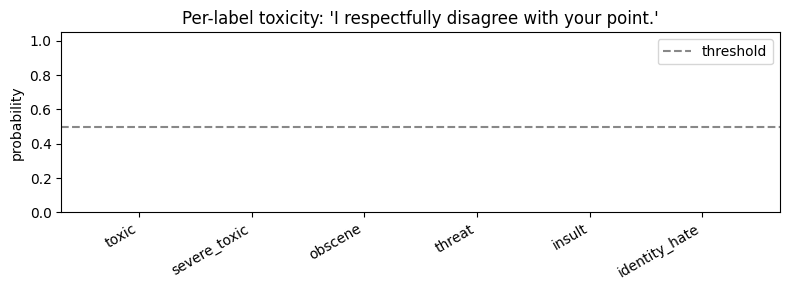

########## m8 DONE in 1.9s ##########


In [64]:
# Module 8 - While-typing early-detection demo
run_module("m8")


In [65]:
# Module 9 - Ablation study (real metrics)
run_module("m9")



########## m9 ########## config-hash=5cc11887a445


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Saved 11 ablation results to results/ablation/experiments.json

| Experiment | Axis | Variant | F1-macro | Acc | Params (M) | Notes |
|-----------|------|---------|----------|-----|-----------|-------|
| atam_without_atam | ATAM | DistilBERT (no ATAM) | 0.1312 | 0.9072 | 66.37 | real subset fine-tune |
| atam_with_atam | ATAM | DistilBERT + ATAM | 0.3706 | 0.9209 | 66.96 | real subset fine-tune |
| prefix_prefix_8 | Prefix Length | Prefix 8 tokens | 0.4141 | 0.9043 | - | agree vs full = 0.973 |
| prefix_prefix_16 | Prefix Length | Prefix 16 tokens | 0.6305 | 0.9199 | - | agree vs full = 0.980 |
| prefix_prefix_32 | Prefix Length | Prefix 32 tokens | 0.6275 | 0.9277 | - | agree vs full = 0.987 |
| prefix_prefix_64 | Prefix Length | Prefix 64 tokens | 0.7075 | 0.9297 | - | agree vs full = 0.995 |
| prefix_full | Prefix Length | Full text | 0.7025 | 0.9297 | - | full input budget |
| fed_centralized | Federated Rounds | Centralized | 0.3857 | 0.9336 | 66.37 | real subset fine-tune |
| op

In [66]:
# Module 10 - Final report, tables and plots
run_module("m10")



########## m10 ########## config-hash=5cc11887a445

Generating training curves...
Saved: results/reports/training_curves.png

Generating ablation plots...
Saved: results/reports/ablation_ATAM.png
Saved: results/reports/ablation_Prefix_Length.png
Saved: results/reports/ablation_Federated_Rounds.png
Saved: results/reports/ablation_Optimization.png

Generating ablation table...
Saved: results/reports/ablation_table.md

Generating per-label table...
Saved: results/reports/per_label_table.md

Generating prefix/earliness table...
Saved: results/reports/prefix_table.md

Generating final report...
Saved: results/reports/ablation_table.md
Saved: results/reports/per_label_table.md
Saved: results/reports/prefix_table.md
Saved: results/reports/final_report.md

All reports saved to results/reports/
########## m10 DONE in 1.0s ##########


## Methodology (single-seed, DistilBERT)

**Fixed protocol for reproducibility (seed 42).**

**Data.** Jigsaw toxic-comment dataset. After cleaning (URLs, @mentions,
emoji→text, lowercasing, whitespace, dedupe) the data is split **once**,
stratified, 80/10/10 into train / validation / test (Module 2,
`project.seed=42`). The M2 test split is never used for training or validation.

**Federated held-out split.** Module 5 re-splits the cleaned training CSV with
the same seed into 80% client-pool / 10% global-val / 10% global-test *before*
partitioning, so no client ever sees the FL test set.

**Models.** DistilBERT-base-uncased (6-label head), optionally + ATAM adaptive
attention head. FL uses LoRA (r=8) personalization over a frozen base so only
~0.04% of parameters are communicated per round.

**Centralized training.** 6 epochs, batch 32, AdamW lr 5e-6, weight decay 0.01,
linear warmup, gradient clip 1.0, BCE-with-logits with per-label pos_weight;
best model chosen by validation F1-macro.

**Federated.** FedAvg, 10 clients, 25 rounds, 1 local epoch, LoRA updates only.
Round + epoch checkpoints enable Kaggle-session resume.

**Metrics.** Subset accuracy, macro/micro P-R-F1, ROC-AUC, per-label
P/R/F1/AUC/AP, Hamming loss, held-out test-set eval, prefix-agreement +
earliness curve, communication cost, INT8 / 30%-prune impact (Module 7/9).

**Reproducibility.** `results/environment.json` fingerprints the software stack;
`.atam_state.json` hashes the config and invalidates stale artifacts.

> *This currently describes a single-seed, single-model (DistilBERT) evaluation.
> Aggregate confidence intervals and additional baselines are deferred until a
> stronger (multi-seed) protocol is adopted.*


## Paper figures / tables inventory (single-seed run)

| Paper item | Produced by | Artifact |
|---|-------------|----------|
| Overall results (central / +ATAM / FL) | Module 10 | `results/reports/final_report.md` |
| Per-label P/R/F1 table | Module 3 / 6 | `results/plots/per_label_metrics.csv`, `results/atam/per_label_metrics.csv` |
| Per-label confusion matrices | Module 3 / 6 | `results/plots/confusion_matrices.png`, `results/atam/confusion_matrices.png` |
| ROC + PR curves | Module 3 / 6 | `results/plots/roc_pr_curves.png`, `results/atam/roc_pr_curves.png` |
| Training curves (loss + F1) | Module 3 | `results/plots/training_curves.png` |
| FL convergence (val F1 per round) | Module 5 | `results/federated/{exp}/federated_history.json` |
| FL held-out test set + comm cost | Module 5 | `results/federated/{exp}/test_metrics.json` |
| Prefix agreement / earliness curve | Module 9 | `results/ablation/prefix_curve.png` + `prefix_curve.csv` |
| Ablation (ATAM / prefix / FL / optimization) | Module 9 | `results/ablation/experiments.json` |
| Edge optimization (latency/size/F1) | Module 7 | `results/optimization/benchmark_results.json` |
| Environment fingerprint | setup cell | `results/environment.json` |

To cite a number, run the matching module cell and copy the value from the
artifact listed above; all artifacts are regenerated from seed 42 alone.


In [67]:
import shutil
import os
from IPython.display import FileLink

# Define the directory to zip and the output archive name
source_dir = '/kaggle/working'
archive_name = 'working_directory_output'

# Create the zip archive
# This creates 'working_directory_output.zip' inside /kaggle/working
shutil.make_archive(archive_name, 'zip', source_dir)

# Generate the download link
FileLink(f'{archive_name}.zip')   

OSError: [Errno 28] No space left on device